# fermion fable and the primordial gravitational field: the coupled system, from the beginning of the present universe to today

This notebook solves the coupled equations of the quantized fermion fable (in its Kohn–Sham ground
state) and the 8-dimensional gravitational field, from deep in the radiation era, before
nucleosynthesis, to today, with the Rust solver `fable_fermion` (pure-Rust SUNDIALS 7.8.0 CVODE), and
re-computes every run with an independent scipy implementation.  The asymptotic region of the
primordial field is an 8-dimensional Bianchi-I universe with three scale factors: `A` for the
observed sheet, `B` for the hidden timelike sheet, `C` for the hidden coordinate `x0`.  Two models
are run.  `fable4d` holds the hidden sheet fixed with a zero-energy stabilizing stress (a Lagrange
multiplier that violates the null energy condition); it is the physical model and the answers rest
on it.  `fable8d` leaves the hidden sheet free; it is the no-go demonstration, because the Newton
constant then varies by many orders of magnitude.  The runs: (a) the author's mass term alone, an
Einstein–de Sitter universe; (b) a mass term plus a bare cosmological constant, ΛCDM with fable dark
matter; (c) the potentials with which the fable supplies the dark energy itself, with parameter
scans; the mass bounds from `ΔN_eff`, free streaming and phase space; (d) the unstabilized no-go
runs.  The last section answers the two questions — is there a time-varying dark-energy `w`, and a
time-varying dark-matter `w`? — from these runs, with every caveat.  Every number is computed below.

## 1. How to open a notebook like this one, from a terminal

**What you need.** A Rust toolchain (`cargo`, from https://rustup.rs), Python 3 (3.10 or newer),
`git`, and an internet connection for the one-time setup, which makes a sparse clone of the
platform rustSolveIt engine (the vendored pure-Rust SUNDIALS 7.8.0 that both solvers of this
project are built on: `rustSolveIt_Win11_SUNDIALS_7_8_0` on Windows 11,
`rustSolveIt_macos-silicon_SUNDIALS_7_8_0` on Apple-silicon macOS,
`rustSolveIt_linux_SUNDIALS_7_8_0` on Linux).  Nothing else is downloaded.

**The three commands.**  From the directory that contains `fable-cosmology/`:

1. Run the setup once.  It creates the virtual environment `.venv`, installs numpy, scipy,
   matplotlib and jupyter into it, clones the engine sparsely into `rust/vendor/rustSolveIt`,
   builds the two solvers `rust/fable_cosmo` and `rust/fable_fermion` with `cargo build --release`
   and prints their versions:

       bash fable-cosmology/setup.sh
       powershell -ExecutionPolicy Bypass -File fable-cosmology\setup.ps1      (Windows PowerShell)

2. Change into the project:

       cd fable-cosmology

3. Start JupyterLab on the notebooks folder:

       .venv/bin/jupyter lab notebooks/
       .venv\Scripts\jupyter.exe lab notebooks\        (Windows)

A browser tab opens.  Click this notebook in the file list on the left.  When Jupyter asks for a
kernel, pick **`Python 3 (ipykernel)`** -- it is the kernel of the `.venv` you just made, so
numpy, scipy and matplotlib are all there.  Run a cell with **`Shift+Enter`**: the cursor moves
to the next cell, and the outputs (text, tables, figures) appear under the cell.  Run the cells
in order from the top; `Run > Run All Cells` does that in one go.  Every cell finishes in well
under a minute on a laptop.

If a cell says the solver binary is missing, the setup was not run (or not finished): run step 1
again and watch for its last line, `== setup complete`.  To rebuild this notebook's solver alone,
run `cargo build --release` inside `rust/fable_fermion`; its own tests run with
`cargo test --release` in the same folder.

## 2. The words used in this notebook

- **field** -- a quantity defined at every point of space-time.  `fable` is a spinor field Ψ with
  sixteen components per point that rotate into each other under Spin(4,4), the symmetry group of
  the 8-dimensional pre-universe.  In Part VI of the Mathematica notebook (the classical fable) the
  sixteen components are real commuting numbers; here they are quantized.
- **complex 16-spinor** -- the fermion fable: sixteen *complex* anticommuting components.  It is
  the minimal field that uses the author's spinor metric σ16, propagates, admits a potential
  V(s) of s = Ψbar Ψ, and reduces to Part VI's field as its real commuting shadow.
- **Grassmann numbers** -- anticommuting variables, θ1 θ2 = −θ2 θ1, so θ1² = 0; the classical
  variables of a fermion field.  A bilinear θᵀ M θ keeps only the antisymmetric part of M.
- **Dirac conjugate** -- Ψbar = Ψ^‡ σ16, with Ψ^‡ the complex-conjugate transpose and
  σ16 = T16[0] T16[1] T16[2] T16[3] the author's spinor metric; s = Ψbar Ψ is the scalar density.
- **anticommutator** -- {A, B} = AB + BA.  A fermion field is quantized by prescribing
  anticommutators, {Ψ_a(x), Ψ^‡_b(y)}, instead of commutators.
- **Krein space** -- a vector space with an *indefinite* inner product.  Here the form u^‡ G u
  with G = −i σ16 γ⁴ has eight positive and eight negative directions, so the naive quantization
  has states of negative norm.
- **fundamental symmetry J** -- an operator with J² = 1 that turns an indefinite form into a
  positive one.  Here J = −i T16[0] T16[1] T16[2] T16[3] T16[4]; the Hilbert adjoint is
  Ψ^† := Ψ^‡ J.
- **Fock space** -- the Hilbert space of states with any number of particles, built by applying
  creation operators to the vacuum.
- **Dirac sea** -- the vacuum in which every negative-frequency mode is filled.  Its holes are the
  antiparticles, and energies are measured from it (normal ordering).
- **Kohn–Sham** -- the density-functional method that replaces an interacting system by
  non-interacting quasiparticles moving in a self-consistent mean field.  Here the mean field is
  the mass m = W′(σ), with W(σ) := V(Hσ) and σ = ⟨χbar χ⟩, χ = Ψ/√H.
- **gap equation** -- the self-consistency condition m = W′(σ_KS(m, kF)/v): the mass of the
  quasiparticles fixes their scalar density, and the scalar density fixes the mass.
- **Fermi momentum kF** -- the radius of the filled momentum ball; with g = 8 states per
  momentum the number density is n = g kF³/(6π²).
- **degenerate gas** -- fermions at zero temperature, filling every state with |k| < kF.  Its
  pressure comes from the Pauli principle, not from heat.
- **ΔN_eff** -- extra radiation, counted in units of the energy density of one massless neutrino
  species: ΔN_eff = ρ_f / ρ_ν(1 species).  Nucleosynthesis (BBN) and the cosmic microwave
  background allow about 0.3.
- **stabilizing stress** -- the zero-energy pressure P_stab = −F/2 on the hidden directions that
  holds the hidden sheet fixed in the model `fable4d`.  It is a Lagrange multiplier, not a stress
  derived from any field.
- **null energy condition** -- ρ + P ≥ 0 for every direction and every component.  A component
  with zero energy density and negative pressure violates it.
- **Bianchi-I** -- a homogeneous but anisotropic metric with one scale factor per direction:
  ds² = C² dz² + A² dx_obs² − dt² − B² dx_hid².
- **hidden sheet** -- the directions x5, x6, x7 (timelike in the 4+4 signature, scale factor B),
  together with the hidden spacelike coordinate x0 (scale factor C, proper coordinate z).
- **Newton constant variation** -- the observed Newton constant is G_4 = G_8 / V_hid, with V_hid
  proportional to B³ C.  If the hidden sheet moves, G_4 changes; lunar laser ranging allows
  |d ln G/dt| < 1e−13 per year today, and nucleosynthesis allows |ΔG/G| of about 0.1 since then.
- **Lagrangian** -- the function L of a field and its derivatives whose integral (the action) is
  stationary on the physical solutions; in curved space-time it carries the factor Sqrt[|det g|].
- **energy-momentum tensor** T_{μν} -- the response of the action to a change of the metric.  Its
  components measured by an observer are the energy density and the pressures.
- **energy density ρ** -- energy per unit volume seen by the observer moving along the time
  coordinate (x4 on the pre-universe, t in the present universe).
- **pressure P** -- a diagonal spatial component of T.  P_obs acts along the observed sheet
  x1, x2, x3, P_hid along the hidden sheet x5, x6, x7, P_x0 along x0.
- **equation of state w = P/ρ** -- here w = P_obs/ρ.  A component with constant w dilutes as
  a^{−3(1+w)}: w = 1/3 is radiation, w = 0 is dust, w = −1 is a cosmological constant.
- **scale factor a** -- the size of the observed 3-space relative to today (a = 1 today, defined by
  the photon temperature T_CMB = 2.7255 K); in the solver it is called A.
- **redshift z = 1/a − 1** -- what an astronomer measures; z = 0 today.
- **N = ln a** -- the number of e-folds of expansion, the independent variable of the solver.
- **Hubble rate H = (da/dt)/a** -- measured in units of its value today, H0 = 1; the hidden
  directions have their own rates H_B and H_C.
- **Ω_i** -- the fraction ρ_i/(3H²) (in units 8πG = 1) of the critical density carried by
  component i: radiation r, baryons b, the fable f.
- **CPL (w0, wa)** -- the Chevallier–Polarski–Linder line w(a) = w0 + wa(1 − a).  The supernova
  *Unite* fits are (w0, wa) = (−0.861, −0.60) and, forcing a constant w, w = −0.764.
- **thawing / freezing** -- a dark energy whose w rises with time (dw/dN > 0) is thawing, one whose
  w falls towards −1 is freezing.
- **phantom** -- w < −1.  Crossing w = −1 is called crossing the phantom divide.
- **dust** -- pressureless matter, w = 0, ρ ∝ a^{−3}: what cold dark matter is.
- **cosmological constant** -- a constant energy density, w = −1 exactly.
- **kination** -- energy that is all kinetic, w = +1, ρ ∝ a^{−6}; the fable reaches it only on a
  non-ground-state branch of the gap equation.
- **SUNDIALS / CVODE / BDF / Adams** -- SUNDIALS is the Lawrence Livermore suite of solvers for
  differential equations; CVODE is its solver for first-order systems y′ = f(x, y); BDF (backward
  differentiation formulas, implicit, for stiff systems) and Adams (explicit-predictor
  multistep) are its two families of methods.  The solver uses the pure-Rust port of SUNDIALS 7.8.0
  of the rustSolveIt repositories, BDF with Newton iteration.
- **tolerance** -- CVODE keeps the local error of every step below rtol·|y| + atol; the runs use
  rtol = 1e−10, atol = 1e−12.  The independent scipy cross-checks integrate with DOP853 at
  rtol = 1e−11 and use adaptive quadrature for every Fermi-sea integral.

## 3. The field, its Lagrangian and its energy-momentum tensor

**The field.**  The fermion fable is a complex 16-component Grassmann spinor `Ψ` on the
8-dimensional pre-universe (`η = diag(+,+,+,+,−,−,−,−)`, real generators `T16[a]`, the author's spinor
metric `σ16 = T16[0] T16[1] T16[2] T16[3]`, Dirac conjugate `Ψbar = Ψ^‡ σ16`).  Its Lagrangian is the
symmetrized covariant one,

    L = Sqrt[|g|] L̂,     L̂ = (1/(2H)) [ Ψbar γ^μ D_μΨ − (D_μΨbar) γ^μ Ψ ] − V(s),     s = Ψbar Ψ ,

with `D_μ` the covariant derivative of the canonical spin connection; its field equations are
`γ^μ D_μΨ = H V′(s) Ψ` and `(D_μΨbar) γ^μ = −H V′(s) Ψbar`.  It is quantized canonically with `x4` as
time: the anticommutator carries the indefinite form `G = −i σ16 γ⁴`, the fundamental symmetry
`J = −i T16[0]…T16[4]` makes the Fock space positive, the negative-frequency modes form the Dirac sea,
and each spatial momentum carries `g = 8` particle states.  Its energy–momentum tensor operator is
the Hilbert tensor of the symmetrized action,

    T̂_μν = −(1/(4H)) [ Ψbar γ_μ D_νΨ − (D_νΨbar) γ_μ Ψ + (μ ↔ ν) ] + g_μν L̂ ,

normal-ordered with respect to the `J`-vacuum.

**The source: the Kohn–Sham ground state, per 7-volume.**  With `W(σ) := V(Hσ)`, the fable in its
zero-temperature Kohn–Sham ground state is a Fermi gas of `g = 8` states per momentum filling the
momenta `|k| < kF` along the observed sheet (zero modes along `x0` and `x5, x6, x7`), of mass
`m = W′(σ8)`, where `σ8 = σ_KS(m, kF)/v` is the scalar density per 7-volume and `v = B³C/(B³C)_today` the
hidden volume factor.  The expectation value of `T̂_μν` is diagonal, with

    ρ     = ε_KS/v + W(σ8) − σ8 W′(σ8)          (= ρ_qp + ρ_U)
    P_obs = P_KS/v + σ8 W′ − W                   (along x1, x2, x3)
    P_hid = P_x0 = σ8 W′ − W                     (along x5, x6, x7 and x0: the gas has no momentum there)

`ε_KS, P_KS, σ_KS` are the Fermi-sea integrals at `(m, kF)`, `kF = kF0/A` (the number of fermions per
7-volume dilutes as `A^{−3} v^{−1}`).  Two exact identities make this a consistent source:
`ρ + P_obs = wF n/v ≥ 0` (so `w_f = P_obs/ρ ≥ −1` wherever `ρ > 0`: the quantized fable never crosses
the phantom divide) and `ρ + P_hid = ε_KS/v`; at a gap root `dρ = wF dn/v − (ε_KS/v) d ln v`, which is
the covariant conservation law in the Bianchi-I metric.  The **DM/DE split** `ρ_qp = ε_KS/v`
(quasiparticles, `w_DM = P_KS/ε_KS` from 1/3 to 0) versus `ρ_U = W − σ8W′` (the condensate, with
`P = −ρ_U` along all seven spatial directions: an 8-dimensional vacuum energy) is a convention.

**The potentials** (`potentials.rs`; masses in `E_c = ρ_c0^{1/4}`):

| name | `W(σ)` | what is given | what the solver shoots |
|---|---|---|---|
| `mass` (the author's) | `m0 σ` | `m0` | `ln kF0` so that today `ρ_r + ρ_b + ρ_f = 1` |
| `lambda-mass` | `V0 + m0 σ` | `m0`, `Ω_qp0 = 0.265` | `V0` (a bare Λ); `kF0` from `ε_KS(m0, kF0) = Ω_qp0` |
| `power` | `m0 σ + λ σ^ν` | `m_today`, `ν`, `Ω_qp0` | the condensate energy today `U_t = (1 − ν) λ σ_t^ν` |
| `expdamp` | `V0 + m0 σ e^{−σ/s1}` | `m_today`, `xt = σ_t/s1`, `Ω_qp0` | `V0` |
| `quadratic` | `V0 + m0 σ + (λ/2) σ²` | `m_today`, `gq = λσ_t/m_today`, `Ω_qp0` | `V0` |
| `lorentz` | `V0 + m0 σ/(1 + (σ/s1)²)` | `m_today`, `xt`, `Ω_qp0` | `V0` |

For the potentials that supply dark energy the split is imposed today: the quasiparticles carry
`Ω_qp0 = 0.265` (the dark matter) at the mass `m_today = W′(σ_t)`, and the amplitude closes the budget.
The other sources are radiation (on the observed sheet: `P_obs = ρ_r/3`, `P_hid = P_x0 = 0`) and
baryons (dust in every direction).  **What is proved where.**  The field, its quantization and its
energy–momentum tensor are asserted in Part VII of the Mathematica notebook.  The Einstein tensor of
the Bianchi-I metric and the conservation law are computed numerically in section 4 of this notebook
from the metric itself.  The Fermi-sea formulas are evaluated by the solver and, independently, by
adaptive quadrature in the scipy cross-check.

## 4. The equations of motion

**The metric of the present universe.**  Far from the wall `x0 = 0` of the primordial field
(`6Hx0 → π/2`), every `x0`-dependent term of the Einstein tensor of the warped frame decays like
`Cot[6Hx0]²`, and the primordial field becomes the 8-dimensional Bianchi-I metric

    ds² = C(t)² dz² + A(t)² (dx1² + dx2² + dx3²) − dt² − B(t)² (dx5² + dx6² + dx7²) ,

`t = x4`, `z` the proper `x0`-coordinate; the canonical frame is its special case `A = e^{−a4}`,
`B = e^{a4}`, `C = 1` (`a4` itself is never given a value).  With `H_X = d ln X/dt` and
`Θ = 3H_A + 3H_B + H_C`, the Einstein equations `G^μ_ν = κ_8 T^μ_ν`, `T^μ_ν = diag(P_x0, P_obs, P_obs,
P_obs, −ρ, P_hid, P_hid, P_hid)`, are

    constraint:   3H_A² + 3H_B² + 9 H_A H_B + 3 H_A H_C + 3 H_B H_C = κ_8 ρ          (−G^4_4: the sum over pairs of directions)
    evolution:    dH_i/dt + H_i Θ = κ_8 (P_i − T/6),     i = A, B, C,     T = −ρ + 3P_obs + 3P_hid + P_x0
    conservation: dρ/dt + 3H_A (ρ + P_obs) + 3H_B (ρ + P_hid) + H_C (ρ + P_x0) = 0          (for each source)

(`R^i_i = dH_i/dt + H_i Θ`, and `D − 2 = 6` in eight dimensions).  The mixed Einstein tensor does not
depend on whether a direction is timelike or spacelike.  The constraint propagates:
`d(S − κρ)/dt = −2Θ (S − κρ)`, `S` the pair sum.  The cell below computes the Einstein tensor
numerically from the metric (the Christoffel symbols and the Ricci tensor of a diagonal metric that
depends on `t` only, for test functions `A, B, C`) and checks all four statements, including the flip
of the hidden sheet from timelike to spacelike and the covariant divergence of a diagonal `T^μ_ν`.

**The hidden-sheet driver.**  For the hidden directions (`P_x0 = P_hid` for every source here)
`dH_B/dt + H_B Θ = κ_8 F/6` with `F = ρ − 3P_obs + 2P_hid`: radiation `F = 0`, dust `F = ρ`, an
8-dimensional vacuum energy (a bare `V0`, the condensate `ρ_U`) `F = 2ρ_V`, the Kohn–Sham fable
`F = 2W − σ8 W′`.  The hidden sheet stays frozen (`H_B = H_C = 0`) exactly when `F = 0`: for radiation,
and for a fable with `W ∝ σ²` — whose ground state is, however, the massless gas (radiation).  Any dust
or vacuum energy drives the hidden sheet, and the observed Newton constant `G_4 = G_8/V_hid ∝ 1/v`
changes: that is the unstabilized model **`fable8d`**, the no-go demonstration.

**The stabilized model `fable4d`** adds to `fable8d` a zero-energy stress `P_stab = −F_total/2` on the
`B` and `C` directions.  Then `H_B = H_C = 0`, `v = 1`, and the equations become exactly 4-dimensional
Friedmann: `3H_A² = κρ` and `dH_A/dt = −(κ/2)(ρ + P_obs)`.  `P_stab` is a Lagrange multiplier, not a
stress derived from any field; with zero energy density and `P_stab < 0` wherever `F > 0` it violates
the null energy condition along `x0` (for dust, `ρ + P_C = −ρ_dust/2` for the stabilizer).  This is
the physical model: every answer of section 7 rests on it, with this caveat.  `fable8d
--freeze-hidden` integrates the same system with `H_A` evolved (not algebraic) and must reproduce it.

**Units, normalization, interval.**  `ħ = c = 1`, `H0 = 1` (time in `1/H0`), densities per 7-volume in
`ρ_c0 = 3H0²M_pl²`, so the constraint reads `S = 3ρ̂`; masses and momenta in `E_c = ρ_c0^{1/4}`;
`κ_4,0 = κ_8/V_h,0` with `v = 1` today in every run (`B = C = 1` at `A = 1`); `Ω_r0` (photons and
`N_eff = 3.046` massless neutrinos at `T_CMB = 2.7255 K`, `h = 0.674`) and `Ω_b0 = 0.02237/h²` are
computed from constants by the solver and printed.  `A = 1` is defined by `T_CMB`.  The runs start at
`a_i ≤ min(1e−10, 0.01 a_nr(m))`: before nucleosynthesis (`a_BBN`, `T = 1 MeV`), with the fable
ultra-relativistic; the pre-universe does not fix `a_i`, and section 5.1 shows that the results do not
depend on it.  `g_*(T)` is not followed (`ρ_r = Ω_r0 A^{−4}/v` at all times).  `fable4d` is normalized
by a closure today (`ρ_r + ρ_b + ρ_f = 1` at `A = 1`); the forward `fable8d` is a boundary-value problem
(`H_B = H_C = 0` at `a_i`; `H_A = B = C = 1` today), solved by an outer shooting on the fable's
amplitude and an inner secant iteration on `ln v(a_i)`.  **Assumptions:** `x0` is compactified in the
asymptotic region with a Kaluza–Klein gap far above the temperatures considered; the hidden timelike
sheet is a formal comoving volume (compactifying it gives closed timelike curves); every field is
truncated to its zero modes along the hidden directions; gravity is semiclassical (`G = κ⟨T̂⟩`); the
exchange–correlation energy is neglected.

In [1]:
import math, itertools
import numpy as np


def mixed_einstein(sig, f, df, ddf, t_index=4):
    """G^mu_nu and R^mu_nu of g = diag(sig_mu exp(2 f_mu(t))) (f_t = 0, sig_t = -1), from f, f', f'' at one t:
    Christoffel symbols of a diagonal metric depending on t only, their t-derivatives, the Ricci tensor
    R_mn = d_l Gam^l_mn - d_n Gam^l_ml + Gam^l_ls Gam^s_mn - Gam^l_ns Gam^s_ml."""
    D = len(sig)
    g = np.array([s_ * math.exp(2 * x) for s_, x in zip(sig, f)])
    dg = 2 * g * np.array(df)
    ddg = 2 * g * (np.array(ddf) + 2 * np.array(df) ** 2)
    gi, dgi = 1 / g, -dg / g ** 2
    Gam, dGam = np.zeros((D, D, D)), np.zeros((D, D, D))
    for l, m_, n in itertools.product(range(D), repeat=3):
        s, ds = 0.0, 0.0
        if m_ == t_index and l == n:
            s, ds = s + dg[l], ds + ddg[l]
        if n == t_index and l == m_:
            s, ds = s + dg[l], ds + ddg[l]
        if l == t_index and m_ == n:
            s, ds = s - dg[m_], ds - ddg[m_]
        Gam[l, m_, n], dGam[l, m_, n] = 0.5 * gi[l] * s, 0.5 * (dgi[l] * s + gi[l] * ds)
    Ric = dGam[t_index].copy()
    Ric[:, t_index] -= np.einsum('lml->m', dGam)
    Ric += np.einsum('lls,smn->mn', Gam, Gam) - np.einsum('lns,sml->mn', Gam, Gam)
    Rmix = np.diag(gi) @ Ric
    Rs = np.trace(Rmix)
    return Rmix - 0.5 * Rs * np.eye(D), Rmix, Gam


# test functions: ln C = 0.1 t - 0.07 t^2, ln A = 0.3 t + 0.1 t^2, ln B = -0.2 t + 0.05 t^2, at t = 0.4
t = 0.4
lnX = {'C': (0.1, -0.07), 'A': (0.3, 0.1), 'B': (-0.2, 0.05)}
Hd = {k: (b + 2 * c * t) for k, (b, c) in lnX.items()}          # H_X = d ln X/dt
dHd = {k: 2 * c for k, (b, c) in lnX.items()}                    # dH_X/dt
val = {k: b * t + c * t * t for k, (b, c) in lnX.items()}
order = ['C', 'A', 'A', 'A', None, 'B', 'B', 'B']                 # x0, x1..x3, x4 = t, x5..x7
f = [val[k] if k else 0.0 for k in order]
df = [Hd[k] if k else 0.0 for k in order]
ddf = [dHd[k] if k else 0.0 for k in order]
Gt, Rt, Gam = mixed_einstein([1, 1, 1, 1, -1, -1, -1, -1], f, df, ddf)
Gs, _, _ = mixed_einstein([1, 1, 1, 1, -1, 1, 1, 1], f, df, ddf)            # the hidden sheet made spacelike
HA, HB, HC = Hd['A'], Hd['B'], Hd['C']
Th = 3 * HA + 3 * HB + HC
S = 3 * HA ** 2 + 3 * HB ** 2 + 9 * HA * HB + 3 * HA * HC + 3 * HB * HC
checks = {
    'off-diagonal G^mu_nu = 0': np.max(np.abs(Gt - np.diag(np.diag(Gt)))),
    '-G^4_4 - (3HA^2 + 3HB^2 + 9HAHB + 3HAHC + 3HBHC)': abs(-Gt[4, 4] - S),
    'R^0_0 - (dH_C/dt + H_C Theta)': abs(Rt[0, 0] - (dHd['C'] + HC * Th)),
    'R^1_1 - (dH_A/dt + H_A Theta)': abs(Rt[1, 1] - (dHd['A'] + HA * Th)),
    'R^5_5 - (dH_B/dt + H_B Theta)': abs(Rt[5, 5] - (dHd['B'] + HB * Th)),
    'G^mu_nu(hidden timelike) - G^mu_nu(hidden spacelike)': np.max(np.abs(Gt - Gs)),
}
# the covariant divergence of T^mu_nu = diag(P_C, P_A x3, -rho, P_B x3) with arbitrary values and a rate drho/dt
rho, PA, PB, PC, drho = 0.7, 0.2, -0.3, 0.45, -1.9
Tm = np.diag([PC, PA, PA, PA, -rho, PB, PB, PB])
dTm = np.zeros((8, 8)); dTm[4, 4] = -drho
div4 = dTm[4, 4] + np.einsum('mml,l->', Gam, Tm[:, 4]) - np.einsum('lmn,ml->n', Gam, Tm)[4]
checks['div T (nu = 4) + (drho/dt + 3HA(rho+P_obs) + 3HB(rho+P_hid) + HC(rho+P_x0))'] = abs(div4 + (drho + 3 * HA * (rho + PA) + 3 * HB * (rho + PB) + HC * (rho + PC)))
for k, v in checks.items():
    print(f'{k:80s} {v:.2e}')
assert max(checks.values()) < 1e-12
print('the Bianchi-I Einstein tensor, computed from the metric, is the one the solver integrates')

off-diagonal G^mu_nu = 0                                                         0.00e+00
-G^4_4 - (3HA^2 + 3HB^2 + 9HAHB + 3HAHC + 3HBHC)                                 1.63e-16
R^0_0 - (dH_C/dt + H_C Theta)                                                    2.78e-17
R^1_1 - (dH_A/dt + H_A Theta)                                                    5.55e-17
R^5_5 - (dH_B/dt + H_B Theta)                                                    2.43e-17
G^mu_nu(hidden timelike) - G^mu_nu(hidden spacelike)                             0.00e+00
div T (nu = 4) + (drho/dt + 3HA(rho+P_obs) + 3HB(rho+P_hid) + HC(rho+P_x0))      2.22e-16
the Bianchi-I Einstein tensor, computed from the metric, is the one the solver integrates


### 4.1 The first-order system actually handed to SUNDIALS

The independent variable is `N = ln A`.  From `a_i = 1e−12` on, the physical rates fall like `A^{−2}`
by many orders of magnitude while `H_B` and `H_C` start at exactly zero, so CVODE integrates the scaled variables
`h_i = H_i A²` and `τ = t/A²` (constant in the radiation era).  **`fable8d`**, state
`y = (ln B, ln C, h_A, h_B, h_C, τ)`:

    d ln B/dN = H_B/H_A,        d ln C/dN = H_C/H_A,
    dh_i/dN   = 2 h_i + A² (dH_i/dt)/H_A,        dτ/dN = −2τ + A^{−2}/H_A,
    dH_A/dt = −H_A Θ + F/2 + 3 (P_obs − P_hid),     dH_B/dt = −H_B Θ + F/2,     dH_C/dt = −H_C Θ + F/2 ,

with `κ_8 ρ → 3ρ̂` (so `κ_8 (P_i − T/6)` becomes `F/2 + 3(P_i − P_hid)`), `v = B³C`, and `F` and
`P_obs − P_hid` formed per source analytically (radiation `0` and `ρ_r/3`, baryons `ρ_b` and `0`, the
fable `2W − σ8W′` and `P_KS/v`), never by subtracting large numbers.  At every right-hand-side
evaluation the gap equation `m = W′(σ_KS(m, kF0 e^{−N})/v)` is solved (in closed form for linear `W`,
by a proven-unique bracket, or by a scan of all roots taking the lowest `ρ`).  Initial state: `H_B =
H_C = 0`, `H_A` from the constraint, `t(a_i) = 1/(2H_A(a_i))`.  **`fable4d`**: one variable,
`dτ/dN = −2τ + A^{−2}/H_A(N)` with `H_A² = ρ̂(N)` algebraic.  **`fable8d --freeze-hidden`**: the
`fable8d` system with the stabilizer, `dH_A/dt = −3H_A² + (3/2)(ρ − P_obs)`, `H_B = H_C = 0`.  CVODE:
BDF, Newton iteration, a dense Jacobian, `rtol = 1e−10`, `atol = 1e−12`.  The independent scipy
check integrates the same `fable8d` equations with DOP853 at `rtol = 1e−11`, evaluates every
Fermi-sea integral by adaptive quadrature and every gap root by `brentq`, and gets `t` in `fable4d` by
adaptive quadrature of `dN/H_A`.

## 5. Running the solver

The binary is `rust/fable_fermion/target/release/fable_fermion` (`.exe` on Windows):

    fable_fermion fable4d|fable8d --potential NAME [--param KEY=VALUE ...] [--direction forward|backward]
                  [--a-start A] [--points K] [--out FILE.csv] [--rtol R] [--atol A] [--method bdf|adams]
                  [--branch lowest|positive|negative] [--freeze-hidden] [--no-shoot] [--no-fable]
                  [--omega-b X] [--omega-r X]
    fable_fermion gap --form NAME --param KEY=VALUE ... --kf KF [--v V]
    fable_fermion --constants | --version

`--param` keys: `mass`: `m0_ev`; `lambda-mass`: `m0_ev`, `omega_dm`; `power`: `m_today_ev`, `nu`,
`omega_dm`; `expdamp`: `m_today_ev`, `xt`, `omega_dm`; `quadratic`: `m_today_ev`, `gq`, `omega_dm`;
`lorentz`: `m_today_ev`, `xt`, `omega_dm`.  Defaults: `--a-start 1e-12`, `--points 2001` (this notebook
uses 1001), `rtol 1e−10`, `atol 1e−12`, the lowest-energy gap branch.  The CSV starts with `#` comment
lines — the version; `# params:` with the normalized parameters (`kf0`, `m0`, `v0`, `lam`, `nu`, `s1`,
`lnB_i`, `lnC_i`, `a_start`, `omega_r0`, `omega_b0`, …); the definition of every column — then 47
columns: `N, a, z, t, B, C, H_A, H_B, H_C, constraint_residual, rho_r, rho_b, rho_f, P_obs_f, P_hid_f,
n_f, sigma, m_eff, kF_over_m, w_f, rho_qp, w_qp, rho_U, w_DE_eff, Omega_r, Omega_b, Omega_f, q_dec,
G_ratio, cs2_adiabatic, N_eff_extra, P_stab, Omega_sum, rho_DE_inf, w_DE_inf, w_DM_intrinsic, w_DM_eff,
Q, rho_DE_eff, F_hidden, dm_dN, m_eff_eV, kF_eV, gap_roots, branch, gap_residual, vac_over_rhoc`.  The
ones used below: `w_f = P_obs_f/rho_f`; `w_qp = w_DM_intrinsic = P_KS/ε_KS`; `w_DM_eff = w_DM −
σ_KS (dm/dN)/(3ε_KS)` and `Q = σ8 dm/dt` (the energy the condensate hands to the quasiparticles);
`rho_DE_inf = H_A² − Ω_r0 A^{−4} − Ω_b0 A^{−3} − m_today n_today A^{−3}` and `w_DE_inf = −1 − (1/3) d ln
rho_DE_inf/d ln A` (the dark energy an observer infers after subtracting radiation, baryons and cold
dark matter with **today's** mass — the solver takes `m_eff(A = 1)`, not a bare parameter);
`cs2_adiabatic = (dP_obs_f/dN)/(dρ_f/dN)`; `N_eff_extra = ρ_f/ρ_ν(1 species)`; `G_ratio = 1/v =
G_4/G_4(today)`; `P_stab = −F/2` (0 in `fable8d`); `vac_over_rhoc = ΔE_vac(m_eff; M = m_eff(A = 1))/v`
in `ρ_c0`, the renormalized Dirac-sea energy the no-sea functional drops.  The log on stderr gives the
normalization, the result today, `a_nr`, `ΔN_eff` at nucleosynthesis and recombination, the stabilizer's
range, the `t(A = 1)` quadrature check and the `# stats:` line.  Exit code 0 is success; 1 a solver or
physics error with a one-line reason (including the refusal of a first-order transition or of a
negative-energy ground state); 2 a usage error.

The next two cells locate the binary, read the unit system from it, define the runner and the Python
Kohn–Sham toolkit, import the independent implementation `fermion/crosscheck.py`, and define the
summaries and the cross-check used in every section below.

In [2]:
import os, sys, re, csv, io, math, time, subprocess
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import quad, solve_ivp
from scipy.optimize import brentq
from IPython.display import Markdown, display

ROOT = Path.cwd() if (Path.cwd() / 'rust').exists() else Path.cwd().parent
BIN = ROOT / 'rust' / 'fable_fermion' / 'target' / 'release' / ('fable_fermion.exe' if os.name == 'nt' else 'fable_fermion')
RESULTS = ROOT / 'results'
REFERENCE = ROOT / 'reference'
RESULTS.mkdir(exist_ok=True)
if not BIN.exists():
    print(f'The solver binary {BIN} does not exist: run  bash fable-cosmology/setup.sh  '
          f'(or  powershell -ExecutionPolicy Bypass -File fable-cosmology\\setup.ps1 ) first, then restart this notebook.')
    raise SystemExit(1)
VERSION = subprocess.run([str(BIN), '--version'], check=True, capture_output=True, text=True).stdout.strip()
CONSTANTS_TEXT = subprocess.run([str(BIN), '--constants'], check=True, capture_output=True, text=True).stdout
print(VERSION)
print(CONSTANTS_TEXT)
print('results directory:', RESULTS)


def _const(key, i=0):
    """The i-th number written as '= <mantissa>e<exponent>' on the line of `fable_fermion --constants`
    that starts with `key`."""
    line = next(l for l in CONSTANTS_TEXT.splitlines() if l.startswith(key))
    return float(re.findall(r'=\s+([-+]?\d[\d.]*e[-+]?\d+)', line)[i])


E_C_EV = _const('E_c')                  # the solver's unit of mass and momentum, rho_c0^(1/4), in eV
RHO_C0_EV4 = _const('rho_c0')           # the critical density today in eV^4
H0_PER_YR = _const('H0', 1)             # H0 in 1/yr
OMEGA_R0 = _const('Omega_r0')
OMEGA_B0 = _const('Omega_b0')
OMEGA_NU1 = _const('Omega_nu(1')        # one massless neutrino species today
T_CMB_EV = _const('T_CMB')
A_BBN = _const('a_BBN')
A_REC = _const('a_rec')
G_FABLE = float(re.search(r'g \(fable states per momentum\) = (\d+)', CONSTANTS_TEXT).group(1))
PI2 = math.pi ** 2
UNITE_W0, UNITE_WA, UNITE_WCONST = -0.861, -0.60, -0.764
LLR_BOUND_PER_YR = 1e-13                # |d ln G/dt| today, lunar laser ranging
print(f'E_c = {E_C_EV:.10e} eV, Omega_r0 = {OMEGA_R0:.10e}, Omega_b0 = {OMEGA_B0:.10e}, Omega_nu(1) = {OMEGA_NU1:.10e}, '
      f'a_BBN = {A_BBN:.6e}, a_rec = {A_REC:.6e}, g = {G_FABLE:g}')


def units_python():
    """The unit system recomputed here from the CODATA 2018 / IAU constants, independently of the solver:
    h = 0.674, T_CMB = 2.7255 K, N_eff = 3.046, omega_b = 0.02237."""
    hbar_js, c, ev, gN, kb = 1.054571817e-34, 299792458.0, 1.602176634e-19, 6.67430e-11, 8.617333262e-5
    hbar_evs = hbar_js / ev                                        # one CODATA 2018 hbar for H0 and M_pl
    mpc = 648000.0 / math.pi * 149597870700.0 * 1e6
    h = 0.674
    h0 = 100.0 * h * 1e3 / mpc * hbar_evs                          # eV
    mpl = math.sqrt(hbar_js * c ** 5 / (8 * math.pi * gN)) / ev    # reduced Planck mass, eV
    rhoc = 3 * h0 ** 2 * mpl ** 2
    og = math.pi ** 2 / 15 * (kb * 2.7255) ** 4 / rhoc
    onu = 7 / 8 * (4 / 11) ** (4 / 3) * og
    return dict(e_c=rhoc ** 0.25, omega_r0=og + 3.046 * onu, omega_nu1=onu, omega_b0=0.02237 / h ** 2)


U_PY = units_python()
for key, val in (('e_c', E_C_EV), ('omega_r0', OMEGA_R0), ('omega_nu1', OMEGA_NU1), ('omega_b0', OMEGA_B0)):
    assert abs(U_PY[key] / val - 1) < 1e-9, (key, U_PY[key], val)
print('the unit system recomputed in Python from CODATA agrees with the solver\'s to 1e-9 (E_c, Omega_r0, Omega_nu1, Omega_b0)')
assert G_FABLE == 8.0
RUNS = {}


def read_fermion_csv(text):
    """A fable_fermion CSV: '#' comment lines (the version, the machine-readable '# params:' line, the
    definitions), then the header line, then the rows.  Returns (comments, params, {column: array})."""
    comments, params, rows, hdr = [], {}, [], None
    for line in text.splitlines():
        if line.startswith('#'):
            comments.append(line[1:].strip())
            if line.startswith('# params:'):
                for tok in line[len('# params:'):].split():
                    k, _, v = tok.partition('=')
                    try:
                        params[k] = float(v)
                    except ValueError:
                        params[k] = v
        elif line.strip():
            if hdr is None:
                hdr = line.strip().split(',')
            else:
                rows.append([float(x) for x in line.split(',')])
    d = np.array(rows)
    return comments, params, {h: d[:, i] for i, h in enumerate(hdr)}


def run_fermion(name, *args, keep=True, expect_failure=False, quiet=False, label=None, show_log=True):
    """Run fable_fermion; write results/<name>.csv (unless keep=False: then the CSV is read from stdout);
    print the solver's log (stderr) and return a dict with the columns, the parameters and the log.
    With expect_failure=True the non-zero exit code and the solver's one-line reason are printed and
    the CompletedProcess is returned.  quiet=True prints only the '# stats:' line."""
    args = [str(x) for x in args]
    out = RESULTS / f'{name}.csv'
    cmd = [str(BIN), *args] + (['--out', str(out)] if keep else [])
    shown = ' '.join(['fable_fermion', *args] + (['--out', f'results/{name}.csv'] if keep else []))
    print('$', shown)
    t0 = time.time()
    r = subprocess.run(cmd, capture_output=True, text=True)
    wall = time.time() - t0
    if expect_failure:
        reason = [l for l in r.stderr.splitlines() if l.startswith('fable_fermion:')]
        print(f'  exit code {r.returncode}: {reason[-1] if reason else r.stderr.strip().splitlines()[-1]}')
        return r
    if r.returncode != 0:
        print(r.stderr)
        raise RuntimeError(f'fable_fermion failed (exit code {r.returncode}) for {name}')
    log = [l for l in r.stderr.splitlines() if l.startswith('#')]
    if show_log:
        for line in log:
            if not quiet or line.startswith('# stats'):
                print(' ', line)
    comments, params, cols = read_fermion_csv(out.read_text() if keep else r.stdout)
    RUNS[name] = dict(name=name, label=label or name, args=args, cols=cols, params=params, comments=comments,
                      log=log, wall=wall, keep=keep)
    return RUNS[name]


def log_value(run, key, pattern=r'([-+]?\d+\.?\d*(?:e[-+]?\d+)?)', i=0):
    """A number from the solver's log line that contains `key`."""
    line = next(l for l in run['log'] if key in l)
    return float(re.findall(pattern, line.split(key, 1)[1])[i])


# ---------------------------------------------------------------- the Kohn-Sham Fermi sea, in Python
# x = kF/|m|.  sigma = g m |m|^2 I1/(2 pi^2), eps = g |m|^4 I2/(2 pi^2), P = g |m|^4 I3/(6 pi^2), with
# I1 = Int_0^x t^2/sqrt(1+t^2), I2 = Int_0^x t^2 sqrt(1+t^2), I3 = Int_0^x t^4/sqrt(1+t^2).
X_SWITCH = 0.25


def ks_I_closed(x):
    """The closed forms (r = sqrt(1 + x^2), A = asinh x): they cancel catastrophically for x << 1."""
    r, A = math.sqrt(1.0 + x * x), math.asinh(x)
    return (x * r - A) / 2.0, (x * r * (2.0 * x * x + 1.0) - A) / 8.0, (x * r * (2.0 * x * x - 3.0) + 3.0 * A) / 8.0


def ks_I_series(x):
    """The convergent binomial series (radius 1): I1 = Sum binom(-1/2, j) x^(2j+3)/(2j+3), I2 with binom(1/2, j),
    I3 = Sum binom(-1/2, j) x^(2j+5)/(2j+5); the binomial coefficients by their recurrences, summed until
    every term is below 1e-17 of its sum."""
    x2, p = x * x, x ** 3
    i1 = i2 = i3 = 0.0
    c = b = 1.0                            # binom(-1/2, j), binom(1/2, j)
    j = 0
    while True:
        t1, t2, t3 = c * p / (2 * j + 3), b * p / (2 * j + 3), c * p * x2 / (2 * j + 5)
        i1, i2, i3 = i1 + t1, i2 + t2, i3 + t3
        if j >= 2 and abs(t1) <= 1e-17 * abs(i1) and abs(t2) <= 1e-17 * abs(i2) and abs(t3) <= 1e-17 * abs(i3):
            return i1, i2, i3
        c *= (-0.5 - j) / (j + 1)
        b *= (0.5 - j) / (j + 1)
        j, p = j + 1, p * x2


def ks_I_stable(x):
    """The numerically stable forms: the series below x = 0.25, the closed forms above."""
    return ks_I_series(x) if x < X_SWITCH else ks_I_closed(x)


def ks_I_quad(x):
    """The three integrals by adaptive quadrature (scipy.integrate.quad, epsrel 1e-13) on the pieces
    [0, 1e-8], [1e-8, 1e-7], ..., [10^k, x], summed with math.fsum: independent of both forms above."""
    o = dict(epsabs=0.0, epsrel=1e-13, limit=200)
    edges = sorted(set([0.0] + [10.0 ** k for k in range(-8, 7) if 10.0 ** k < x] + [x]))
    fs = (lambda t: t * t / math.sqrt(1 + t * t), lambda t: t * t * math.sqrt(1 + t * t), lambda t: t ** 4 / math.sqrt(1 + t * t))
    return tuple(math.fsum(quad(f, a, b, **o)[0] for a, b in zip(edges[:-1], edges[1:])) for f in fs)


def fermi_sea(m, kf, form='stable'):
    """The T = 0 Fermi sea of g = 8 states per momentum: n, sigma, eps, P, wF and chi = d sigma/dm at fixed kF."""
    n = G_FABLE * kf ** 3 / (6 * PI2)
    if kf <= 0.0:
        return dict(n=0.0, sigma=0.0, eps=0.0, P=0.0, wF=abs(m), chi=0.0)
    chi0 = G_FABLE * kf * kf / (4 * PI2)
    if m == 0.0:
        e = G_FABLE * kf ** 4 / (8 * PI2)
        return dict(n=n, sigma=0.0, eps=e, P=e / 3.0, wF=kf, chi=chi0)
    am, x = abs(m), kf / abs(m)
    i1, i2, i3 = {'stable': ks_I_stable, 'closed': ks_I_closed, 'quad': ks_I_quad}[form](x)
    r = math.sqrt(1.0 + x * x)
    # chi = (g/(2 pi^2)) Int_0^kF k^4/w^3 dk = (g m^2/(2 pi^2)) Int_0^x t^4/(1+t^2)^(3/2) dt, and that
    # integral is 3 I1 - x^3/r exactly (its derivative is x^4/r^3); below the switch its series is used
    j4 = (3.0 * i1 - x ** 3 / r) if x >= X_SWITCH else _chi_series(x)
    chi = G_FABLE * m * m * j4 / (2 * PI2)
    return dict(n=n, sigma=G_FABLE * m * am * am * i1 / (2 * PI2), eps=G_FABLE * am ** 4 * i2 / (2 * PI2),
                P=G_FABLE * am ** 4 * i3 / (6 * PI2), wF=math.hypot(kf, m), chi=chi)


def _chi_series(x):
    """3 I1 - x^3/sqrt(1+x^2) = Int_0^x t^4/(1+t^2)^(3/2) dt for small x, by its binomial series
    Sum binom(-3/2, j) x^(2j+5)/(2j+5) (radius 1)."""
    s, p, c, j = 0.0, x ** 5, 1.0, 0      # c = binom(-3/2, j)
    while True:
        t = c * p / (2 * j + 5)
        s += t
        if j >= 2 and abs(t) <= 1e-17 * abs(s):
            return s
        c *= (-1.5 - j) / (j + 1)
        j, p = j + 1, p * x * x


# ---------------------------------------------------------------- the potentials W(sigma) and the gap equation
class Pot:
    """W(sigma) as potentials.rs defines it: mass, lambda-mass, power, expdamp, lorentz, quadratic."""

    def __init__(self, name, **p):
        self.name, self.p = name, dict(p)

    def W(self, s):
        p = self.p
        return {'mass': lambda: p['m0'] * s, 'lambda-mass': lambda: p['v0'] + p['m0'] * s,
                'power': lambda: p['m0'] * s + p['lam'] * s ** p['nu'],
                'expdamp': lambda: p['v0'] + p['m0'] * s * math.exp(-s / p['s1']),
                'lorentz': lambda: p['v0'] + p['m0'] * s / (1.0 + (s / p['s1']) ** 2),
                'quadratic': lambda: p['v0'] + p['m0'] * s + 0.5 * p['lam'] * s * s}[self.name]()

    def dW(self, s):
        p = self.p
        if self.name in ('mass', 'lambda-mass'):
            return p['m0']
        if self.name == 'power':
            return p['m0'] + p['nu'] * p['lam'] * s ** (p['nu'] - 1.0)
        if self.name == 'expdamp':
            return p['m0'] * (1.0 - s / p['s1']) * math.exp(-s / p['s1'])
        if self.name == 'lorentz':
            u = (s / p['s1']) ** 2
            return p['m0'] * (1.0 - u) / (1.0 + u) ** 2
        return p['m0'] + p['lam'] * s

    def d2W(self, s):
        p = self.p
        if self.name in ('mass', 'lambda-mass'):
            return 0.0
        if self.name == 'power':
            return p['nu'] * (p['nu'] - 1.0) * p['lam'] * s ** (p['nu'] - 2.0)
        if self.name == 'expdamp':
            return (p['m0'] / p['s1']) * math.exp(-s / p['s1']) * (s / p['s1'] - 2.0)
        if self.name == 'lorentz':
            u = (s / p['s1']) ** 2
            return p['m0'] * (u - 3.0) / (1.0 + u) ** 3 * 2.0 * s / p['s1'] ** 2
        return p['lam']

    def U(self, s):
        """The condensate energy U = W - sigma W' (P_hid = -U)."""
        return self.W(s) - s * self.dW(s)

    def scaled(self, A):
        """The same shape with every energy scaled by A: W -> A W (m0, v0, lam multiplied by A)."""
        return Pot(self.name, **{k: (v * A if k in ('m0', 'v0', 'lam') else v) for k, v in self.p.items()})


def gap_function(pot, m, kf, v=1.0):
    return m - pot.dW(fermi_sea(m, kf)['sigma'] / v)


def gap_roots(pot, kf, v=1.0, ngrid=2001):
    """Every root of m = W'(sigma_KS(m, kF)/v): a scan of m over [-M, M] (M = 1.1 max |W'| over
    |sigma| < n/v), asinh-spaced on the scale kF (m > 0 only for the power law), every sign change
    refined by brentq.  Linear W: the root is m0."""
    if pot.name in ('mass', 'lambda-mass'):
        return [pot.p['m0']]
    n8 = G_FABLE * kf ** 3 / (6 * PI2) / v
    positive = pot.name == 'power'
    ss = np.linspace(1e-12 * n8 if positive else -n8 * (1 - 1e-12), n8 * (1 - 1e-12), 2001)
    M = 1.1 * max(abs(pot.dW(s)) for s in ss) + 1e-300
    if positive:
        ms = np.geomspace(1e-14 * kf, M, ngrid)
    else:
        t = np.linspace(-math.asinh(M / kf), math.asinh(M / kf), ngrid)
        ms = kf * np.sinh(t)
    f = lambda m: gap_function(pot, m, kf, v)
    fs = [f(m) for m in ms]
    roots = []
    for i in range(len(ms) - 1):
        if fs[i] == 0.0:
            roots.append(float(ms[i]))
        elif fs[i] * fs[i + 1] < 0.0:
            roots.append(brentq(f, ms[i], ms[i + 1], xtol=1e-300, rtol=1e-15, maxiter=500))
    return roots


def mean_field(pot, m, kf, v=1.0):
    """The Kohn-Sham fable at mass m (a gap root or not), per 7-volume v: rho = eps/v + U, P_obs = P/v - U, P_hid = -U."""
    fs = fermi_sea(m, kf)
    s8 = fs['sigma'] / v
    U = pot.U(s8)
    return dict(m=m, kf=kf, n8=fs['n'] / v, sigma8=s8, eps=fs['eps'] / v, P=fs['P'] / v, wF=fs['wF'], chi=fs['chi'],
                U=U, rho=fs['eps'] / v + U, P_obs=fs['P'] / v - U, P_hid=-U, gap=m - pot.dW(s8))


def ground_state(pot, kf, v=1.0):
    """The gap root of lowest energy density (the solver's default branch rule), with the number of roots."""
    roots = gap_roots(pot, kf, v)
    mfs = [mean_field(pot, m, kf, v) for m in roots]
    best = min(mfs, key=lambda d: d['rho'])
    best['n_roots'] = len(roots)
    return best


def delta_e_vac(m, M, closed=False):
    """The renormalized one-loop Dirac-sea energy that the no-sea functional drops (relativistic Hartree,
    Chin 1977), g = 8, reference mass M: vanishes like (m - M)^5 at m = M; even in m.
    With t = (M - m)/M the bracket is M^4 f(t), f = (1-t)^4 ln(1-t) + t - (7/2)t^2 + (13/3)t^3 - (25/12)t^4,
    whose first four orders cancel; for |t| < 0.2 the series f = Sum_{n>=5} c_n t^n,
    c_n = -Sum_{k=0..4} (-1)^k C(4,k)/(n - k), is summed instead (closed=True forces the closed form)."""
    m, M = abs(m), abs(M)
    t = (M - m) / M
    if closed or abs(t) >= 0.2:
        d = M - m
        log_term = m ** 4 * math.log(m / M) if m > 0 else 0.0
        return -(G_FABLE / (16 * PI2)) * (log_term + M ** 3 * d - 3.5 * M * M * d * d + 13.0 / 3.0 * M * d ** 3 - 25.0 / 12.0 * d ** 4)
    f, tn, n = 0.0, t ** 5, 5
    while True:
        cn = -sum((-1) ** k * math.comb(4, k) / (n - k) for k in range(5))
        term = cn * tn
        f += term
        if abs(term) <= 1e-17 * abs(f) or n > 400:
            return -(G_FABLE / (16 * PI2)) * M ** 4 * f
        n, tn = n + 1, tn * t


def cpl_fit(a, w, mask=None, amin=0.3, amax=1.0):
    """Least squares of w(a) to w0 + wa (1 - a) over amin <= a <= amax (and mask), numpy.polyfit on (1 - a)."""
    sel = (a >= amin) & (a <= amax) & np.isfinite(w)
    if mask is not None:
        sel &= mask
    if sel.sum() < 3:
        return float('nan'), float('nan')
    wa, w0 = np.polyfit(1.0 - a[sel], w[sel], 1)
    return float(w0), float(wa)


def crossing_points(a, y, level=0.0, floor=None):
    """Every a at which y - level changes sign (linear interpolation in ln a between rows).  With `floor` (an
    array), a sign change between two rows where |y - level| stays below the floor is rounding noise and is skipped."""
    f = y - level
    out = []
    for k in range(1, len(a)):
        if floor is not None and max(abs(f[k - 1]), abs(f[k])) <= max(floor[k - 1], floor[k]):
            continue
        if np.isfinite(f[k - 1]) and np.isfinite(f[k]) and f[k - 1] * f[k] < 0:
            la, lb = math.log(a[k - 1]), math.log(a[k])
            out.append(math.exp(la + (lb - la) * f[k - 1] / (f[k - 1] - f[k])))
    return out


def interp_log(a_rows, y_rows, a0):
    """y at a0, interpolating linearly in ln a (NaN outside the run)."""
    if a0 < a_rows[0] or a0 > a_rows[-1]:
        return float('nan')
    return float(np.interp(math.log(a0), np.log(a_rows), y_rows))

fable_fermion 0.1.0, sundials_rs 7.8.0 (pure Rust), CVODE BDF
# fable_fermion unit system (hbar = c = k_B = 1)
h                     = 0.674
H0                    = 2.1842852411e-18 1/s = 6.8930799924e-11 1/yr = 1.4377226622e-33 eV
1/H0                  = 1.4507302992e10 yr
M_pl (reduced, from G)= 2.4353234593e27 eV = 2.4353234593e18 GeV
rho_c0 = 3 H0^2 M_pl^2= 3.6777719498e-11 eV^4
E_c = rho_c0^(1/4)    = 2.4626131773e-3 eV   (unit of m, kF; sigma, n in E_c^3; W, rho in E_c^4 = rho_c0)
1 eV                  = 4.0607270732e2 E_c
T_CMB                 = 2.7255 K = 2.3486541806e-4 eV;  T_nu0 = 1.6763891605e-4 eV
Omega_gamma0          = 5.4437728013e-5   (Omega_gamma0 h^2 = 2.4729753331e-5)
Omega_nu(1 species)0  = 1.2363206389e-5
Omega_r0 (N_eff=3.046)= 9.2096054673e-5   (Omega_r0 h^2 = 4.1837027333e-5)
Omega_b0 = 0.02237/h^2 = 4.9243191364e-2
(g_*(T) is not followed: radiation is Omega_r0 A^-4 at all times, which misstates rho_r A^4 by up to a factor ~0.39 before e+e- annihilation and th

The notebook-specific helpers: `summarize` reads the key numbers of a run from its columns (`a_nr`,
`ΔN_eff` at `a_BBN` and `a_rec`, `q0`, the age, the CPL fits, the dark-energy bookkeeping with its poles
and crossings, the sound speed, the Dirac-sea energy, the stabilizer, the Newton constant); `py_run`
and `xcheck` re-compute a run with the independent implementation and report the largest differences.

In [3]:
sys.path.insert(0, str(ROOT / 'fermion'))
import crosscheck as xc                    # the independent scipy implementation (quadrature, brentq, DOP853)
from scipy.special import zeta
print('independent implementation imported from', Path(xc.__file__).resolve().relative_to(ROOT.resolve()).as_posix())
XU = xc.units()
for key, val in (('e_c', E_C_EV), ('omega_r0', OMEGA_R0), ('omega_b0', OMEGA_B0), ('omega_nu1', OMEGA_NU1)):
    assert abs(XU[key] / val - 1) < 1e-9
print('crosscheck.units() agrees with the solver\'s unit system to 1e-9')
POINTS = 1001                              # output rows of every kept run (N from ln a_i to 0)
C_KMS = 299792.458
OMEGA_DM = 0.265


def interp_spline(c, col, a0):
    """The column at a0 by a cubic spline in N through the 8 rows nearest to ln a0 (NaN outside the run)."""
    from scipy.interpolate import CubicSpline
    N, x = c['N'], math.log(a0)
    if x < N[0] or x > N[-1]:
        return float('nan')
    k = int(np.searchsorted(N, x))
    lo, hi = max(0, k - 4), min(len(N), k + 4)
    return float(CubicSpline(N[lo:hi], c[col][lo:hi])(x))


def a_nr_of(c):
    """The first a at which kF/|m_eff| falls through 1 (linear in ln a between rows); NaN if it never does."""
    kfm = np.where(np.isfinite(c['kF_over_m']), c['kF_over_m'], 1e300)
    x = crossing_points(c['a'], np.log(kfm), 0.0)
    return x[0] if x else float('nan')


def neg_ranges(a, y, amin=0.0):
    """The a-intervals (first row, last row) on which y < 0, for a >= amin."""
    out, k = [], 0
    neg = np.isfinite(y) & (y < 0) & (a >= amin)
    while k < len(a):
        if neg[k]:
            j = k
            while j + 1 < len(a) and neg[j + 1]:
                j += 1
            out.append((float(a[k]), float(a[j])))
            k = j + 1
        else:
            k += 1
    return out


def de_bookkeeping(a, rho_de, p_de, rho_tot):
    """The dark energy an observer infers: w = P/rho; its poles (rho changes sign), its crossings of w = -1
    (rho + P changes sign while rho does not vanish), where it is phantom (w < -1, |rho| > 1e-3 rho_tot), and the
    CPL fit over [max(0.3, 1.05 x the last pole inside [0.3, 1]), 1] excluding rows with |rho| < 1e-3 rho_tot.
    Sign changes between rows where |rho| (or |rho + P|) stays below 1e-8 rho_tot are rounding noise (a universe
    without dark energy) and are not counted."""
    w = p_de / rho_de
    ok = np.abs(rho_de) > 1e-3 * rho_tot
    noise = 1e-8 * rho_tot                         # rho_DE,inf is a difference of O(rho_tot) numbers
    poles = crossing_points(a, rho_de, floor=noise)
    cross = crossing_points(a, rho_de + p_de, floor=noise)
    late = (a >= 0.3) & (a <= 1.0)
    poles_late = [x for x in poles if 0.3 <= x <= 1.0]
    amin = max(0.3, 1.05 * max(poles_late)) if poles_late else 0.3
    w0, wa = cpl_fit(a, w, ok, amin=amin)
    ph = late & ok & (w < -1)
    return dict(w=w, poles=poles, cross=cross, cross_late=[x for x in cross if 0.3 <= x <= 1.0], poles_late=poles_late,
                amin=amin, cpl=(w0, wa), phantom_late=bool(ph.any()), w_min_late=float(np.min(w[late & ok])) if (late & ok).any() else float('nan'),
                w_today=float(w[-1]))


def summarize(run):
    """The key numbers of one run, read from its CSV columns and its parameter line."""
    c, p = run['cols'], run['params']
    a = c['a']
    rho_tot = c['rho_r'] + c['rho_b'] + c['rho_f']
    s = dict(name=run['name'], label=run['label'], model=p['model'], spec=p['spec'], a_start=p['a_start'])
    has_f = 'kf0' in p
    s['m_today_eV'] = float(c['m_eff_eV'][-1]) if has_f else float('nan')
    s['kF0_eV'] = float(c['kF_eV'][-1]) if has_f else float('nan')
    s['a_nr'] = a_nr_of(c) if has_f else float('nan')
    s['a_start_ok'] = bool(p['a_start'] <= min(1e-10, 0.01 * s['a_nr'])) if has_f and np.isfinite(s['a_nr']) else bool(p['a_start'] <= 1e-10)
    s['Neff_BBN'] = interp_log(a, c['N_eff_extra'], A_BBN) if has_f else 0.0
    s['Neff_rec'] = interp_log(a, c['N_eff_extra'], A_REC) if has_f else 0.0
    # the radiation-like part at recombination: 3 P_KS/rho_nu1, P_KS/v = P_obs_f + rho_U, rho_nu1 = Omega_nu1 a^-4 G_ratio
    rad = 3.0 * (c['P_obs_f'] + c['rho_U']) / (OMEGA_NU1 * a ** -4 * c['G_ratio'])
    s['Neff_rec_rad'] = interp_log(a, rad, A_REC) if has_f else 0.0
    s['q0'] = float(c['q_dec'][-1])
    s['t0_Gyr'] = float(c['t'][-1] / H0_PER_YR / 1e9)
    s['Omega_f0'] = float(c['Omega_f'][-1])
    s['w_f_today'] = float(c['w_f'][-1]) if has_f else float('nan')
    s['w_f_min'] = float(np.nanmin(c['w_f'])) if has_f else float('nan')
    s['cpl_wf'] = cpl_fit(a, c['w_f']) if has_f else (float('nan'), float('nan'))
    de = de_bookkeeping(a, c['rho_DE_inf'], c['rho_DE_inf'] * c['w_DE_inf'], rho_tot)
    s['de'] = de
    s['cpl_wDEinf'] = de['cpl']
    s['cs2_min'] = float(np.nanmin(c['cs2_adiabatic'])) if has_f else float('nan')
    s['cs2_neg'] = neg_ranges(a, c['cs2_adiabatic'], 1e-3) if has_f else []
    late = a >= 0.3
    s['vac_rhoc_max'] = float(np.max(np.abs(c['vac_over_rhoc']))) if has_f else 0.0
    s['vac_ratio_late'] = float(np.max(np.abs(c['vac_over_rhoc'][late]) / rho_tot[late])) if has_f else 0.0
    matter = (a >= 1e-3) & (a <= 0.3)
    s['m_ratio_min_matter'] = float(np.min(np.abs(c['m_eff'][matter])) / abs(c['m_eff'][-1])) if has_f else float('nan')
    s['wDMeff_range'] = (float(np.nanmin(c['w_DM_eff'][a >= 1e-3])), float(np.nanmax(c['w_DM_eff'][a >= 1e-3]))) if has_f else (float('nan'),) * 2
    s['P_stab_today'] = float(c['P_stab'][-1])
    s['NEC_violated_frac'] = float(np.mean(c['P_stab'] < 0))
    s['gap_residual_max'] = float(np.nanmax(np.abs(c['gap_residual']))) if has_f else 0.0
    s['constraint_max'] = float(np.nanmax(np.abs(c['constraint_residual'])))
    s['Omega_sum0'] = float(c['Omega_sum'][-1])
    g = c['G_ratio']
    s['G_ai_over_G1'] = float(g[0] / g[-1])
    s['G_BBN_over_G1'] = interp_log(a, g, A_BBN) / g[-1]
    s['dG_since_BBN'] = float(g[-1] / interp_log(a, g, A_BBN) - 1.0)
    s['Gdot_today_per_yr'] = float(abs(3 * c['H_B'][-1] + c['H_C'][-1]) * H0_PER_YR)
    s['HB_over_HA_today'] = float(c['H_B'][-1] / c['H_A'][-1])
    s['HC_over_HA_today'] = float(c['H_C'][-1] / c['H_A'][-1])
    return s


def py_composition(p, N, lnv):
    """crosscheck.composition, or radiation + baryons alone when the run has no fable."""
    if p.get('potential') == 'none':
        rr, rb = p['omega_r0'] * math.exp(-4 * N - lnv), p['omega_b0'] * math.exp(-3 * N - lnv)
        return rr, rb, None, rr + rb, rb, rr / 3
    return xc.composition(p, N, lnv)


def py_run(p, grid):
    """The independent solution on the solver's N grid: fable4d algebraic (H_A = sqrt(rho)) with t by adaptive
    quadrature of dN/H; fable8d by DOP853 (rtol 1e-11) on the same scaled variables as crosscheck.run_python,
    with t carried along.  Returns H_A, B, C, G, t, rho_f, P_obs_f, m (and lnv)."""
    four_d = p['model'] == 'fable4d' or p['freeze'] == 1
    if four_d:
        comp = [py_composition(p, N, 0.0) for N in grid]
        H = np.sqrt([cc[3] for cc in comp])
        hfun = lambda N: math.sqrt(py_composition(p, N, 0.0)[3])
        t1 = 0.5 / hfun(grid[0]) + quad(lambda N: 1.0 / hfun(N), grid[0], grid[-1], epsabs=0.0, epsrel=1e-12, limit=400,
                                         points=[x for x in (-20.0, -15.0, -10.0, -5.0, -2.0) if grid[0] < x < grid[-1]])[0]
        lnv = np.zeros(len(grid))
        out = dict(H_A=H, B=np.ones(len(grid)), C=np.ones(len(grid)), G=np.ones(len(grid)), t_today=t1, lnv=lnv)
    else:
        def rhs(N, y):
            lnB, lnC, sA, sB, sC, tau = y
            e = math.exp(-2 * N)
            HA, HB, HC = sA * e, sB * e, sC * e
            rr, rb, fb, rho, F, dp = py_composition(p, N, 3 * lnB + lnC)
            th = 3 * HA + 3 * HB + HC
            return [HB / HA, HC / HA, 2 * sA + (-HA * th + F / 2 + 3 * dp) / (HA * e), 2 * sB + (-HB * th + F / 2) / (HA * e),
                    2 * sC + (-HC * th + F / 2) / (HA * e), -2 * tau + e / HA]
        N0 = grid[0]
        rho0 = py_composition(p, N0, 3 * p['lnB_i'] + p['lnC_i'])[3]
        HA0, e2 = math.sqrt(rho0), math.exp(2 * N0)
        sol = solve_ivp(rhs, (N0, grid[-1]), [p['lnB_i'], p['lnC_i'], HA0 * e2, 0.0, 0.0, 0.5 / HA0 / e2], method='DOP853', rtol=1e-11, atol=1e-14, t_eval=grid)
        assert sol.success, sol.message
        E = np.exp(-2 * grid)
        lnv = 3 * sol.y[0] + sol.y[1]
        out = dict(H_A=sol.y[2] * E, B=np.exp(sol.y[0]), C=np.exp(sol.y[1]), G=np.exp(-lnv), t_today=sol.y[5][-1] / E[-1], lnv=lnv, nfev=sol.nfev)
    if p.get('potential') != 'none':
        fbs = [xc.fable(p, N, lv) for N, lv in zip(grid, out['lnv'])]
        out['rho_f'] = np.array([f['rho'] for f in fbs])
        out['P_obs_f'] = np.array([f['pobs'] for f in fbs])
        out['m'] = np.array([f['m'] for f in fbs])
    return out


XCHECK = {}


def xcheck(run, conservation=True, stride=10):
    """Compare a run with the independent implementation: max |dw_f|, |dH_A|/H_A, |dB|/B, |dG|/G, |drho_f|/rho_f,
    |dP_obs|/rho_f, |dm|/m_today, and |dt(A=1)|/t; the Friedmann consistency of the solver's own columns
    (|H_A^2 - rho_hat|/H_A^2 in fable4d, the constraint residual in fable8d); and, on every `stride`-th row, the
    covariant conservation of the Python fable, d rho/dN + 3(rho + P_obs) + l (rho + P_hid) = 0, l = d ln v/dN, by
    Richardson-extrapolated central differences (steps 1e-3 and 2e-3), relative to 3(rho + P_obs)."""
    c, p = run['cols'], run['params']
    grid = c['N']
    t0 = time.time()
    py = py_run(p, grid)
    r = dict(name=run['name'])
    r['dH'] = float(np.max(np.abs(py['H_A'] - c['H_A']) / c['H_A']))
    r['dB'] = float(np.max(np.abs(py['B'] - c['B']) / c['B']))
    r['dG'] = float(np.max(np.abs(py['G'] - c['G_ratio']) / c['G_ratio']))
    r['dt'] = float(abs(py['t_today'] / c['t'][-1] - 1))
    four_d = p['model'] == 'fable4d' or p['freeze'] == 1
    rho_hat = c['rho_r'] + c['rho_b'] + c['rho_f']
    r['friedmann'] = float(np.max(np.abs(c['H_A'] ** 2 - rho_hat) / c['H_A'] ** 2)) if four_d else float(np.max(np.abs(c['constraint_residual'])))
    if 'rho_f' in py:
        r['dw'] = float(np.nanmax(np.abs(py['P_obs_f'] / py['rho_f'] - c['w_f'])))
        r['drho'] = float(np.max(np.abs(py['rho_f'] - c['rho_f']) / np.abs(c['rho_f'])))
        r['dP'] = float(np.max(np.abs(py['P_obs_f'] - c['P_obs_f']) / np.abs(c['rho_f'])))
        r['dm'] = float(np.max(np.abs(py['m'] - c['m_eff'])) / abs(c['m_eff'][-1]))
        cons = 0.0
        if conservation:
            ell = (3 * c['H_B'] + c['H_C']) / c['H_A']
            h = 1e-3
            for k in range(1, len(grid) - 1, stride):
                N, lv = grid[k], py['lnv'][k]
                f0 = xc.fable(p, N, lv)
                d1, d2 = [(xc.fable(p, N + q, lv + q * ell[k])['rho'] - xc.fable(p, N - q, lv - q * ell[k])['rho']) / (2 * q) for q in (h, 2 * h)]
                drho = (4 * d1 - d2) / 3                 # Richardson: the O(h^2) truncation of both differences cancels
                res = drho + 3 * (f0['rho'] + f0['pobs']) + ell[k] * (f0['rho'] + f0['phid'])
                cons = max(cons, abs(res) / (3 * abs(f0['rho'] + f0['pobs'])))
        r['conservation'] = cons
    else:
        r.update(dw=0.0, drho=0.0, dP=0.0, dm=0.0, conservation=0.0)
    r['secs'] = time.time() - t0
    r['worst'] = max(r['dw'], r['dH'], r['dB'], r['dG'], r['drho'], r['dP'], r['dt'])
    XCHECK[run['name']] = r
    return r


def print_xcheck(r):
    print(f"  {r['name']:34s} |dw_f| {r['dw']:.1e}  |dH|/H {r['dH']:.1e}  |dB|/B {r['dB']:.1e}  |dG|/G {r['dG']:.1e}  |drho|/rho {r['drho']:.1e}  "
          f"|dP|/rho {r['dP']:.1e}  |dm|/m0 {r['dm']:.1e}  |dt0|/t0 {r['dt']:.1e}  Friedmann {r['friedmann']:.1e}  conservation {r['conservation']:.1e}  ({r['secs']:.1f} s)")


def fmt_ranges(rr, n=3):
    return 'none' if not rr else '; '.join(f'[{x:.3g}, {y:.3g}]' for x, y in rr[:n]) + (' ...' if len(rr) > n else '')

independent implementation imported from fermion/crosscheck.py
crosscheck.units() agrees with the solver's unit system to 1e-9


### 5.1 The interval, and why the starting point does not matter

The runs start at `a_i = 1e−12` (`T = T_CMB/a_i`, before nucleosynthesis at `a_BBN`), with the fable
ultra-relativistic.  The criterion `a_i ≤ min(1e−10, 0.01 a_nr(m))` is checked for every run by
`summarize`.  Here the `lambda-mass` case with `m0 = 30 eV` is run from `a_i = 1e−12, 1e−11, 1e−10` in
both models (CSV from stdout, nothing written): the state today, `w_f(0.5)` (a cubic spline in `N` through the nearest rows) and, in `fable8d`,
`G(a_BBN)/G(1)` are compared.  In `fable4d` the solution is algebraic in `a` and only the age changes (by
the radiation-era age assigned at `a_i`); in `fable8d` the hidden sheet starts at rest at `a_i`, so a
later start changes its history slightly.

In [4]:
ai_rows = []
for model in ('fable4d', 'fable8d'):
    for ai in ('1e-12', '1e-11', '1e-10'):
        r = run_fermion(f'ai_{model}_{ai}', model, '--potential', 'lambda-mass', '--param', 'm0_ev=30', '--a-start', ai, '--points', str(POINTS),
                        keep=False, quiet=True)
        c = r['cols']
        ai_rows.append(dict(model=model, a_start=float(ai), T_start_MeV=T_CMB_EV / float(ai) / 1e6, H_B_today=float(c['H_B'][-1]),
                            rho_U_today=float(c['rho_U'][-1]), q0=float(c['q_dec'][-1]), t0=float(c['t'][-1]),
                            w_f_05=interp_spline(c, 'w_f', 0.5), G_BBN_over_G1=interp_spline(c, 'G_ratio', A_BBN) / c['G_ratio'][-1]))
print(f"\n{'model':8s} {'a_i':>7s} {'T(a_i)/MeV':>10s} {'H_B(1)':>12s} {'rho_U(1)':>16s} {'q0':>16s} {'t0 [1/H0]':>16s} {'w_f(0.5)':>16s} {'G(a_BBN)/G(1)':>14s}")
for r in ai_rows:
    print(f"{r['model']:8s} {r['a_start']:7.0e} {r['T_start_MeV']:10.1f} {r['H_B_today']:12.4e} {r['rho_U_today']:16.12f} {r['q0']:16.12f} {r['t0']:16.12f} {r['w_f_05']:16.12f} {r['G_BBN_over_G1']:14.6e}")
for model in ('fable4d', 'fable8d'):
    rs = [r for r in ai_rows if r['model'] == model]
    spread = {k: max(abs(r[k] / rs[0][k] - 1) for r in rs) for k in ('rho_U_today', 'q0', 't0', 'w_f_05')}
    print(f'{model}: largest relative change of rho_U(1), q0, t0, w_f(0.5) between a_i = 1e-12 and 1e-10: ' + ', '.join(f'{k} {v:.1e}' for k, v in spread.items()))
    if model == 'fable4d':
        assert max(spread['rho_U_today'], spread['q0']) < 1e-12 and spread['w_f_05'] < 1e-6 and spread['t0'] < 1e-6
    else:
        assert max(spread.values()) < 1e-2
with open(RESULTS / 'nb06_ai_insensitivity.csv', 'w', newline='') as f:
    wr = csv.DictWriter(f, fieldnames=list(ai_rows[0].keys())); wr.writeheader()
    wr.writerows([{k: (f'{v:.12g}' if isinstance(v, float) else v) for k, v in r.items()} for r in ai_rows])
print('written: results/nb06_ai_insensitivity.csv')

$ fable_fermion fable4d --potential lambda-mass --param m0_ev=30 --a-start 1e-12 --points 1001
  # stats: model=fable4d direction=Forward potential=lambda-mass steps=430 rhs_evals=542 nonlin_iters=539 err_test_fails=25 jac_evals=8 wall=0.010s (summed over every CVODE integration of the run, shooting included)
$ fable_fermion fable4d --potential lambda-mass --param m0_ev=30 --a-start 1e-11 --points 1001
  # stats: model=fable4d direction=Forward potential=lambda-mass steps=433 rhs_evals=549 nonlin_iters=546 err_test_fails=27 jac_evals=8 wall=0.010s (summed over every CVODE integration of the run, shooting included)
$ fable_fermion fable4d --potential lambda-mass --param m0_ev=30 --a-start 1e-10 --points 1001
  # stats: model=fable4d direction=Forward potential=lambda-mass steps=438 rhs_evals=525 nonlin_iters=522 err_test_fails=20 jac_evals=8 wall=0.010s (summed over every CVODE integration of the run, shooting included)
$ fable_fermion fable8d --potential lambda-mass --param m0_ev=30 --

  # stats: model=fable8d direction=Forward potential=lambda-mass steps=37544 rhs_evals=42447 nonlin_iters=42339 err_test_fails=654 jac_evals=647 wall=0.040s (summed over every CVODE integration of the run, shooting included)
$ fable_fermion fable8d --potential lambda-mass --param m0_ev=30 --a-start 1e-11 --points 1001


  # stats: model=fable8d direction=Forward potential=lambda-mass steps=36759 rhs_evals=41619 nonlin_iters=41511 err_test_fails=618 jac_evals=634 wall=0.039s (summed over every CVODE integration of the run, shooting included)
$ fable_fermion fable8d --potential lambda-mass --param m0_ev=30 --a-start 1e-10 --points 1001
  # stats: model=fable8d direction=Forward potential=lambda-mass steps=34762 rhs_evals=39367 nonlin_iters=39262 err_test_fails=576 jac_evals=593 wall=0.037s (summed over every CVODE integration of the run, shooting included)

model        a_i T(a_i)/MeV       H_B(1)         rho_U(1)               q0        t0 [1/H0]         w_f(0.5)  G(a_BBN)/G(1)
fable4d    1e-12      234.9   0.0000e+00   0.685664712581  -0.528451020843   0.951246512174  -0.244385837789   1.000000e+00
fable4d    1e-11       23.5   0.0000e+00   0.685664712581  -0.528451020843   0.951246510304  -0.244385846968   1.000000e+00
fable4d    1e-10        2.3   0.0000e+00   0.685664712581  -0.528451020843   0.951

### 5.2 (a) The author's mass term alone: an Einstein–de Sitter universe with a fable that cools

`W = m0 σ` with `m0 = 1, 30, 100, 1000, 2000 eV`, `fable4d`.  There is no condensate (`U = 0`), so the
fable is a free degenerate gas and, with no `Λ`, it closes the budget: an Einstein–de Sitter-like
universe (`q0` near `+1/2`).  Its `w_f = w_DM = P_KS/ε_KS` runs from 1/3 (ultra-relativistic) to 0
(dust) through `a_nr`, the scale factor at which `kF = m`.  The cell runs the five masses, tabulates
`kF0`, `a_nr`, `ΔN_eff` at nucleosynthesis and at recombination (the whole fable energy, and its
radiation-like part `3P_KS/ρ_ν`), `q0`, the age and `Ω_f0`, checks `U = 0` and `w_f = w_qp`, and plots
`w_DM(a)`.

$ fable_fermion fable4d --potential mass --param m0_ev=1 --points 1001 --out results/nb06_mass_m1_4d.csv
  # stats: model=fable4d direction=Forward potential=mass steps=392 rhs_evals=480 nonlin_iters=477 err_test_fails=20 jac_evals=7 wall=0.010s (summed over every CVODE integration of the run, shooting included)
$ fable_fermion fable4d --potential mass --param m0_ev=30 --points 1001 --out results/nb06_mass_m30_4d.csv
  # stats: model=fable4d direction=Forward potential=mass steps=373 rhs_evals=459 nonlin_iters=456 err_test_fails=18 jac_evals=7 wall=0.010s (summed over every CVODE integration of the run, shooting included)
$ fable_fermion fable4d --potential mass --param m0_ev=100 --points 1001 --out results/nb06_mass_m100_4d.csv


  # stats: model=fable4d direction=Forward potential=mass steps=387 rhs_evals=467 nonlin_iters=464 err_test_fails=16 jac_evals=7 wall=0.010s (summed over every CVODE integration of the run, shooting included)
$ fable_fermion fable4d --potential mass --param m0_ev=1000 --points 1001 --out results/nb06_mass_m1000_4d.csv
  # stats: model=fable4d direction=Forward potential=mass steps=377 rhs_evals=463 nonlin_iters=460 err_test_fails=19 jac_evals=7 wall=0.010s (summed over every CVODE integration of the run, shooting included)


$ fable_fermion fable4d --potential mass --param m0_ev=2000 --points 1001 --out results/nb06_mass_m2000_4d.csv
  # stats: model=fable4d direction=Forward potential=mass steps=377 rhs_evals=467 nonlin_iters=464 err_test_fails=18 jac_evals=7 wall=0.010s (summed over every CVODE integration of the run, shooting included)

run                          kF0 [eV]       a_nr a_i ok  dNeff BBN  dNeff rec 3P/rho_nu rec       q0 t0 [Gyr] Omega_f0
mass 1 eV (EdS)            6.3727e-04 6.3727e-04   True      36.75      79.96         17.67  0.50005   9.6706  0.95066
mass 30 eV (EdS)           2.0509e-04 6.8364e-06   True     0.3943      70.49      0.002353  0.50005   9.6707  0.95066
mass 100 eV (EdS)          1.3730e-04 1.3730e-06   True    0.07918      70.48     9.489e-05  0.50005   9.6707  0.95066
mass 1000 eV (EdS)         6.3727e-05 6.3727e-08   True   0.003675      70.48     2.044e-07  0.50005   9.6707  0.95066
mass 2000 eV (EdS)         5.0580e-05 2.5290e-08   True   0.001459      70.48      3

figure: results/nb06_a_mass_wdm.png


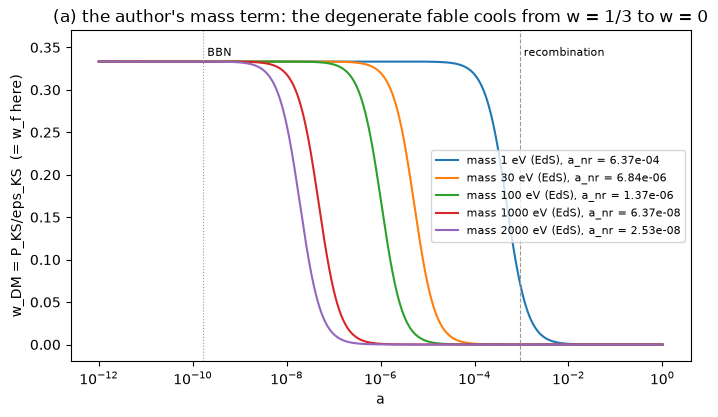

In [5]:
SUM = {}
MASS_RUNS = []
for m in (1, 30, 100, 1000, 2000):
    name = f'nb06_mass_m{m}_4d'
    run_fermion(name, 'fable4d', '--potential', 'mass', '--param', f'm0_ev={m}', '--points', str(POINTS), label=f'mass {m} eV (EdS)', quiet=True)
    MASS_RUNS.append(name)
    c = RUNS[name]['cols']
    assert np.max(np.abs(c['rho_U'])) == 0.0 and np.max(np.abs(c['w_f'] - c['w_qp'])) < 1e-12
    SUM[name] = summarize(RUNS[name])
print(f"\n{'run':26s} {'kF0 [eV]':>10s} {'a_nr':>10s} {'a_i ok':>6s} {'dNeff BBN':>10s} {'dNeff rec':>10s} {'3P/rho_nu rec':>13s} {'q0':>8s} {'t0 [Gyr]':>8s} {'Omega_f0':>8s}")
for n in MASS_RUNS:
    s = SUM[n]
    print(f"{s['label']:26s} {s['kF0_eV']:10.4e} {s['a_nr']:10.4e} {str(s['a_start_ok']):>6s} {s['Neff_BBN']:10.4g} {s['Neff_rec']:10.4g} {s['Neff_rec_rad']:13.4g} {s['q0']:8.5f} {s['t0_Gyr']:8.4f} {s['Omega_f0']:8.5f}")
    assert s['a_start_ok'] and abs(s['q0'] - 0.5) < 1e-3
fig, ax = plt.subplots(figsize=(8, 4.3))
for n in MASS_RUNS:
    c = RUNS[n]['cols']
    ax.semilogx(c['a'], c['w_qp'], label=RUNS[n]['label'] + f", a_nr = {SUM[n]['a_nr']:.2e}")
ax.axvline(A_BBN, color='0.6', ls=':', lw=0.8); ax.axvline(A_REC, color='0.6', ls='--', lw=0.8)
ax.text(A_BBN, 0.34, ' BBN', fontsize=8); ax.text(A_REC, 0.34, ' recombination', fontsize=8)
ax.set_xlabel('a'); ax.set_ylabel('w_DM = P_KS/eps_KS  (= w_f here)'); ax.set_ylim(-0.02, 0.37); ax.legend(fontsize=8)
ax.set_title('(a) the author\'s mass term: the degenerate fable cools from w = 1/3 to w = 0')
fig.savefig(RESULTS / 'nb06_a_mass_wdm.png', dpi=130, bbox_inches='tight'); print('figure: results/nb06_a_mass_wdm.png'); plt.show()

### 5.3 (b) A mass term plus a bare cosmological constant: ΛCDM with fable dark matter

`W = V0 + m0 σ`, `m0 = 30, 100, 1000, 2000 eV`, `fable4d`, with the quasiparticles carrying
`Ω_qp0 = 0.265` today and `V0` (a bare `Λ`, reported as such) closing the budget.  The mass does not vary,
so `w_DM,eff = w_DM` and `Q = 0`; the condensate is the constant `V0`, so the dark energy an observer
infers must be a cosmological constant: `w_DE,inf = −1` and its CPL fit `(−1, 0)`, to the precision of
the kinetic energy of the quasiparticles that the observer counts as dark energy.  The cell asserts
both, tabulates `a_nr`, `ΔN_eff`, the CPL fit of the intrinsic `w_f` (which is not a dark-energy
equation of state: it mixes the gas and `V0`), `q0` and the age, and plots `w_f`, `w_DM` and `w_DE,inf`.
A fifth run, `lambda-mass 30 eV` from `a_i = 1e−10` on 701 rows, is the reference case of Part VIII of
the Mathematica notebook; it is written to `results/nb06_fable4d_mass30eV.csv`, the name under which
Part VIII compares it with its own solution, and 5.5 compares the two here.

$ fable_fermion fable4d --potential lambda-mass --param m0_ev=30 --points 1001 --out results/nb06_lm_m30_4d.csv
  # stats: model=fable4d direction=Forward potential=lambda-mass steps=430 rhs_evals=542 nonlin_iters=539 err_test_fails=25 jac_evals=8 wall=0.010s (summed over every CVODE integration of the run, shooting included)
$ fable_fermion fable4d --potential lambda-mass --param m0_ev=100 --points 1001 --out results/nb06_lm_m100_4d.csv
  # stats: model=fable4d direction=Forward potential=lambda-mass steps=418 rhs_evals=515 nonlin_iters=512 err_test_fails=21 jac_evals=8 wall=0.010s (summed over every CVODE integration of the run, shooting included)
$ fable_fermion fable4d --potential lambda-mass --param m0_ev=1000 --points 1001 --out results/nb06_lm_m1000_4d.csv


  # stats: model=fable4d direction=Forward potential=lambda-mass steps=407 rhs_evals=509 nonlin_iters=506 err_test_fails=21 jac_evals=8 wall=0.009s (summed over every CVODE integration of the run, shooting included)
$ fable_fermion fable4d --potential lambda-mass --param m0_ev=2000 --points 1001 --out results/nb06_lm_m2000_4d.csv
  # stats: model=fable4d direction=Forward potential=lambda-mass steps=425 rhs_evals=527 nonlin_iters=524 err_test_fails=21 jac_evals=8 wall=0.010s (summed over every CVODE integration of the run, shooting included)
$ fable_fermion fable4d --potential lambda-mass --param m0_ev=30 --param omega_dm=0.265 --a-start 1e-10 --points 701 --out results/nb06_fable4d_mass30eV.csv
  # stats: model=fable4d direction=Forward potential=lambda-mass steps=429 rhs_evals=548 nonlin_iters=545 err_test_fails=29 jac_evals=8 wall=0.008s (summed over every CVODE integration of the run, shooting included)

run                                      a_nr  dNeff BBN  dNeff rec     CPL w_

figure: results/nb06_b_lambda_mass.png


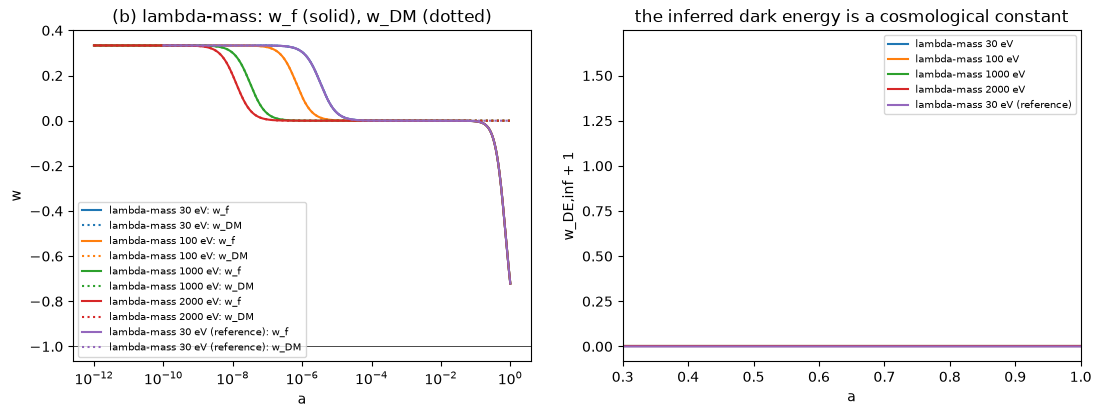

In [6]:
LM_RUNS = []
for m in (30, 100, 1000, 2000):
    name = f'nb06_lm_m{m}_4d'
    run_fermion(name, 'fable4d', '--potential', 'lambda-mass', '--param', f'm0_ev={m}', '--points', str(POINTS), label=f'lambda-mass {m} eV', quiet=True)
    LM_RUNS.append(name)
    c = RUNS[name]['cols']
    SUM[name] = s = summarize(RUNS[name])
    assert np.max(np.abs(c['w_DM_eff'] - c['w_DM_intrinsic'])) == 0.0 and np.max(np.abs(c['Q'])) == 0.0
    assert abs(s['cpl_wDEinf'][0] + 1) < 1e-6 and abs(s['cpl_wDEinf'][1]) < 1e-6, s['cpl_wDEinf']
# the reference case of Part VIII of the Mathematica notebook (compared with NDSolve in 5.5): exactly this command
run_fermion('nb06_fable4d_mass30eV', 'fable4d', '--potential', 'lambda-mass', '--param', 'm0_ev=30', '--param', 'omega_dm=0.265', '--a-start', '1e-10',
            '--points', '701', label='lambda-mass 30 eV (reference)', quiet=True)
LM_RUNS.append('nb06_fable4d_mass30eV')
SUM['nb06_fable4d_mass30eV'] = s = summarize(RUNS['nb06_fable4d_mass30eV'])
assert abs(s['cpl_wDEinf'][0] + 1) < 1e-6 and abs(s['cpl_wDEinf'][1]) < 1e-6 and s['a_start_ok']
print(f"\n{'run':34s} {'a_nr':>10s} {'dNeff BBN':>10s} {'dNeff rec':>10s} {'CPL w_f (w0, wa)':>20s} {'CPL w_DE,inf (w0, wa)':>26s} {'max|w_DE,inf+1| a>=0.3':>22s} {'q0':>8s} {'t0 [Gyr]':>8s} {'V0 = rho_U':>10s}")
for n in LM_RUNS:
    s, c = SUM[n], RUNS[n]['cols']
    late = c['a'] >= 0.3
    print(f"{s['label']:34s} {s['a_nr']:10.4e} {s['Neff_BBN']:10.4g} {s['Neff_rec']:10.4g} ({s['cpl_wf'][0]:+.4f}, {s['cpl_wf'][1]:+.4f})   "
          f"({s['cpl_wDEinf'][0]:+.10f}, {s['cpl_wDEinf'][1]:+.2e}) {np.max(np.abs(c['w_DE_inf'][late] + 1)):22.2e} {s['q0']:8.5f} {s['t0_Gyr']:8.4f} {c['rho_U'][-1]:10.6f}")
fig, ax = plt.subplots(1, 2, figsize=(13, 4.3))
for n in LM_RUNS:
    c = RUNS[n]['cols']
    l, = ax[0].semilogx(c['a'], c['w_f'], label=f"{RUNS[n]['label']}: w_f")
    ax[0].semilogx(c['a'], c['w_DM_intrinsic'], ':', color=l.get_color(), label=f"{RUNS[n]['label']}: w_DM")
    ax[1].plot(c['a'], c['w_DE_inf'] + 1, color=l.get_color(), label=RUNS[n]['label'])
ax[0].axhline(-1, color='k', lw=0.5); ax[0].set_xlabel('a'); ax[0].set_ylabel('w'); ax[0].legend(fontsize=7); ax[0].set_title('(b) lambda-mass: w_f (solid), w_DM (dotted)')
ax[1].set_xlim(0.3, 1.0); ax[1].set_xlabel('a'); ax[1].set_ylabel('w_DE,inf + 1'); ax[1].legend(fontsize=7)
ax[1].set_title('the inferred dark energy is a cosmological constant'); ax[1].ticklabel_format(axis='y', style='sci', scilimits=(0, 0))
fig.savefig(RESULTS / 'nb06_b_lambda_mass.png', dpi=130, bbox_inches='tight'); print('figure: results/nb06_b_lambda_mass.png'); plt.show()

### 5.4 (c) Potentials with which the fable supplies the dark energy itself

`power` with `ν = 0.236` and `ν = 0.5`, `expdamp` (Part VI's `xt = σ_t/s1 = 1/2.21`) and the attractive
`quadratic` (`gq = −0.5`), each with `m_today = 30` and `100 eV`, `fable4d`.  Here the mass varies, the
condensate `ρ_U` varies, and the fluid exchanges energy between its two parts (`Q = σ8 dm/dt`).  The
cell runs the eight cases and prints, for each: `a_nr`; the smallest `m_eff/m_today` over the matter
era `1e−3 ≤ a ≤ 0.3` (a fable that is massless there is not dark matter); `w_f` today, its minimum over
the run and its CPL fit; the dark energy an observer infers (subtracting cold dark matter with today's
mass): the scale factors at which its density `ρ_DE,inf` changes sign (poles of `w_DE,inf`), those at
which it crosses `w = −1`, whether it is phantom in `0.3 ≤ a ≤ 1`, and its CPL fit (over
`[max(0.3, 1.05 a_pole), 1]` when a pole lies inside the supernova range); the smallest adiabatic sound
speed `c_s²` and the ranges where it is negative (an adiabatic instability); the range of `w_DM,eff`;
the Dirac-sea energy `ΔE_vac(m(t)) − ΔE_vac(m_today)` relative to the total density (largest over
`a ≥ 0.3`); and the stabilizer today.  A ninth run is the mass-varying reference case of Part VIII of
the Mathematica notebook: `power` with `ν = 0.5`, `m_today = 100 eV` and a larger quasiparticle share
`Ω_qp0 = 0.55`, from `a_i = 1e−10` on 701 rows, written to `results/nb06_fable4d_power.csv`; with that
share the bare mass `m0` is positive and the fable stays massive (5.6 explains why).

**The inferred dark energy of a massive power law, in closed form.**  Once the gas is non-relativistic,
`σ8 ≈ n ∝ a^{−3}`, the condensate is `U = U_t a^{−3ν}` and the mass `m(a) = m0 + ν U_t a^{3(1−ν)}/((1 − ν) σ_t)`.
Subtracting cold dark matter with today's mass leaves `ρ_DE,inf = U + (m(a) − m_today) n = U_t [a^{−3ν} −
ν a^{−3}]/(1 − ν)` and `P_DE = −U`, hence

    w_DE,inf(a) = −(1 − ν) / (1 − ν a^{−3(1−ν)}) :

a pole at `a_pole = ν^{1/(3(1−ν))}`, `w > 0` before it, phantom (`w < −1`) between it and today, and
`w = −1` at `a = 1` up to the quasiparticles' kinetic energy (which makes it cross −1 just before today).
It depends on `ν` alone, not on `m_today` or `Ω_qp0`.  The cell checks it against the solver's column for
the three runs that stay massive (the two `ν = 0.236` runs and the reference run).  It also checks that the solver's `w_DE_inf` equals
`P_obs_f/(ρ_f − m_today n_today A^{−3})`, as it must in `fable4d`, and computes the second convention of
the subtraction, `ε_KS(today) A^{−3}` (the full quasiparticle energy today, kinetic part included).

In [7]:
DE_RUNS = []
DE_SPECS = [('power', 'nu=0.236', 'power nu=0.236'), ('power', 'nu=0.5', 'power nu=0.5'), ('expdamp', 'xt=0.4524886877828054', 'expdamp xt=1/2.21'),
            ('quadratic', 'gq=-0.5', 'quadratic gq=-0.5')]
for pot, par, lab in DE_SPECS:
    for m in (30, 100):
        name = f"nb06_{pot}{'_' + par.split('=')[1] if pot == 'power' else ''}_m{m}_4d"
        run_fermion(name, 'fable4d', '--potential', pot, '--param', par, '--param', f'm_today_ev={m}', '--points', str(POINTS), label=f'{lab}, {m} eV', quiet=True)
        DE_RUNS.append(name)
        SUM[name] = summarize(RUNS[name])
# the mass-varying reference case of Part VIII (compared with NDSolve in 5.5): exactly this command
run_fermion('nb06_fable4d_power', 'fable4d', '--potential', 'power', '--param', 'm_today_ev=100', '--param', 'nu=0.5', '--param', 'omega_dm=0.55',
            '--a-start', '1e-10', '--points', '701', label='power nu=0.5, 100 eV, Omega_qp0=0.55', quiet=True)
DE_RUNS.append('nb06_fable4d_power')
SUM['nb06_fable4d_power'] = summarize(RUNS['nb06_fable4d_power'])
ALT = {}
for n in DE_RUNS:
    c, s = RUNS[n]['cols'], SUM[n]
    a = c['a']
    rho_tot = c['rho_r'] + c['rho_b'] + c['rho_f']
    dust0 = abs(c['m_eff'][-1]) * c['n_f'][-1]
    ok = np.abs(c['rho_DE_inf']) > 1e-3 * rho_tot
    w_formula = c['P_obs_f'] / (c['rho_f'] - dust0 * a ** -3)
    assert np.max(np.abs(w_formula[ok] - c['w_DE_inf'][ok]) / np.maximum(1, np.abs(c['w_DE_inf'][ok]))) < 1e-6
    ALT[n] = de_bookkeeping(a, c['rho_f'] - c['rho_qp'][-1] * a ** -3, c['P_obs_f'], rho_tot)
print(f"\n{'run':38s} {'a_nr':>9s} {'min m/m1':>9s} {'w_f(1)':>8s} {'min w_f':>8s} {'CPL w_f':>17s} {'poles of w_DE,inf':>22s} {'w=-1 crossings':>22s} {'phantom?':>8s} {'CPL w_DE,inf':>17s} {'from a':>6s} {'min cs2':>9s}")
for n in DE_RUNS:
    s = SUM[n]; d = s['de']
    print(f"{s['label']:38s} {s['a_nr']:9.3g} {s['m_ratio_min_matter']:9.2e} {s['w_f_today']:8.4f} {s['w_f_min']:8.4f} ({s['cpl_wf'][0]:+.3f}, {s['cpl_wf'][1]:+.3f}) "
          f"{', '.join(f'{x:.3g}' for x in d['poles']):>22s} {', '.join(f'{x:.6g}' for x in d['cross']):>22s} {str(d['phantom_late']):>8s} ({d['cpl'][0]:+.3f}, {d['cpl'][1]:+.3f}) {d['amin']:6.3f} {s['cs2_min']:9.3g}")
print(f"\n{'run':38s} {'cs2 < 0 on (a >= 1e-3)':>34s} {'w_DM,eff range (a >= 1e-3)':>28s} {'|dE_vac|/rho_tot, a>=0.3':>24s} {'P_stab(1)':>10s} {'dNeff BBN':>9s}   second convention (eps_KS(1) a^-3): poles; crossings; CPL")
for n in DE_RUNS:
    s, d2 = SUM[n], ALT[n]
    print(f"{s['label']:38s} {fmt_ranges(s['cs2_neg'], 2):>34s} ({s['wDMeff_range'][0]:+10.3g}, {s['wDMeff_range'][1]:+8.3g}) {s['vac_ratio_late']:24.3e} {s['P_stab_today']:10.4f} {s['Neff_BBN']:9.4f}   "
          f"{', '.join(f'{x:.3g}' for x in d2['poles'])}; {', '.join(f'{x:.3g}' for x in d2['cross'])}; ({d2['cpl'][0]:+.3f}, {d2['cpl'][1]:+.3f})")
for n in DE_RUNS:
    assert SUM[n]['w_f_min'] >= -1 - 1e-12 and SUM[n]['a_start_ok']
for n in ('nb06_power_0.236_m30_4d', 'nb06_power_0.236_m100_4d', 'nb06_fable4d_power'):
    c, s, p = RUNS[n]['cols'], SUM[n], RUNS[n]['params']
    nu_ = p['nu']
    a = c['a']
    rho_tot = c['rho_r'] + c['rho_b'] + c['rho_f']
    w_an = -(1 - nu_) / (1 - nu_ * a ** (-3 * (1 - nu_)))
    sel = (a >= 0.3) & (np.abs(c['rho_DE_inf']) > 1e-2 * rho_tot)
    dev = np.max(np.abs(w_an[sel] - c['w_DE_inf'][sel]) / np.maximum(1, np.abs(c['w_DE_inf'][sel])))
    a_pole = nu_ ** (1 / (3 * (1 - nu_)))
    print(f"{s['label']:38s} w_DE,inf against -(1-nu)/(1 - nu a^(-3(1-nu))) on a >= 0.3: max deviation {dev:.1e};  pole: formula {a_pole:.6f}, "
          f"run {', '.join(f'{x:.6f}' for x in s['de']['poles_late'])};  crossing of -1: {', '.join(f'{x:.8f}' for x in s['de']['cross_late'])}")
    assert dev < 1e-6 and len(s['de']['poles_late']) == 1 and abs(s['de']['poles_late'][0] / a_pole - 1) < 1e-3
print(f"\nsmallest w_f over all {len(DE_RUNS)} runs: {min(SUM[n]['w_f_min'] for n in DE_RUNS):+.10f} (never below -1);  every run has c_s^2 < 0 somewhere after a = 1e-3: {all(SUM[n]['cs2_neg'] for n in DE_RUNS)}")

$ fable_fermion fable4d --potential power --param nu=0.236 --param m_today_ev=30 --points 1001 --out results/nb06_power_0.236_m30_4d.csv
  # stats: model=fable4d direction=Forward potential=power steps=390 rhs_evals=482 nonlin_iters=479 err_test_fails=20 jac_evals=7 wall=0.011s (summed over every CVODE integration of the run, shooting included)
$ fable_fermion fable4d --potential power --param nu=0.236 --param m_today_ev=100 --points 1001 --out results/nb06_power_0.236_m100_4d.csv
  # stats: model=fable4d direction=Forward potential=power steps=401 rhs_evals=505 nonlin_iters=502 err_test_fails=23 jac_evals=7 wall=0.010s (summed over every CVODE integration of the run, shooting included)
$ fable_fermion fable4d --potential power --param nu=0.5 --param m_today_ev=30 --points 1001 --out results/nb06_power_0.5_m30_4d.csv
  # stats: model=fable4d direction=Forward potential=power steps=430 rhs_evals=551 nonlin_iters=548 err_test_fails=26 jac_evals=8 wall=0.021s (summed over every CVODE inte

  # stats: model=fable4d direction=Forward potential=expdamp steps=423 rhs_evals=527 nonlin_iters=524 err_test_fails=21 jac_evals=8 wall=0.019s (summed over every CVODE integration of the run, shooting included)
$ fable_fermion fable4d --potential expdamp --param xt=0.4524886877828054 --param m_today_ev=100 --points 1001 --out results/nb06_expdamp_m100_4d.csv
  # stats: model=fable4d direction=Forward potential=expdamp steps=434 rhs_evals=542 nonlin_iters=539 err_test_fails=23 jac_evals=8 wall=0.019s (summed over every CVODE integration of the run, shooting included)
$ fable_fermion fable4d --potential quadratic --param gq=-0.5 --param m_today_ev=30 --points 1001 --out results/nb06_quadratic_m30_4d.csv
  # stats: model=fable4d direction=Forward potential=quadratic steps=451 rhs_evals=562 nonlin_iters=559 err_test_fails=23 jac_evals=8 wall=0.012s (summed over every CVODE integration of the run, shooting included)
$ fable_fermion fable4d --potential quadratic --param gq=-0.5 --param m_to

The figures of (c).  Top left: `w_f` (never below −1).  Top right: the observer's `w_DE,inf`, clipped to
`[−3, 1]`, with its poles (dotted verticals) and its crossings of −1 (dots).  Bottom left:
`m_eff/m_today`.  Bottom right: the adiabatic sound speed `c_s²` on a symmetric-log scale, negative below
the line.  The second figure shows `w_DM` and `w_DM,eff`, the energy exchange `Q`, the Dirac-sea
energy relative to the total density, and the stabilizing stress `P_stab/ρ`.

figure: results/nb06_c_de_potentials.png


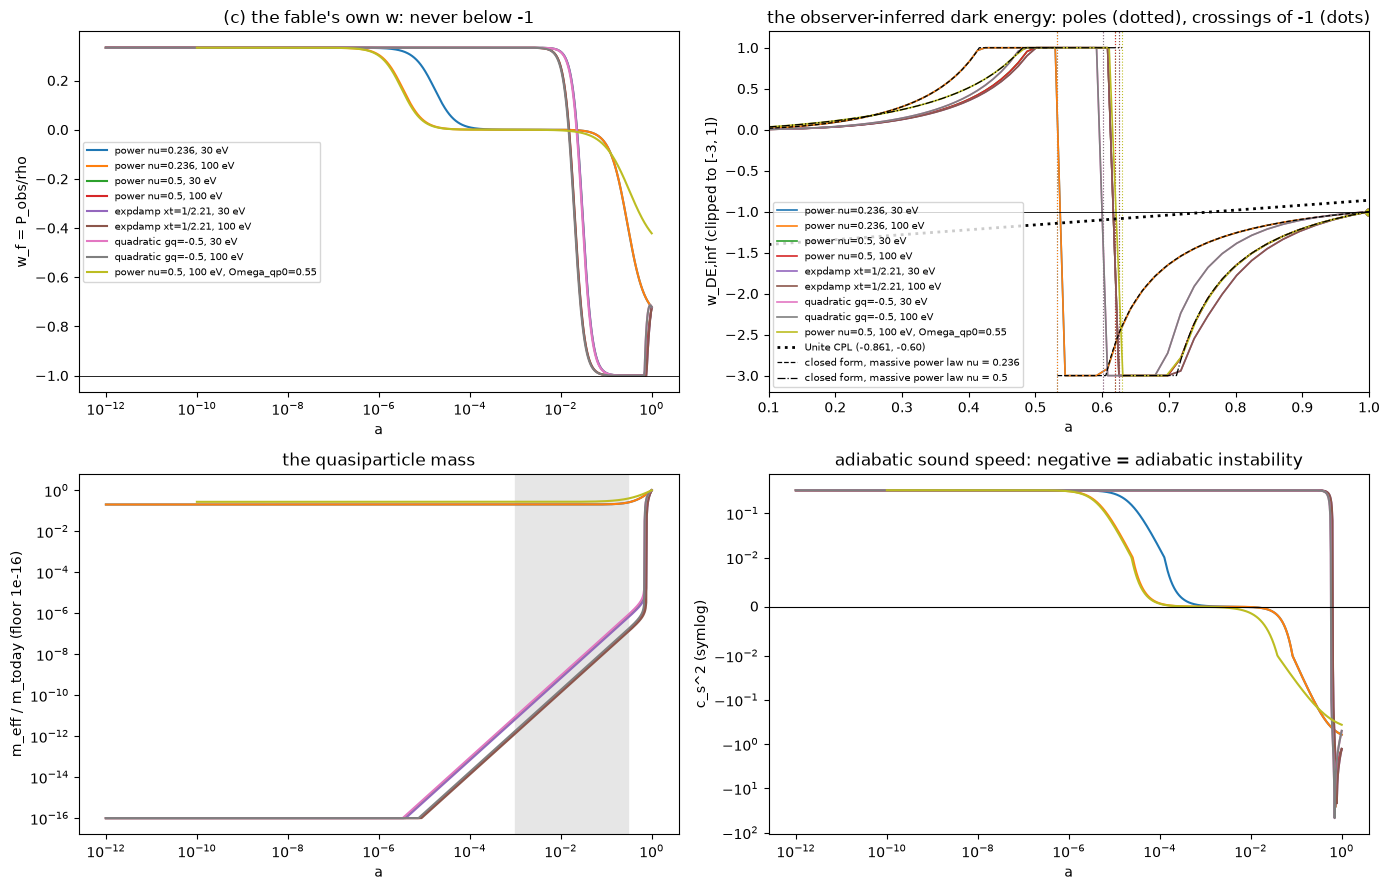

figure: results/nb06_c_exchange_vacuum_stabilizer.png


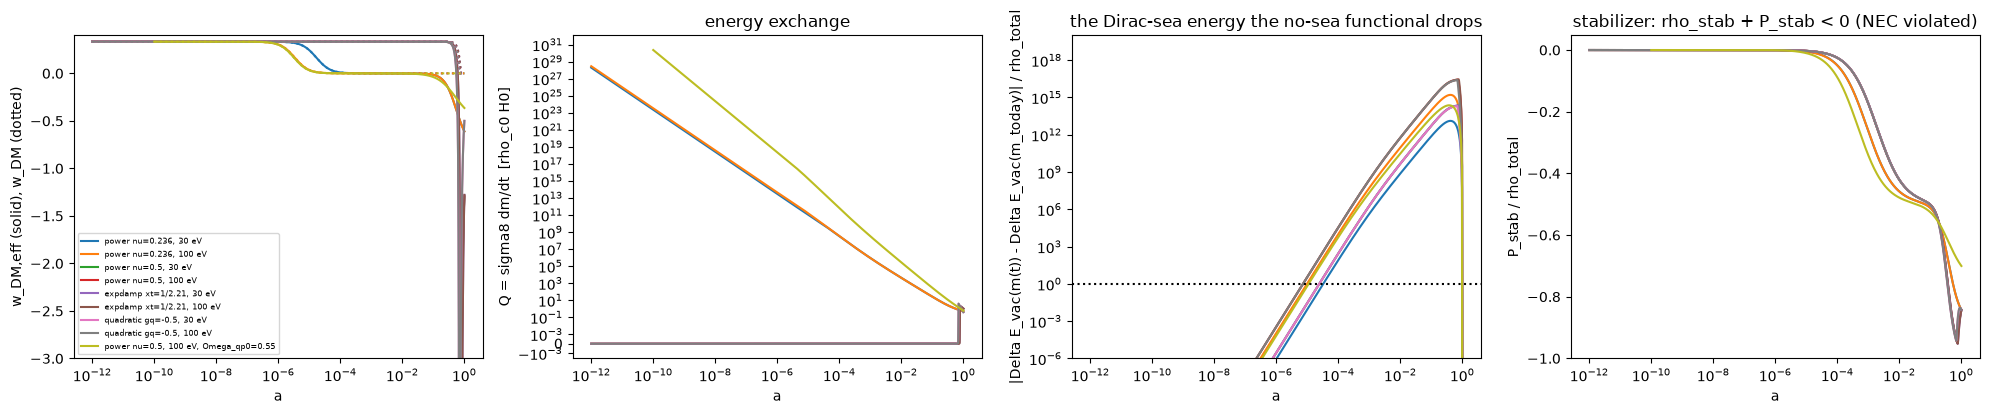

In [8]:
fig, ax = plt.subplots(2, 2, figsize=(14, 9))
for n in DE_RUNS:
    c, s = RUNS[n]['cols'], SUM[n]
    a = c['a']
    l, = ax[0, 0].semilogx(a, c['w_f'], label=s['label'])
    ax[0, 1].plot(a, np.clip(c['w_DE_inf'], -3, 1), color=l.get_color(), lw=1.2, label=s['label'])
    for x in s['de']['poles']:
        if 0.1 <= x <= 1:
            ax[0, 1].axvline(x, color=l.get_color(), ls=':', lw=0.8)
    for x in s['de']['cross']:
        if 0.1 <= x <= 1:
            ax[0, 1].plot(x, -1, 'o', color=l.get_color(), ms=5)
    ax[1, 0].loglog(a, np.maximum(np.abs(c['m_eff'] / c['m_eff'][-1]), 1e-16), color=l.get_color(), label=s['label'])
    ax[1, 1].semilogx(a, c['cs2_adiabatic'], color=l.get_color(), label=s['label'])
ax[0, 0].axhline(-1, color='k', lw=0.6); ax[0, 0].set_ylabel('w_f = P_obs/rho'); ax[0, 0].set_xlabel('a'); ax[0, 0].legend(fontsize=7)
ax[0, 0].set_title('(c) the fable\'s own w: never below -1')
au = np.linspace(0.1, 1, 100)
ax[0, 1].plot(au, UNITE_W0 + UNITE_WA * (1 - au), 'k:', lw=2, label='Unite CPL (-0.861, -0.60)')
af = np.linspace(0.1, 1, 2000)
for nu_, ls in ((0.236, '--'), (0.5, '-.')):
    wf_ = -(1 - nu_) / (1 - nu_ * af ** (-3 * (1 - nu_)))
    wf_[np.abs(1 - nu_ * af ** (-3 * (1 - nu_))) < 1e-3] = np.nan
    ax[0, 1].plot(af, np.clip(wf_, -3, 1), 'k', ls=ls, lw=0.9, label=f'closed form, massive power law nu = {nu_}')
ax[0, 1].axhline(-1, color='k', lw=0.6); ax[0, 1].set_xlim(0.1, 1); ax[0, 1].set_xlabel('a'); ax[0, 1].set_ylabel('w_DE,inf (clipped to [-3, 1])')
ax[0, 1].set_title('the observer-inferred dark energy: poles (dotted), crossings of -1 (dots)'); ax[0, 1].legend(fontsize=7)
ax[1, 0].set_xlabel('a'); ax[1, 0].set_ylabel('m_eff / m_today (floor 1e-16)'); ax[1, 0].set_title('the quasiparticle mass'); ax[1, 0].axvspan(1e-3, 0.3, color='0.9')
ax[1, 1].set_yscale('symlog', linthresh=1e-2); ax[1, 1].axhline(0, color='k', lw=0.8); ax[1, 1].set_xlabel('a'); ax[1, 1].set_ylabel('c_s^2 (symlog)')
ax[1, 1].set_title('adiabatic sound speed: negative = adiabatic instability')
fig.tight_layout(); fig.savefig(RESULTS / 'nb06_c_de_potentials.png', dpi=130, bbox_inches='tight'); print('figure: results/nb06_c_de_potentials.png'); plt.show()

fig, ax = plt.subplots(1, 4, figsize=(20, 4.2))
for n in DE_RUNS:
    c, s = RUNS[n]['cols'], SUM[n]
    a = c['a']
    rho_tot = c['rho_r'] + c['rho_b'] + c['rho_f']
    l, = ax[0].semilogx(a, c['w_DM_eff'], label=s['label'])
    ax[0].semilogx(a, c['w_DM_intrinsic'], ':', color=l.get_color())
    ax[1].semilogx(a, c['Q'], color=l.get_color())
    ax[2].loglog(a, np.maximum(np.abs(c['vac_over_rhoc']) / rho_tot, 1e-30), color=l.get_color())
    ax[3].semilogx(a, c['P_stab'] / rho_tot, color=l.get_color())
ax[0].set_ylim(-3, 0.4); ax[0].set_xlabel('a'); ax[0].set_ylabel('w_DM,eff (solid), w_DM (dotted)'); ax[0].legend(fontsize=6)
ax[1].set_yscale('symlog', linthresh=1e-3); ax[1].set_xlabel('a'); ax[1].set_ylabel('Q = sigma8 dm/dt  [rho_c0 H0]'); ax[1].set_title('energy exchange')
ax[2].axhline(1, color='k', ls=':'); ax[2].set_ylim(1e-6, 1e20); ax[2].set_xlabel('a'); ax[2].set_ylabel('|Delta E_vac(m(t)) - Delta E_vac(m_today)| / rho_total')
ax[2].set_title('the Dirac-sea energy the no-sea functional drops')
ax[3].set_xlabel('a'); ax[3].set_ylabel('P_stab / rho_total'); ax[3].set_title('stabilizer: rho_stab + P_stab < 0 (NEC violated)')
fig.tight_layout(); fig.savefig(RESULTS / 'nb06_c_exchange_vacuum_stabilizer.png', dpi=130, bbox_inches='tight'); print('figure: results/nb06_c_exchange_vacuum_stabilizer.png'); plt.show()

### 5.5 Three implementations on two reference cases: CVODE (Rust), scipy, and Mathematica

Part VIII of the Mathematica notebook solves two `fable4d` cases independently —
`fable-cosmology/reference/make_reference_fermion.wls` evaluates the Fermi-sea closed forms and the gap at
40 significant digits and integrates the age with `NDSolve` at 30-digit working precision — and writes
`reference/mathematica_fable4d_mass30eV.csv` (`lambda-mass`, `m0 = 30 eV`, `Ω_qp0 = 0.265`) and
`reference/mathematica_fable4d_power.csv` (`power`, `ν = 0.5`, `m_today = 100 eV`, `Ω_qp0 = 0.55`), both
on 701 values of `N` from `ln 1e−10` to 0, with the same unit system as the Rust solver.  The two runs
of the same cases above wrote `results/nb06_fable4d_mass30eV.csv` and `results/nb06_fable4d_power.csv`
on the same grid.  The cell compares all three pairwise, column by column: `t`, `H_A`, `ρ_f`, `P_obs_f`,
`m_eff`, `σ`, `kF/m` relative, `w_f` absolute; the scipy side is the independent implementation of 5.10
(quadrature, `brentq`, and adaptive quadrature for the age).  It fails if any difference exceeds `1e−6`,
the tolerance Part VIII uses.

In [9]:
three = []
for name, fn in (('nb06_fable4d_mass30eV', 'mathematica_fable4d_mass30eV.csv'), ('nb06_fable4d_power', 'mathematica_fable4d_power.csv')):
    path = REFERENCE / fn
    assert path.exists(), f'the Mathematica reference {path} is missing'
    with open(path, newline='') as f:
        rr = list(csv.DictReader(f))
    ref = {k: np.array([float(r[k]) for r in rr]) for k in rr[0]}
    c, p = RUNS[name]['cols'], RUNS[name]['params']
    assert len(ref['N']) == len(c['N']) and np.max(np.abs(ref['N'] - c['N'])) < 1e-12, 'the reference grid must be the solver grid'
    py = py_run(p, c['N'])
    row = dict(case=name)
    for col in ('t', 'H_A', 'rho_f', 'P_obs_f', 'm_eff', 'sigma', 'kF_over_m'):
        row[f'rust-mathematica {col}'] = float(np.max(np.abs(c[col] - ref[col]) / np.abs(ref[col])))
    row['rust-mathematica w_f (abs)'] = float(np.max(np.abs(c['w_f'] - ref['w_f'])))
    row['scipy-mathematica H_A'] = float(np.max(np.abs(py['H_A'] - ref['H_A']) / ref['H_A']))
    row['scipy-mathematica rho_f'] = float(np.max(np.abs(py['rho_f'] - ref['rho_f']) / np.abs(ref['rho_f'])))
    row['scipy-mathematica P_obs_f'] = float(np.max(np.abs(py['P_obs_f'] - ref['P_obs_f']) / np.abs(ref['rho_f'])))
    row['scipy-mathematica m_eff'] = float(np.max(np.abs(py['m'] - ref['m_eff']) / np.abs(ref['m_eff'])))
    row['scipy-mathematica t(A=1)'] = float(abs(py['t_today'] / ref['t'][-1] - 1))
    three.append(row)
    print(f'{name}:  m_eff from {ref["m_eff"][0] * E_C_EV:.4f} eV (a = 1e-10) to {ref["m_eff"][-1] * E_C_EV:.4f} eV (today)')
    for k, v in row.items():
        if k != 'case':
            print(f'   max |difference| {k:32s} {v:.2e}')
    assert max(v for k, v in row.items() if k != 'case') < 1e-6
with open(RESULTS / 'nb06_threeway.csv', 'w', newline='') as f:
    wr = csv.DictWriter(f, fieldnames=list(three[0].keys())); wr.writeheader()
    wr.writerows([{k: (f'{v:.3e}' if isinstance(v, float) else v) for k, v in r.items()} for r in three])
print('written: results/nb06_threeway.csv;  CVODE, scipy and Mathematica agree to better than 1e-6 on both reference cases')

nb06_fable4d_mass30eV:  m_eff from 30.0000 eV (a = 1e-10) to 30.0000 eV (today)
   max |difference| rust-mathematica t               2.35e-09
   max |difference| rust-mathematica H_A             3.34e-11
   max |difference| rust-mathematica rho_f           1.27e-14
   max |difference| rust-mathematica P_obs_f         1.60e-13
   max |difference| rust-mathematica m_eff           1.79e-15
   max |difference| rust-mathematica sigma           9.94e-15
   max |difference| rust-mathematica kF_over_m       6.51e-15
   max |difference| rust-mathematica w_f (abs)       3.61e-15
   max |difference| scipy-mathematica H_A            3.35e-11
   max |difference| scipy-mathematica rho_f          1.42e-12
   max |difference| scipy-mathematica P_obs_f        1.17e-12
   max |difference| scipy-mathematica m_eff          2.99e-16
   max |difference| scipy-mathematica t(A=1)         2.66e-14
nb06_fable4d_power:  m_eff from 27.1519 eV (a = 1e-10) to 100.0000 eV (today)
   max |difference| rust-mathematica

### 5.6 Parameter scans: where does a dark-energy fable stay massive through the matter era?

The answers must not rest on one choice of shape parameter.  For each family that can supply the dark
energy the next cells scan the shape: `power` `ν = 0.05 … 0.65`, `quadratic` `gq = −0.95 … −0.05`,
`expdamp` `xt = 0.1 … 0.9`, at `m_today = 1 keV` (the mass scale that free streaming requires, 5.7) and
at `100 eV` (`fable4d`, 401 output rows, CSV from stdout); and, for `power` with `ν = 0.3` and `ν = 0.5`,
the quasiparticle share `Ω_qp0 = 0.265 … 0.8` (the condensate then carries the rest of the budget).  For every point: the smallest `m_eff/m_today`
over `1e−3 ≤ a ≤ 0.3` (below `1e−3` or so the fable is massless there and is not dark matter), `a_nr`,
the CPL fit of the observer-inferred `w_DE,inf` (with its poles), whether it is phantom or crosses −1
in `0.3 ≤ a ≤ 1`, the smallest `c_s²` after `a = 1e−3`, the smallest `w_f`, and the largest gap residual.
Every scan run is also re-computed with the independent implementation as it runs (5.10 lists the
result).  For the power law the scan also records the bare mass `m0 = m_today − ν λ σ_t^{ν−1}`: at high
density `ν λ σ^{ν−1} → 0`, so if `m0 < 0` the gap can only be met with `m → 0⁺` and the fable is a
massless gas until the density has fallen far enough; with `σ_t ≈ n_t` and `ε_KS ≈ m_today n_t` today
this happens exactly when `Ω_qp0/U_t < ν/(1 − ν)`, `U_t = 1 − Ω_qp0 − Ω_b0 − Ω_r0` the condensate today.
The cell checks that the sign of `m0` decides, at every power-law scan point, whether the fable stays
massive.  In the massless cases the smallest `c_s²` sits at the sharp release of the pinned gap, and its
magnitude depends on how finely the output grid samples that release; its sign does not.  The map is written to `results/nb06_scan.csv` and drawn in `results/nb06_scan.png` and
`results/nb06_scan_cpl.png`.

In [10]:
M_SCAN = 1000
SCAN_FAMILIES = [('power, nu', 'power', 'nu', [round(0.05 * k, 2) for k in range(1, 14)], []),
                 ('quadratic, gq', 'quadratic', 'gq', [round(-0.95 + 0.1 * k, 2) for k in range(10)], []),
                 ('expdamp, xt', 'expdamp', 'xt', [round(0.1 * k, 1) for k in range(1, 10)], []),
                 ('power nu=0.3, Omega_qp0', 'power', 'omega_dm', [0.265, 0.35, 0.45, 0.55, 0.65, 0.8], ['nu=0.3']),
                 ('power nu=0.5, Omega_qp0', 'power', 'omega_dm', [0.265, 0.35, 0.45, 0.5, 0.55, 0.65, 0.8], ['nu=0.5'])]
try:
    SCAN
except NameError:
    SCAN = []
for fam, pot, key, vals, fixed in SCAN_FAMILIES:
    for v in vals:
        name = f"scan_{pot}_{key}{v}{'_' + '_'.join(fixed) if fixed else ''}_m{M_SCAN}"
        extra = [x for f_ in fixed for x in ('--param', f_)]
        r = run_fermion(name, 'fable4d', '--potential', pot, '--param', f'{key}={v}', *extra, '--param', f'm_today_ev={M_SCAN}', '--points', '401',
                        keep=False, quiet=True, show_log=False, label=f'{fam}={v}, {M_SCAN} eV')
        s = summarize(r)
        xr = xcheck(r, conservation=True, stride=20)
        cc, pp = r['cols'], r['params']
        SCAN.append(dict(family=fam, key=key, value=v, m_today_eV=M_SCAN, m0_over_m_today=pp['m0'] / cc['m_eff'][-1],
                         omega_qp0=float(cc['rho_qp'][-1]), U_today=float(cc['rho_U'][-1]), a_nr=s['a_nr'], m_ratio_min_matter=s['m_ratio_min_matter'],
                         w0_DE=s['cpl_wDEinf'][0], wa_DE=s['cpl_wDEinf'][1], fit_from_a=s['de']['amin'],
                         poles=' '.join(f'{x:.3g}' for x in s['de']['poles']), crossings=' '.join(f'{x:.3g}' for x in s['de']['cross']),
                         phantom_late=s['de']['phantom_late'], crosses_late=bool(s['de']['cross_late']), w0_f=s['cpl_wf'][0], wa_f=s['cpl_wf'][1],
                         w_f_min=s['w_f_min'], cs2_min=float(np.nanmin(np.where(r['cols']['a'] >= 1e-3, r['cols']['cs2_adiabatic'], np.nan))),
                         vac_ratio_late=s['vac_ratio_late'], gap_residual_max=s['gap_residual_max'], xcheck_worst=xr['worst'], conservation=xr['conservation']))
        assert xr['worst'] < 1e-6 and s['w_f_min'] >= -1 - 1e-12
rows = [r for r in SCAN if r['m_today_eV'] == M_SCAN]
print(f"m_today = {M_SCAN} eV: {len(rows)} scan runs")
print(f"{'family':24s} {'value':>6s} {'m0/m1':>9s} {'min m/m1':>9s} {'a_nr':>8s} {'CPL w_DE,inf':>18s} {'from a':>6s} {'poles':>18s} {'phantom':>7s} {'cross':>5s} {'min cs2':>9s} {'min w_f':>8s} {'max gap res':>11s} {'xcheck':>8s} {'cons.':>8s}")
for r in rows:
    print(f"{r['family']:24s} {r['value']:6.3f} {r['m0_over_m_today']:9.3g} {r['m_ratio_min_matter']:9.2e} {r['a_nr']:8.3g} ({r['w0_DE']:+7.3f}, {r['wa_DE']:+7.3f}) {r['fit_from_a']:6.3f} {r['poles']:>18s} "
          f"{str(r['phantom_late']):>7s} {str(r['crosses_late']):>5s} {r['cs2_min']:9.3g} {r['w_f_min']:8.4f} {r['gap_residual_max']:11.1e} {r['xcheck_worst']:8.1e} {r['conservation']:8.1e}")

$ fable_fermion fable4d --potential power --param nu=0.05 --param m_today_ev=1000 --points 401
$ fable_fermion fable4d --potential power --param nu=0.1 --param m_today_ev=1000 --points 401
$ fable_fermion fable4d --potential power --param nu=0.15 --param m_today_ev=1000 --points 401
$ fable_fermion fable4d --potential power --param nu=0.2 --param m_today_ev=1000 --points 401


$ fable_fermion fable4d --potential power --param nu=0.25 --param m_today_ev=1000 --points 401
$ fable_fermion fable4d --potential power --param nu=0.3 --param m_today_ev=1000 --points 401


$ fable_fermion fable4d --potential power --param nu=0.35 --param m_today_ev=1000 --points 401


$ fable_fermion fable4d --potential power --param nu=0.4 --param m_today_ev=1000 --points 401


$ fable_fermion fable4d --potential power --param nu=0.45 --param m_today_ev=1000 --points 401


...

$ fable_fermion fable4d --potential power --param omega_dm=0.35 --param nu=0.5 --param m_today_ev=1000 --points 401


$ fable_fermion fable4d --potential power --param omega_dm=0.45 --param nu=0.5 --param m_today_ev=1000 --points 401


$ fable_fermion fable4d --potential power --param omega_dm=0.5 --param nu=0.5 --param m_today_ev=1000 --points 401
$ fable_fermion fable4d --potential power --param omega_dm=0.55 --param nu=0.5 --param m_today_ev=1000 --points 401


$ fable_fermion fable4d --potential power --param omega_dm=0.65 --param nu=0.5 --param m_today_ev=1000 --points 401
$ fable_fermion fable4d --potential power --param omega_dm=0.8 --param nu=0.5 --param m_today_ev=1000 --points 401


m_today = 1000 eV: 45 scan runs
family                    value     m0/m1  min m/m1     a_nr       CPL w_DE,inf from a              poles phantom cross   min cs2  min w_f max gap res   xcheck    cons.
power, nu                 0.050     0.864  8.64e-01 4.82e-08 ( -0.429,  -3.200)  0.367      6.37e-08 0.35    True False    -0.129  -0.7212     0.0e+00  1.1e-09  6.8e-12
power, nu                 0.100     0.713  7.13e-01 5.84e-08 ( -0.475,  -3.849)  0.448     4.55e-08 0.427    True False    -0.259  -0.7212     1.9e-16  1.6e-11  6.8e-12
power, nu                 0.150     0.543  5.43e-01 7.66e-08 ( -0.054,  -7.118)  0.500     3.78e-08 0.476    True False    -0.388  -0.7212     1.9e-16  1.7e-10  7.0e-12
power, nu                 0.200     0.353  3.53e-01 1.18e-07 ( -0.624,  -4.225)  0.538     3.36e-08 0.512    True False    -0.517  -0.7212     1.2e-16  3.7e-10  6.8e-12
power, nu                 0.250     0.138  1.38e-01 3.03e-07 ( -0.209,  -7.852)  0.567      3.16e-08 0.54    True False    

The same scan at `m_today = 100 eV`, then the map: for each family, the smallest `m_eff/m_today` in the
matter era and the smallest `c_s²` against the scanned parameter (both masses), the check of the
bare-mass criterion, and the CPL points of the inferred dark energy and of `w_f` in the `(w0, wa)` plane
next to Unite's.

$ fable_fermion fable4d --potential power --param nu=0.05 --param m_today_ev=100 --points 401
$ fable_fermion fable4d --potential power --param nu=0.1 --param m_today_ev=100 --points 401
$ fable_fermion fable4d --potential power --param nu=0.15 --param m_today_ev=100 --points 401


$ fable_fermion fable4d --potential power --param nu=0.2 --param m_today_ev=100 --points 401
$ fable_fermion fable4d --potential power --param nu=0.25 --param m_today_ev=100 --points 401
$ fable_fermion fable4d --potential power --param nu=0.3 --param m_today_ev=100 --points 401


$ fable_fermion fable4d --potential power --param nu=0.35 --param m_today_ev=100 --points 401


$ fable_fermion fable4d --potential power --param nu=0.4 --param m_today_ev=100 --points 401


$ fable_fermion fable4d --potential power --param nu=0.45 --param m_today_ev=100 --points 401


...

$ fable_fermion fable4d --potential power --param omega_dm=0.45 --param nu=0.5 --param m_today_ev=100 --points 401


$ fable_fermion fable4d --potential power --param omega_dm=0.5 --param nu=0.5 --param m_today_ev=100 --points 401
$ fable_fermion fable4d --potential power --param omega_dm=0.55 --param nu=0.5 --param m_today_ev=100 --points 401


$ fable_fermion fable4d --potential power --param omega_dm=0.65 --param nu=0.5 --param m_today_ev=100 --points 401
$ fable_fermion fable4d --potential power --param omega_dm=0.8 --param nu=0.5 --param m_today_ev=100 --points 401


m_today = 100 eV: 45 scan runs
family                    value     m0/m1  min m/m1     a_nr       CPL w_DE,inf from a              poles phantom cross   min cs2  min w_f max gap res   xcheck    cons.
power, nu                 0.050     0.864  8.64e-01 1.04e-06 ( -0.429,  -3.200)  0.367      1.38e-06 0.35    True  True    -0.129  -0.7212     0.0e+00  6.4e-10  9.2e-12
power, nu                 0.100     0.713  7.13e-01 1.26e-06 ( -0.475,  -3.849)  0.448     9.81e-07 0.427    True  True    -0.259  -0.7212     1.9e-16  2.3e-10  9.3e-12
power, nu                 0.150     0.543  5.43e-01 1.65e-06 ( -0.054,  -7.118)  0.500     8.12e-07 0.476    True  True    -0.388  -0.7212     1.6e-16  4.2e-10  9.4e-12
power, nu                 0.200     0.353  3.53e-01 2.54e-06 ( -0.624,  -4.225)  0.538     7.26e-07 0.512    True  True    -0.517  -0.7212     1.4e-16  1.6e-09  9.5e-12
power, nu                 0.250     0.138  1.38e-01 6.52e-06 ( -0.209,  -7.852)  0.567      6.83e-07 0.54    True  True    -

figure: results/nb06_scan.png


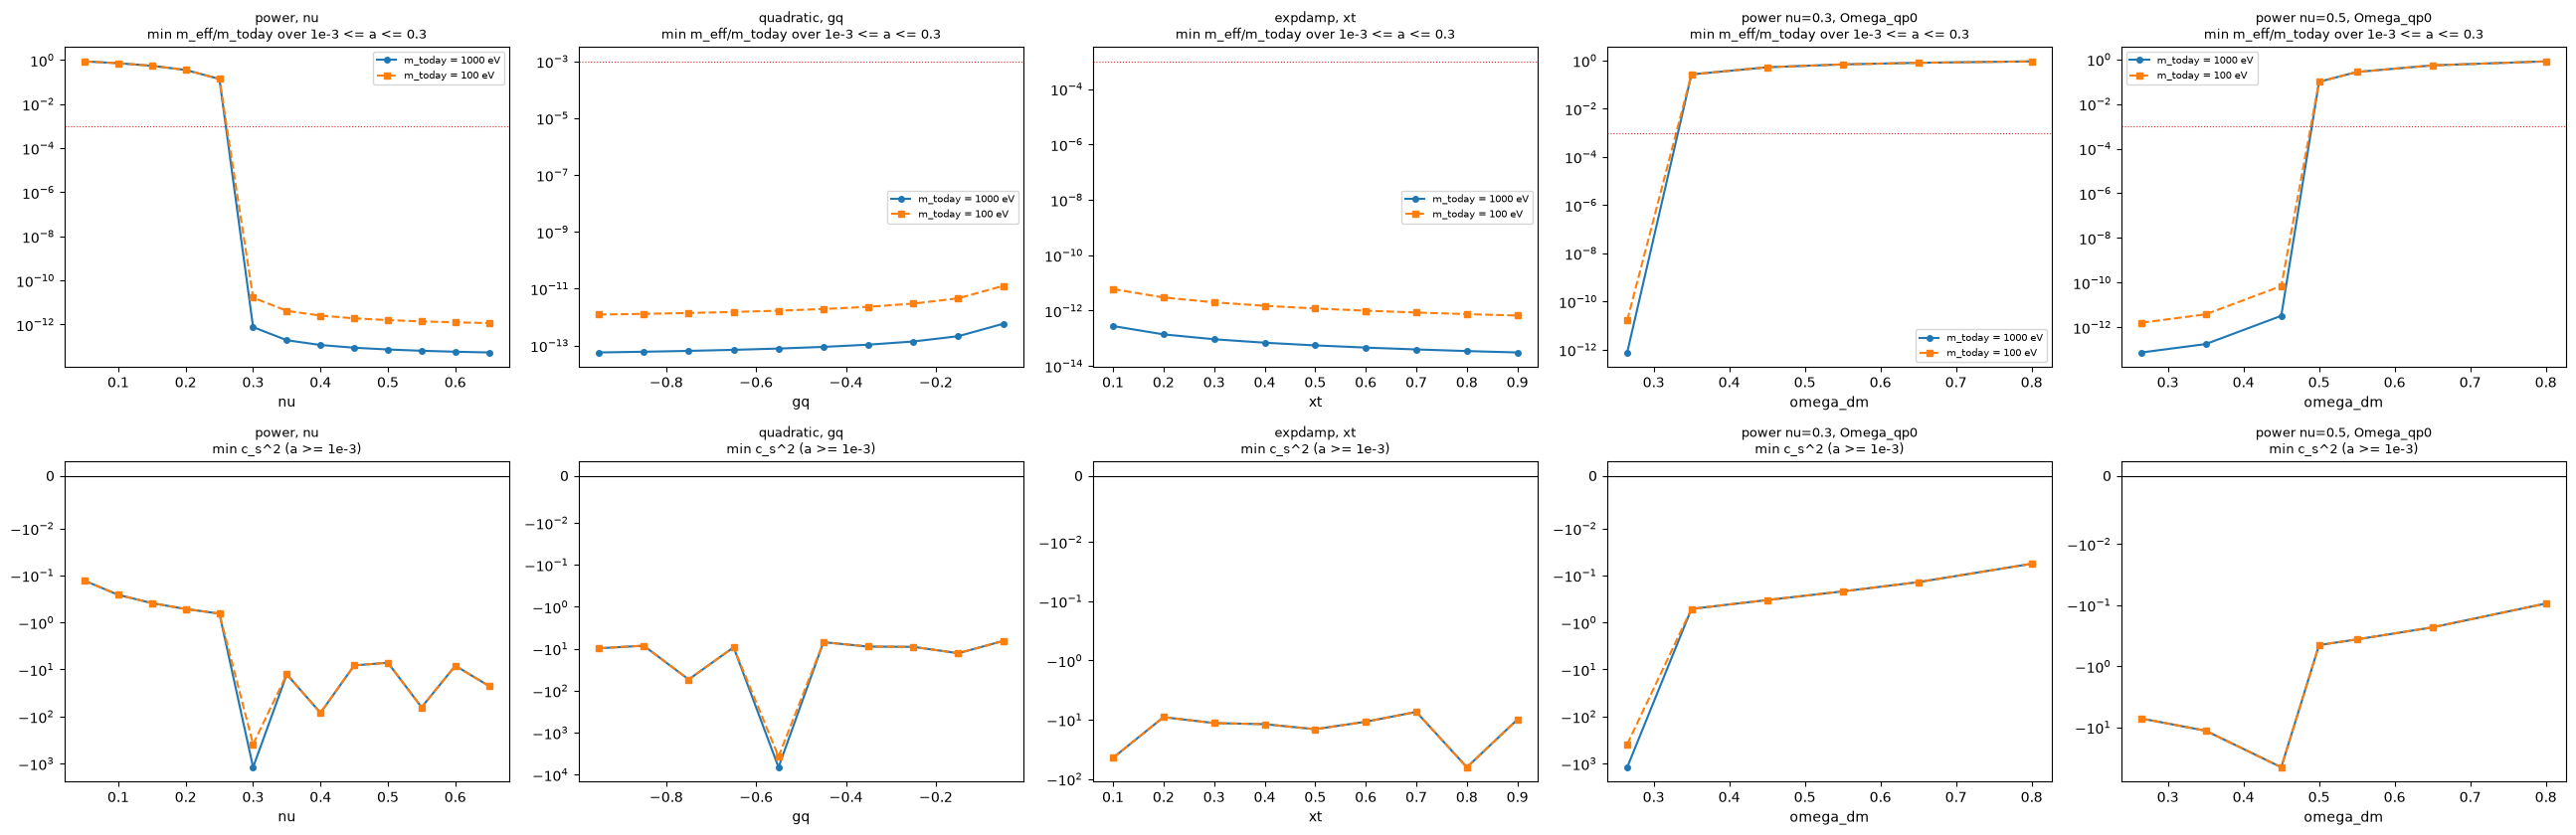

figure: results/nb06_scan_cpl.png


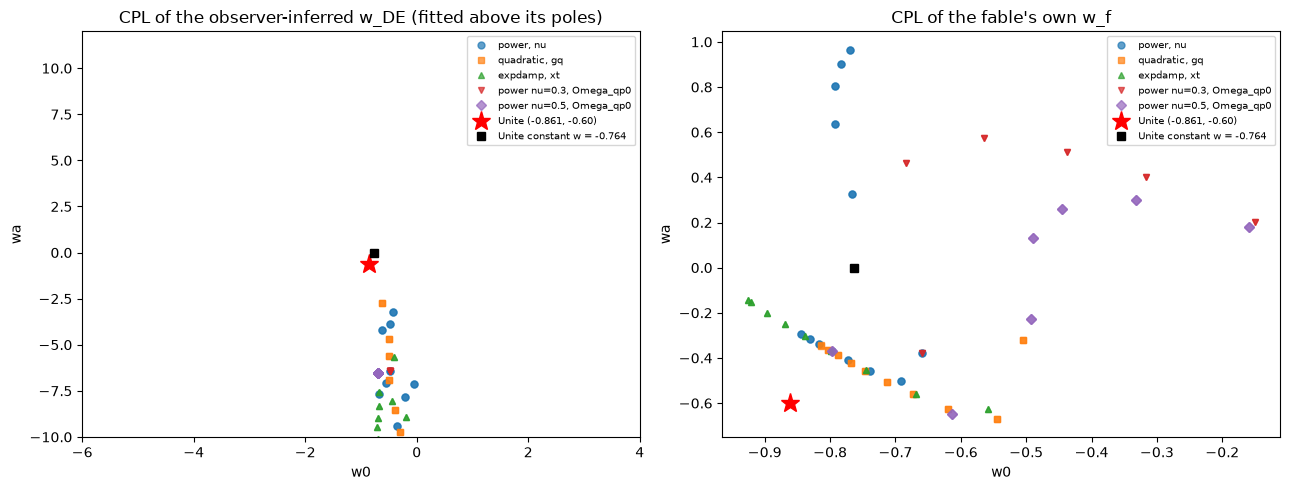

In [11]:
M_SCAN = 100
SCAN_FAMILIES = [('power, nu', 'power', 'nu', [round(0.05 * k, 2) for k in range(1, 14)], []),
                 ('quadratic, gq', 'quadratic', 'gq', [round(-0.95 + 0.1 * k, 2) for k in range(10)], []),
                 ('expdamp, xt', 'expdamp', 'xt', [round(0.1 * k, 1) for k in range(1, 10)], []),
                 ('power nu=0.3, Omega_qp0', 'power', 'omega_dm', [0.265, 0.35, 0.45, 0.55, 0.65, 0.8], ['nu=0.3']),
                 ('power nu=0.5, Omega_qp0', 'power', 'omega_dm', [0.265, 0.35, 0.45, 0.5, 0.55, 0.65, 0.8], ['nu=0.5'])]
try:
    SCAN
except NameError:
    SCAN = []
for fam, pot, key, vals, fixed in SCAN_FAMILIES:
    for v in vals:
        name = f"scan_{pot}_{key}{v}{'_' + '_'.join(fixed) if fixed else ''}_m{M_SCAN}"
        extra = [x for f_ in fixed for x in ('--param', f_)]
        r = run_fermion(name, 'fable4d', '--potential', pot, '--param', f'{key}={v}', *extra, '--param', f'm_today_ev={M_SCAN}', '--points', '401',
                        keep=False, quiet=True, show_log=False, label=f'{fam}={v}, {M_SCAN} eV')
        s = summarize(r)
        xr = xcheck(r, conservation=True, stride=20)
        cc, pp = r['cols'], r['params']
        SCAN.append(dict(family=fam, key=key, value=v, m_today_eV=M_SCAN, m0_over_m_today=pp['m0'] / cc['m_eff'][-1],
                         omega_qp0=float(cc['rho_qp'][-1]), U_today=float(cc['rho_U'][-1]), a_nr=s['a_nr'], m_ratio_min_matter=s['m_ratio_min_matter'],
                         w0_DE=s['cpl_wDEinf'][0], wa_DE=s['cpl_wDEinf'][1], fit_from_a=s['de']['amin'],
                         poles=' '.join(f'{x:.3g}' for x in s['de']['poles']), crossings=' '.join(f'{x:.3g}' for x in s['de']['cross']),
                         phantom_late=s['de']['phantom_late'], crosses_late=bool(s['de']['cross_late']), w0_f=s['cpl_wf'][0], wa_f=s['cpl_wf'][1],
                         w_f_min=s['w_f_min'], cs2_min=float(np.nanmin(np.where(r['cols']['a'] >= 1e-3, r['cols']['cs2_adiabatic'], np.nan))),
                         vac_ratio_late=s['vac_ratio_late'], gap_residual_max=s['gap_residual_max'], xcheck_worst=xr['worst'], conservation=xr['conservation']))
        assert xr['worst'] < 1e-6 and s['w_f_min'] >= -1 - 1e-12
rows = [r for r in SCAN if r['m_today_eV'] == M_SCAN]
print(f"m_today = {M_SCAN} eV: {len(rows)} scan runs")
print(f"{'family':24s} {'value':>6s} {'m0/m1':>9s} {'min m/m1':>9s} {'a_nr':>8s} {'CPL w_DE,inf':>18s} {'from a':>6s} {'poles':>18s} {'phantom':>7s} {'cross':>5s} {'min cs2':>9s} {'min w_f':>8s} {'max gap res':>11s} {'xcheck':>8s} {'cons.':>8s}")
for r in rows:
    print(f"{r['family']:24s} {r['value']:6.3f} {r['m0_over_m_today']:9.3g} {r['m_ratio_min_matter']:9.2e} {r['a_nr']:8.3g} ({r['w0_DE']:+7.3f}, {r['wa_DE']:+7.3f}) {r['fit_from_a']:6.3f} {r['poles']:>18s} "
          f"{str(r['phantom_late']):>7s} {str(r['crosses_late']):>5s} {r['cs2_min']:9.3g} {r['w_f_min']:8.4f} {r['gap_residual_max']:11.1e} {r['xcheck_worst']:8.1e} {r['conservation']:8.1e}")

massive = [r for r in SCAN if r['m_ratio_min_matter'] > 1e-3]
print(f"\nscan points whose fable stays massive through 1e-3 <= a <= 0.3 (min m/m_today > 1e-3): {len(massive)} of {len(SCAN)}: "
      + ', '.join(f"{r['family']}={r['value']} ({r['m_today_eV']} eV)" for r in massive))
print(f"of these, with c_s^2 >= 0 after a = 1e-3: {sum(1 for r in massive if r['cs2_min'] >= 0)};  "
      f"smallest c_s^2 among them: {min(r['cs2_min'] for r in massive):+.4f};  largest: {max(r['cs2_min'] for r in massive):+.4f}")
pw_scan = [r for r in SCAN if r['family'].startswith('power')]
agree = all((r['m0_over_m_today'] > 0) == (r['m_ratio_min_matter'] > 1e-3) for r in pw_scan)
print(f"power law: 'massive through the matter era' <=> 'bare m0 > 0' at all {len(pw_scan)} power scan points: {agree}")
assert agree
for r in SCAN:
    if r['family'].startswith('power'):
        nu_ = r['value'] if r['key'] == 'nu' else float(r['family'].split('nu=')[1].split(',')[0])
        r['criterion'] = r['omega_qp0'] / r['U_today'] - nu_ / (1 - nu_)          # > 0: massive (NR estimate today)
    else:
        r['criterion'] = float('nan')
mism = [r for r in pw_scan if (r['criterion'] > 0) != (r['m0_over_m_today'] > 0)]
nu_crit = OMEGA_DM / (1 - OMEGA_B0 - OMEGA_R0)
print(f"the estimate Omega_qp0/U_t > nu/(1 - nu) agrees with the sign of m0 at {len(pw_scan) - len(mism)} of {len(pw_scan)} points;  "
      f"with Omega_qp0 = {OMEGA_DM} it allows nu < Omega_qp0/(1 - Omega_b0 - Omega_r0) = {nu_crit:.4f}")
assert not mism
with open(RESULTS / 'nb06_scan.csv', 'w', newline='') as f:
    wr = csv.DictWriter(f, fieldnames=list(SCAN[0].keys())); wr.writeheader()
    wr.writerows([{k: (f'{v:.8g}' if isinstance(v, float) else v) for k, v in r.items()} for r in SCAN])
print('written: results/nb06_scan.csv')
fig, ax = plt.subplots(2, len(SCAN_FAMILIES), figsize=(5.2 * len(SCAN_FAMILIES), 8.5))
for j, (fam, pot, key, vals, fixed) in enumerate(SCAN_FAMILIES):
    for M_, mk in ((1000, 'o-'), (100, 's--')):
        rr = [r for r in SCAN if r['family'] == fam and r['m_today_eV'] == M_]
        ax[0, j].semilogy([r['value'] for r in rr], [max(r['m_ratio_min_matter'], 1e-16) for r in rr], mk, ms=4, label=f'm_today = {M_} eV')
        ax[1, j].plot([r['value'] for r in rr], [r['cs2_min'] for r in rr], mk, ms=4, label=f'm_today = {M_} eV')
    ax[0, j].axhline(1e-3, color='tab:red', lw=0.8, ls=':'); ax[0, j].set_title(f'{fam}\nmin m_eff/m_today over 1e-3 <= a <= 0.3', fontsize=9)
    ax[0, j].set_xlabel(key); ax[0, j].legend(fontsize=7)
    ax[1, j].set_yscale('symlog', linthresh=1e-2); ax[1, j].axhline(0, color='k', lw=0.8); ax[1, j].set_title(f'{fam}\nmin c_s^2 (a >= 1e-3)', fontsize=9); ax[1, j].set_xlabel(key)
fig.tight_layout(); fig.savefig(RESULTS / 'nb06_scan.png', dpi=130, bbox_inches='tight'); print('figure: results/nb06_scan.png'); plt.show()
fig, ax = plt.subplots(1, 2, figsize=(13, 5))
for (fam, pot, key, vals, fixed), mk in zip(SCAN_FAMILIES, ('o', 's', '^', 'v', 'D')):
    rr = [r for r in SCAN if r['family'] == fam]
    ax[0].plot([r['w0_DE'] for r in rr], [r['wa_DE'] for r in rr], mk, ms=5, alpha=0.7, label=fam)
    ax[1].plot([r['w0_f'] for r in rr], [r['wa_f'] for r in rr], mk, ms=5, alpha=0.7, label=fam)
for k in (0, 1):
    ax[k].plot(UNITE_W0, UNITE_WA, 'r*', ms=14, label='Unite (-0.861, -0.60)'); ax[k].plot(UNITE_WCONST, 0, 'ks', label='Unite constant w = -0.764')
    ax[k].set_xlabel('w0'); ax[k].set_ylabel('wa'); ax[k].legend(fontsize=7)
ax[0].set_xlim(-6, 4); ax[0].set_ylim(-10, 12); ax[0].set_title('CPL of the observer-inferred w_DE (fitted above its poles)')
ax[1].set_title('CPL of the fable\'s own w_f')
fig.tight_layout(); fig.savefig(RESULTS / 'nb06_scan_cpl.png', dpi=130, bbox_inches='tight'); print('figure: results/nb06_scan_cpl.png'); plt.show()

### 5.7 How heavy must a fable that is all of the dark matter be?  `ΔN_eff`, free streaming, phase space

**Extra radiation.**  Before `a_nr` the fable is radiation.  Its energy at nucleosynthesis in units of one
neutrino species, `ΔN_eff(BBN)`, depends only on `kF0`, which the requirement `ε_KS(m_today, kF0) = Ω_qp0`
fixes; for a non-relativistic gas today `kF0 ∝ m^{−1/3}`, so `ΔN_eff ∝ m^{−4/3}`.  The cell runs the four
dark-energy potentials at `m_today = 1 eV` (only to show that failure), collects `ΔN_eff(BBN)` from every
run with `Ω_qp0 = 0.265`, fits the power law, and solves for the mass above which `ΔN_eff < 0.3` (and `0.2`).

**Free streaming.**  A zero-temperature degenerate gas has the velocity dispersion of a uniformly filled
Fermi sphere, `v_rms = Sqrt[3/5] kF/m`.  For a fable that is all of the dark matter (`g = 8`,
`n0 = Ω_dm ρ_c0/m`, `kF0 = (6π² n0/g)^{1/3}`) the cell computes `v_rms0(m)` and compares it with the
`v_rms0` of the thermal-relic warm dark matter that the Lyman-α forest allows: `m_WDM ≳ 3.3 keV` (Viel,
Becker, Bolton & Haehnelt 2013, Phys. Rev. D 88, 043502) and `m_WDM ≳ 5.3 keV` (Iršič et al. 2017, Phys.
Rev. D 96, 023522), each a Fermi–Dirac relic with 2 states that is all of the dark matter:
`n = (3ζ(3)/(2π²)) T_x³`, `m n = Ω_dm ρ_c0`, `v_rms = Sqrt[15 ζ(5)/ζ(3)] T_x/m`.  Matching `v_rms0` gives the
fable mass whose free streaming equals that of the allowed WDM.  This is a velocity-matching estimate,
not a transfer-function computation.

**Phase space (Tremaine & Gunn 1979, Phys. Rev. Lett. 42, 407).**  The phase-space density of a
degenerate gas is `g/h³`, the largest a fermion can have, and coarse-graining can only lower it.  A dwarf
galaxy whose core is an isothermal sphere with velocity dispersion `σ` and core radius `r_c` has central
density `ρ0 = 9σ²/(4πG r_c²)` and maximal coarse-grained phase-space density `ρ0/(m⁴ (2πσ²)^{3/2})`, so
`m⁴ > 9 h³/(2 (2π)^{5/2} g G σ r_c²)`.  The cell evaluates it for `g = 8` with illustrative dwarf
spheroidal values `(σ, r_c) = (10 km/s, 0.3 kpc)` and `(7 km/s, 0.15 kpc)` (inputs, not results).

$ fable_fermion fable4d --potential power --param nu=0.236 --param m_today_ev=1 --points 1001 --out results/nb06_power_0.236_m1_4d.csv
  # stats: model=fable4d direction=Forward potential=power steps=397 rhs_evals=487 nonlin_iters=484 err_test_fails=18 jac_evals=7 wall=0.011s (summed over every CVODE integration of the run, shooting included)
$ fable_fermion fable4d --potential power --param nu=0.5 --param m_today_ev=1 --points 1001 --out results/nb06_power_0.5_m1_4d.csv


  # stats: model=fable4d direction=Forward potential=power steps=429 rhs_evals=553 nonlin_iters=550 err_test_fails=28 jac_evals=8 wall=0.019s (summed over every CVODE integration of the run, shooting included)
$ fable_fermion fable4d --potential expdamp --param xt=0.4524886877828054 --param m_today_ev=1 --points 1001 --out results/nb06_expdamp_m1_4d.csv
  # stats: model=fable4d direction=Forward potential=expdamp steps=428 rhs_evals=560 nonlin_iters=557 err_test_fails=32 jac_evals=8 wall=0.018s (summed over every CVODE integration of the run, shooting included)
$ fable_fermion fable4d --potential quadratic --param gq=-0.5 --param m_today_ev=1 --points 1001 --out results/nb06_quadratic_m1_4d.csv
  # stats: model=fable4d direction=Forward potential=quadratic steps=444 rhs_evals=576 nonlin_iters=573 err_test_fails=30 jac_evals=8 wall=0.011s (summed over every CVODE integration of the run, shooting included)
expdamp xt=1/2.21, 1 eV (Delta N_eff)    m_today =     1.0 eV   Delta N_eff(BBN) =

figure: results/nb06_dm_mass_bounds.png


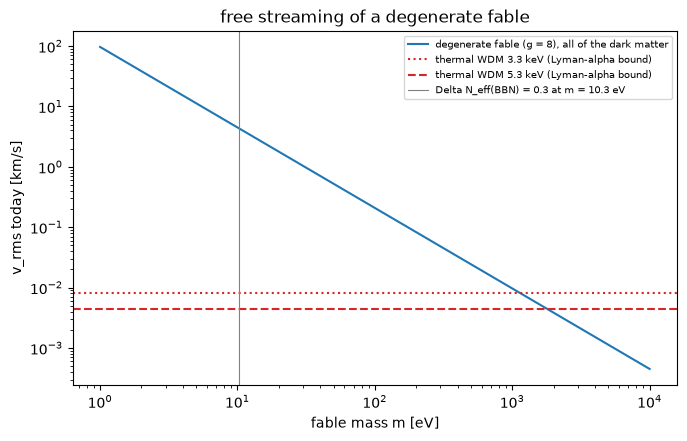

In [12]:
ONE_EV_RUNS = []
for pot, par, lab in DE_SPECS:
    name = f"nb06_{pot}{'_' + par.split('=')[1] if pot == 'power' else ''}_m1_4d"
    run_fermion(name, 'fable4d', '--potential', pot, '--param', par, '--param', 'm_today_ev=1', '--points', str(POINTS), label=f'{lab}, 1 eV (Delta N_eff)', quiet=True)
    ONE_EV_RUNS.append(name)
    SUM[name] = summarize(RUNS[name])
pts = [(SUM[n]['m_today_eV'], SUM[n]['Neff_BBN'], SUM[n]['label']) for n in LM_RUNS + DE_RUNS + ONE_EV_RUNS
       if abs(RUNS[n]['cols']['rho_qp'][-1] - OMEGA_DM) < 1e-9]          # the runs whose quasiparticles carry Omega_qp0 = 0.265
for mm_, ne, lab in sorted(pts):
    print(f'{lab:40s} m_today = {mm_:7.1f} eV   Delta N_eff(BBN) = {ne:.6g}')
lm_ = np.log([p[0] for p in pts]); ln_ = np.log([p[1] for p in pts])
slope, icpt = np.polyfit(lm_, ln_, 1)
resid = np.max(np.abs(ln_ - (slope * lm_ + icpt)))
coef = math.exp(icpt)
m_03, m_02 = (coef / 0.3) ** (-1 / slope), (coef / 0.2) ** (-1 / slope)
print(f'\nfit over {len(pts)} runs: Delta N_eff(BBN) = {coef:.4f} (m/eV)^({slope:.5f})   (max |ln residual| = {resid:.1e});  '
      f'Delta N_eff < 0.3 needs m > {m_03:.2f} eV, < 0.2 needs m > {m_02:.2f} eV')
assert abs(slope + 4 / 3) < 1e-3 and all(SUM[n]['Neff_BBN'] > 0.3 for n in ONE_EV_RUNS)


def v_rms_fable(m_eV, g=G_FABLE):
    """sqrt(3/5) kF0/m (in km/s) for a degenerate fable that is all of the dark matter today."""
    m = m_eV / E_C_EV
    kf0 = (6 * PI2 * (OMEGA_DM / m) / g) ** (1 / 3)
    return math.sqrt(0.6) * kf0 / m * C_KMS


def v_rms_thermal(m_eV):
    """sqrt(15 zeta(5)/zeta(3)) T_x/m (km/s) for a thermal Fermi-Dirac relic with 2 states that is all of the dark matter."""
    m = m_eV / E_C_EV
    Tx = (OMEGA_DM / m * 2 * PI2 / (3 * zeta(3))) ** (1 / 3)
    return math.sqrt(15 * zeta(5) / zeta(3)) * Tx / m * C_KMS


for n in LM_RUNS:                           # the formula against the runs (eps(m, kF0) = 0.265 exactly there)
    c, p = RUNS[n]['cols'], RUNS[n]['params']
    v_run = math.sqrt(0.6) * p['kf0'] / c['m_eff'][-1] * C_KMS
    print(f"{RUNS[n]['label']:22s} v_rms0 from the run's kF0: {v_run:.6e} km/s;  formula: {v_rms_fable(SUM[n]['m_today_eV']):.6e} km/s")
    assert abs(v_run / v_rms_fable(SUM[n]['m_today_eV']) - 1) < 1e-4
bounds = []
for mw, ref in ((3300.0, 'Viel et al. 2013: m_WDM > 3.3 keV'), (5300.0, 'Irsic et al. 2017: m_WDM > 5.3 keV')):
    vt = v_rms_thermal(mw)
    mf = math.exp(brentq(lambda lm: math.log(v_rms_fable(math.exp(lm)) / vt), math.log(1.0), math.log(1e6)))
    bounds.append(dict(bound=f'free streaming, v_rms0 matched to thermal WDM of {mw / 1e3:g} keV ({ref})', value_eV=mf, detail=f'v_rms0 = {vt:.4e} km/s'))
    print(f'thermal WDM {mw / 1e3:g} keV: v_rms0 = {vt:.4e} km/s  ->  degenerate fable (g = 8) with the same v_rms0: m = {mf:.1f} eV')
for m_ in (10.0, 15.0, 100.0, 1000.0, 2000.0):
    print(f'   fable m = {m_:6.0f} eV: v_rms0 = {v_rms_fable(m_):.4e} km/s')
hP, Gsi, kpc, eVJ = 6.62607015e-34, 6.67430e-11, 3.0856775814913673e19, 1.602176634e-19
for sig_kms, rc_kpc in ((10.0, 0.3), (7.0, 0.15)):
    m4 = 9 * hP ** 3 / (2 * (2 * math.pi) ** 2.5 * G_FABLE * Gsi * sig_kms * 1e3 * (rc_kpc * kpc) ** 2)
    m_tg = m4 ** 0.25 * 299792458.0 ** 2 / eVJ
    bounds.append(dict(bound=f'Tremaine-Gunn, g = 8, sigma = {sig_kms:g} km/s, r_c = {rc_kpc:g} kpc', value_eV=m_tg, detail='m^4 > 9 h^3/(2 (2 pi)^(5/2) g G sigma r_c^2)'))
    print(f'Tremaine-Gunn (g = 8, sigma = {sig_kms:g} km/s, r_c = {rc_kpc:g} kpc): m > {m_tg:.1f} eV')
bounds = [dict(bound='Delta N_eff(BBN) < 0.3', value_eV=m_03, detail=f'Delta N_eff = {coef:.4f} (m/eV)^({slope:.4f})'),
          dict(bound='Delta N_eff(BBN) < 0.2', value_eV=m_02, detail='same fit')] + bounds
with open(RESULTS / 'nb06_dm_mass_bounds.csv', 'w', newline='') as f:
    wr = csv.DictWriter(f, fieldnames=['bound', 'value_eV', 'detail']); wr.writeheader()
    wr.writerows([{**b, 'value_eV': f"{b['value_eV']:.6g}"} for b in bounds])
print('written: results/nb06_dm_mass_bounds.csv')
fig, ax = plt.subplots(figsize=(7.8, 4.6))
mgr = np.geomspace(1, 1e4, 200)
ax.loglog(mgr, [v_rms_fable(x) for x in mgr], label='degenerate fable (g = 8), all of the dark matter')
for mw, ls in ((3300.0, ':'), (5300.0, '--')):
    ax.axhline(v_rms_thermal(mw), color='tab:red', ls=ls, label=f'thermal WDM {mw / 1e3:g} keV (Lyman-alpha bound)')
ax.axvline(m_03, color='0.5', lw=0.8, label=f'Delta N_eff(BBN) = 0.3 at m = {m_03:.1f} eV')
ax.set_xlabel('fable mass m [eV]'); ax.set_ylabel('v_rms today [km/s]'); ax.legend(fontsize=7); ax.set_title('free streaming of a degenerate fable')
fig.savefig(RESULTS / 'nb06_dm_mass_bounds.png', dpi=130, bbox_inches='tight'); print('figure: results/nb06_dm_mass_bounds.png'); plt.show()

### 5.8 (d) Without the stabilizer: the hidden sheet moves and the Newton constant varies

`fable8d` for representative cases of (a) and (b): the mass term at `1` and `100 eV`, `lambda-mass` at
`30 eV` and `1 keV`; and two controls, radiation alone (`--no-fable --omega-b 0`), which must keep the
hidden sheet exactly frozen (`F = 0`), and radiation plus baryons (`--no-fable`), in which dust alone
drives it.  For each: `B` and `C` at `a_i` (both are 1 today), `G(a)/G(1) = 1/v` at `a_i` and at
`a_BBN`, `ΔG/G` since nucleosynthesis, `|d ln G/dt|` today in units of 1/yr against the lunar-laser-ranging
bound `1e−13/yr`, `H_B/H_A` and `H_C/H_A` today (the approach to the 7-dimensional isotropic attractor,
where both are 1), the largest constraint residual, and `Ω_sum` today (the budget the closure needs).
The two controls have nothing to shoot, so their `H_A` today is not 1 and their ages are not those of our
universe; they only show what drives the hidden sheet.  The last run is `fable8d --freeze-hidden` for
`lambda-mass 30 eV`: `fable4d` with `H_A` evolved by its own equation, which must agree with the algebraic
`fable4d`.

$ fable_fermion fable8d --potential mass --param m0_ev=1 --points 1001 --out results/nb06_mass_m1_8d.csv
  # stats: model=fable8d direction=Forward potential=mass steps=37019 rhs_evals=41186 nonlin_iters=41081 err_test_fails=499 jac_evals=634 wall=0.039s (summed over every CVODE integration of the run, shooting included)
$ fable_fermion fable8d --potential mass --param m0_ev=100 --points 1001 --out results/nb06_mass_m100_8d.csv


  # stats: model=fable8d direction=Forward potential=mass steps=40808 rhs_evals=45860 nonlin_iters=45758 err_test_fails=474 jac_evals=702 wall=0.042s (summed over every CVODE integration of the run, shooting included)
$ fable_fermion fable8d --potential lambda-mass --param m0_ev=30 --points 1001 --out results/nb06_lm_m30_8d.csv
  # stats: model=fable8d direction=Forward potential=lambda-mass steps=37544 rhs_evals=42447 nonlin_iters=42339 err_test_fails=654 jac_evals=647 wall=0.039s (summed over every CVODE integration of the run, shooting included)


$ fable_fermion fable8d --potential lambda-mass --param m0_ev=1000 --points 1001 --out results/nb06_lm_m1000_8d.csv
  # stats: model=fable8d direction=Forward potential=lambda-mass steps=38558 rhs_evals=42762 nonlin_iters=42657 err_test_fails=595 jac_evals=669 wall=0.040s (summed over every CVODE integration of the run, shooting included)
$ fable_fermion fable8d --no-fable --omega-b 0 --points 1001 --out results/nb06_radiation_only_8d.csv
  # stats: model=fable8d direction=Forward potential=none steps=7 rhs_evals=13 nonlin_iters=7 err_test_fails=0 jac_evals=2 wall=0.008s (summed over every CVODE integration of the run, shooting included)
$ fable_fermion fable8d --no-fable --points 1001 --out results/nb06_radiation_baryons_8d.csv
  # stats: model=fable8d direction=Forward potential=none steps=2109 rhs_evals=2379 nonlin_iters=2370 err_test_fails=37 jac_evals=38 wall=0.010s (summed over every CVODE integration of the run, shooting included)



run                              B(a_i)     C(a_i)  G(a_i)/G(1)  G(BBN)/G(1) dG/G since BBN |dlnG/dt| /yr > 1e-13?  H_B/H_A(1)  H_C/H_A(1) max|constr| Omega_sum(1)      q0  t0 Gyr
mass 1 eV, fable8d           2.3224e-03 2.3224e-03   3.4376e+10   3.4376e+10    -1.0000e+00    2.7571e-10     True    0.999959    0.999959    1.16e-08      6.99967  2.5000   4.145
mass 100 eV, fable8d         4.8207e-05 4.8207e-05   1.8516e+17   1.8516e+17    -1.0000e+00    2.7571e-10     True    0.999963    0.999963    2.12e-08      6.99971  2.5000   4.145
lambda-mass 30 eV, fable8d   9.8881e-04 9.8881e-04   1.0461e+12   1.0461e+12    -1.0000e+00    2.7570e-10     True    0.999902    0.999902    2.47e-08      6.99922 -0.8425   9.472
lambda-mass 1 keV, fable8d   9.8389e-04 9.8389e-04   1.0671e+12   1.0671e+12    -1.0000e+00    2.7570e-10     True    0.999902    0.999902    2.07e-08      6.99922 -0.8425   9.472
radiation only, fable8d      1.0000e+00 1.0000e+00   1.0000e+00   1.0000e+00     0.0000e+00    0.00

figure: results/nb06_d_nogo_8d.png


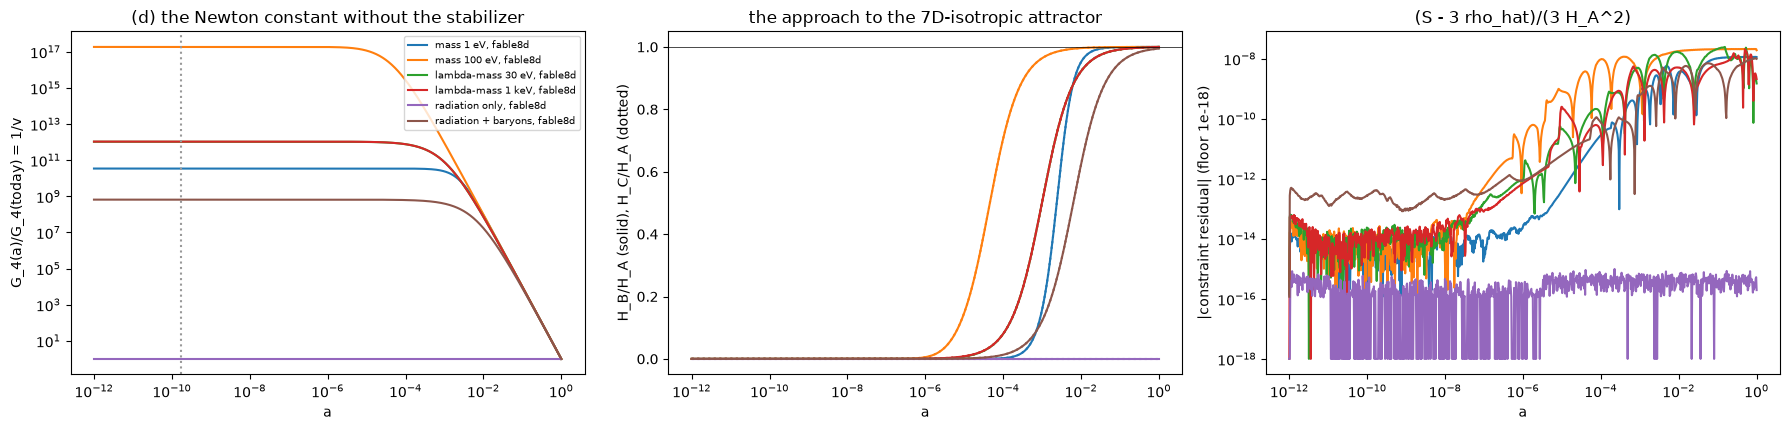

In [13]:
NOGO_RUNS = []
for name, args, lab in [('nb06_mass_m1_8d', ['--potential', 'mass', '--param', 'm0_ev=1'], 'mass 1 eV, fable8d'),
                        ('nb06_mass_m100_8d', ['--potential', 'mass', '--param', 'm0_ev=100'], 'mass 100 eV, fable8d'),
                        ('nb06_lm_m30_8d', ['--potential', 'lambda-mass', '--param', 'm0_ev=30'], 'lambda-mass 30 eV, fable8d'),
                        ('nb06_lm_m1000_8d', ['--potential', 'lambda-mass', '--param', 'm0_ev=1000'], 'lambda-mass 1 keV, fable8d'),
                        ('nb06_radiation_only_8d', ['--no-fable', '--omega-b', '0'], 'radiation only, fable8d'),
                        ('nb06_radiation_baryons_8d', ['--no-fable'], 'radiation + baryons, fable8d')]:
    run_fermion(name, 'fable8d', *args, '--points', str(POINTS), label=lab, quiet=True)
    NOGO_RUNS.append(name)
    SUM[name] = summarize(RUNS[name])
print(f"\n{'run':28s} {'B(a_i)':>10s} {'C(a_i)':>10s} {'G(a_i)/G(1)':>12s} {'G(BBN)/G(1)':>12s} {'dG/G since BBN':>14s} {'|dlnG/dt| /yr':>13s} {'> 1e-13?':>8s} {'H_B/H_A(1)':>11s} {'H_C/H_A(1)':>11s} {'max|constr|':>11s} {'Omega_sum(1)':>12s} {'q0':>7s} {'t0 Gyr':>7s}")
for n in NOGO_RUNS:
    s, c = SUM[n], RUNS[n]['cols']
    print(f"{s['label']:28s} {c['B'][0]:10.4e} {c['C'][0]:10.4e} {s['G_ai_over_G1']:12.4e} {s['G_BBN_over_G1']:12.4e} {s['dG_since_BBN']:14.4e} {s['Gdot_today_per_yr']:13.4e} "
          f"{str(s['Gdot_today_per_yr'] > LLR_BOUND_PER_YR):>8s} {s['HB_over_HA_today']:11.6f} {s['HC_over_HA_today']:11.6f} {s['constraint_max']:11.2e} {s['Omega_sum0']:12.5f} {s['q0']:7.4f} {s['t0_Gyr']:7.3f}")
rad = RUNS['nb06_radiation_only_8d']['cols']
print(f"\nradiation only: max |H_B/H_A| = {np.max(np.abs(rad['H_B'] / rad['H_A'])):.1e}, max |H_C/H_A| = {np.max(np.abs(rad['H_C'] / rad['H_A'])):.1e} (F = 0: the hidden sheet stays frozen)")
assert np.max(np.abs(rad['H_B'] / rad['H_A'])) < 1e-12 and np.max(np.abs(rad['H_C'] / rad['H_A'])) < 1e-12
for n in NOGO_RUNS[:4] + NOGO_RUNS[5:]:
    assert SUM[n]['Gdot_today_per_yr'] > LLR_BOUND_PER_YR and SUM[n]['constraint_max'] < 1e-6
fr = run_fermion('nb06_lm_m30_8d_frozen', 'fable8d', '--potential', 'lambda-mass', '--param', 'm0_ev=30', '--freeze-hidden', '--points', str(POINTS), keep=False, quiet=True,
                 label='lambda-mass 30 eV, fable8d --freeze-hidden')
c4, c8 = RUNS['nb06_lm_m30_4d']['cols'], fr['cols']
dH, dt_, dw_ = np.max(np.abs(c8['H_A'] / c4['H_A'] - 1)), np.max(np.abs(c8['t'] / c4['t'] - 1)), np.max(np.abs(c8['w_f'] - c4['w_f']))
print(f'fable8d --freeze-hidden versus fable4d (lambda-mass 30 eV): max |dH_A|/H_A = {dH:.1e}, max |dt|/t = {dt_:.1e}, max |dw_f| = {dw_:.1e}, max |H_B| = {np.max(np.abs(c8["H_B"])):.1e}')
assert dH < 1e-7 and dt_ < 1e-7 and dw_ < 1e-9
with open(RESULTS / 'nb06_nogo_8d.csv', 'w', newline='') as f:
    keys = ['label', 'G_ai_over_G1', 'G_BBN_over_G1', 'dG_since_BBN', 'Gdot_today_per_yr', 'HB_over_HA_today', 'HC_over_HA_today', 'constraint_max', 'Omega_sum0', 'q0', 't0_Gyr']
    wr = csv.writer(f); wr.writerow(keys + ['B_ai', 'C_ai'])
    for n in NOGO_RUNS:
        wr.writerow([SUM[n][k] if isinstance(SUM[n][k], str) else f'{SUM[n][k]:.8g}' for k in keys] + [f"{RUNS[n]['cols']['B'][0]:.8g}", f"{RUNS[n]['cols']['C'][0]:.8g}"])
print('written: results/nb06_nogo_8d.csv')
fig, ax = plt.subplots(1, 3, figsize=(18, 4.4))
for n in NOGO_RUNS:
    c = RUNS[n]['cols']
    l, = ax[0].loglog(c['a'], c['G_ratio'], label=RUNS[n]['label'])
    ax[1].semilogx(c['a'], c['H_B'] / c['H_A'], color=l.get_color(), label=RUNS[n]['label'] + ': H_B/H_A')
    ax[1].semilogx(c['a'], c['H_C'] / c['H_A'], ':', color=l.get_color())
    ax[2].loglog(c['a'], np.maximum(np.abs(c['constraint_residual']), 1e-18), color=l.get_color())
ax[0].axvline(A_BBN, color='0.6', ls=':'); ax[0].set_xlabel('a'); ax[0].set_ylabel('G_4(a)/G_4(today) = 1/v'); ax[0].legend(fontsize=7); ax[0].set_title('(d) the Newton constant without the stabilizer')
ax[1].axhline(1, color='k', lw=0.5); ax[1].set_xlabel('a'); ax[1].set_ylabel('H_B/H_A (solid), H_C/H_A (dotted)'); ax[1].set_title('the approach to the 7D-isotropic attractor')
ax[2].set_xlabel('a'); ax[2].set_ylabel('|constraint residual| (floor 1e-18)'); ax[2].set_title('(S - 3 rho_hat)/(3 H_A^2)')
fig.tight_layout(); fig.savefig(RESULTS / 'nb06_d_nogo_8d.png', dpi=130, bbox_inches='tight'); print('figure: results/nb06_d_nogo_8d.png'); plt.show()

### 5.9 The cases the solver refuses, and why

Three runs are expected to fail, each with a one-line physical reason: `lorentz` (Part VI's `xt = 1/1.5`,
`m_today = 1 eV`), whose Kohn–Sham ground state moves to the negative-`σ` branch and has negative total
energy density, so `H_A² = ρ̂` is impossible; the repulsive `quadratic` (`gq = +0.5`), whose ground state
jumps between gap branches (a first-order transition: energy conservation would need a Maxwell
construction, which the solver does not implement); and `fable8d` backward in time, which runs away to
the 8-dimensional Kasner point.  The cell checks the exit code (1) and prints each reason.

In [14]:
REFUSED = []
for args, why in [(['fable4d', '--potential', 'lorentz', '--points', str(POINTS)], 'negative-energy ground state'),
                  (['fable4d', '--potential', 'quadratic', '--param', 'gq=0.5', '--points', str(POINTS)], 'first-order transition'),
                  (['fable8d', '--potential', 'mass', '--direction', 'backward'], 'fable8d backward')]:
    r = run_fermion('refused', *args, keep=False, expect_failure=True)
    reason = [l for l in r.stderr.splitlines() if l.startswith('fable_fermion:')][-1]
    REFUSED.append((why, r.returncode, reason))
    assert r.returncode == 1
for key, (why, code_, reason) in zip(('negative energy', 'first-order transition', 'forward only'), REFUSED):
    assert key in reason, reason
print('all three refused with exit code 1 and the expected reason')

$ fable_fermion fable4d --potential lorentz --points 1001
  exit code 1: fable_fermion: rho_hat = H_A^2 <= 0 from N = -0.7597808064 (a = 0.4677689478) on: the Kohn-Sham ground state has negative energy there (m_eff = -3.802078e-2, sigma8 = -9.789374e-4, rho_f = -4.830421e-1 (U = -4.847891e-1) against rho_r + rho_b = 4.830421e-1); H_A^2 = rho_hat is impossible (the onset located past the last accepted CVODE step and bisected)
$ fable_fermion fable4d --potential quadratic --param gq=0.5 --points 1001
  exit code 1: fable_fermion: gap-branch jump at N = -0.0037262796 (a = 0.9962806544): a first-order transition of the Kohn-Sham ground state, the lowest-energy gap root jumps from the branch m_eff = -1.518260e0 (rho_f = 6.856759e-1) to the branch m_eff = 4.083552e2 (rho_f = 9.536521e-1); the right-hand side is discontinuous there, and energy conservation across it would need the Maxwell construction, which this solver does not implement (the transition detected inside the right-hand side an

### 5.10 Cross-check: every run re-computed with the independent scipy implementation

`xcheck` takes the solver's normalized parameters from the `# params:` line of each CSV and re-computes
the run with `fermion/crosscheck.py`: every Fermi-sea integral by adaptive quadrature, every gap root by
`brentq`, `fable8d` by DOP853 at `rtol = 1e−11`, `fable4d` algebraically with `t(A = 1)` by adaptive
quadrature.  It reports the largest differences of `w_f`, `H_A`, `B`, `G`, `ρ_f`, `P_obs`, `m_eff` and
`t(A = 1)`, the Friedmann consistency of the solver's own columns, and the covariant conservation of the
independently computed fluid on every tenth row (central differences with steps `1e−3` and `2e−3` in `N`,
Richardson-extrapolated so that their `O(h²)` truncation cancels) — which also
tests the massless phases of the dark-energy runs, where the gap is solved at the edge of double
precision.  The notebook fails if any difference exceeds `1e−6`.  The table goes to
`results/nb06_crosscheck.csv`; the scan runs of 5.5 were checked the same way as they ran.

In [15]:
KEPT = MASS_RUNS + LM_RUNS + DE_RUNS + ONE_EV_RUNS + NOGO_RUNS
for n in KEPT:
    print_xcheck(xcheck(RUNS[n]))
worst = max(XCHECK[n]['worst'] for n in KEPT)
worst_scan = max(r['xcheck_worst'] for r in SCAN)
cons = max(XCHECK[n]['conservation'] for n in KEPT + [k for k in XCHECK if k.startswith('scan_')])
print(f'\nlargest difference over the {len(KEPT)} kept runs: {worst:.2e};  over the {len(SCAN)} scan runs: {worst_scan:.2e};  '
      f'largest conservation residual of the independent fluid: {cons:.2e}')
assert worst < 1e-6 and worst_scan < 1e-6 and cons < 1e-6
with open(RESULTS / 'nb06_crosscheck.csv', 'w', newline='') as f:
    keys = ['name', 'dw', 'dH', 'dB', 'dG', 'drho', 'dP', 'dm', 'dt', 'friedmann', 'conservation']      # no wall times: the file is reproducible
    wr = csv.writer(f); wr.writerow(keys)
    for n in KEPT + sorted(k for k in XCHECK if k.startswith('scan_')):
        wr.writerow([XCHECK[n]['name']] + [f'{XCHECK[n][k]:.3e}' for k in keys[1:]])
print('written: results/nb06_crosscheck.csv')

  nb06_mass_m1_4d                    |dw_f| 1.2e-12  |dH|/H 5.9e-13  |dB|/B 0.0e+00  |dG|/G 0.0e+00  |drho|/rho 1.4e-12  |dP|/rho 1.3e-12  |dm|/m0 9.8e-16  |dt0|/t0 6.2e-10  Friedmann 1.2e-14  conservation 9.5e-12  (0.1 s)
  nb06_mass_m30_4d                   |dw_f| 1.2e-12  |dH|/H 1.2e-13  |dB|/B 0.0e+00  |dG|/G 0.0e+00  |drho|/rho 1.4e-12  |dP|/rho 1.2e-12  |dm|/m0 1.5e-15  |dt0|/t0 1.5e-09  Friedmann 1.3e-14  conservation 9.5e-12  (0.1 s)
  nb06_mass_m100_4d                  |dw_f| 1.2e-12  |dH|/H 1.0e-13  |dB|/B 0.0e+00  |dG|/G 0.0e+00  |drho|/rho 1.4e-12  |dP|/rho 1.2e-12  |dm|/m0 1.1e-15  |dt0|/t0 1.1e-09  Friedmann 1.3e-14  conservation 9.4e-12  (0.1 s)


  nb06_mass_m1000_4d                 |dw_f| 1.2e-12  |dH|/H 1.0e-13  |dB|/B 0.0e+00  |dG|/G 0.0e+00  |drho|/rho 1.4e-12  |dP|/rho 1.2e-12  |dm|/m0 1.0e-15  |dt0|/t0 7.2e-10  Friedmann 1.3e-14  conservation 6.9e-12  (0.1 s)
  nb06_mass_m2000_4d                 |dw_f| 1.2e-12  |dH|/H 1.0e-13  |dB|/B 0.0e+00  |dG|/G 0.0e+00  |drho|/rho 1.4e-12  |dP|/rho 1.2e-12  |dm|/m0 1.4e-16  |dt0|/t0 1.7e-09  Friedmann 1.2e-14  conservation 7.0e-12  (0.1 s)
  nb06_lm_m30_4d                     |dw_f| 1.2e-12  |dH|/H 1.0e-13  |dB|/B 0.0e+00  |dG|/G 0.0e+00  |drho|/rho 1.4e-12  |dP|/rho 1.1e-12  |dm|/m0 1.5e-15  |dt0|/t0 1.1e-09  Friedmann 1.2e-14  conservation 9.5e-12  (0.1 s)


  nb06_lm_m100_4d                    |dw_f| 1.2e-12  |dH|/H 1.0e-13  |dB|/B 0.0e+00  |dG|/G 0.0e+00  |drho|/rho 1.4e-12  |dP|/rho 1.2e-12  |dm|/m0 1.1e-15  |dt0|/t0 9.8e-10  Friedmann 1.3e-14  conservation 9.4e-12  (0.1 s)
  nb06_lm_m1000_4d                   |dw_f| 1.2e-12  |dH|/H 1.0e-13  |dB|/B 0.0e+00  |dG|/G 0.0e+00  |drho|/rho 1.4e-12  |dP|/rho 1.2e-12  |dm|/m0 1.0e-15  |dt0|/t0 8.4e-10  Friedmann 1.3e-14  conservation 6.9e-12  (0.1 s)
  nb06_lm_m2000_4d                   |dw_f| 1.2e-12  |dH|/H 1.0e-13  |dB|/B 0.0e+00  |dG|/G 0.0e+00  |drho|/rho 1.4e-12  |dP|/rho 1.1e-12  |dm|/m0 1.4e-16  |dt0|/t0 9.4e-10  Friedmann 1.2e-14  conservation 7.1e-12  (0.1 s)
  nb06_fable4d_mass30eV              |dw_f| 1.2e-12  |dH|/H 1.0e-13  |dB|/B 0.0e+00  |dG|/G 0.0e+00  |drho|/rho 1.4e-12  |dP|/rho 1.2e-12  |dm|/m0 1.5e-15  |dt0|/t0 1.2e-09  Friedmann 1.2e-14  conservation 9.4e-12  (0.1 s)


  nb06_power_0.236_m30_4d            |dw_f| 1.3e-12  |dH|/H 1.0e-13  |dB|/B 0.0e+00  |dG|/G 0.0e+00  |drho|/rho 1.4e-12  |dP|/rho 1.2e-12  |dm|/m0 4.5e-15  |dt0|/t0 2.8e-09  Friedmann 1.2e-14  conservation 9.5e-12  (0.3 s)
  nb06_power_0.236_m100_4d           |dw_f| 1.2e-12  |dH|/H 1.0e-13  |dB|/B 0.0e+00  |dG|/G 0.0e+00  |drho|/rho 1.4e-12  |dP|/rho 1.1e-12  |dm|/m0 1.6e-15  |dt0|/t0 1.2e-09  Friedmann 1.2e-14  conservation 9.4e-12  (0.2 s)


  nb06_power_0.5_m30_4d              |dw_f| 5.9e-15  |dH|/H 1.0e-13  |dB|/B 0.0e+00  |dG|/G 0.0e+00  |drho|/rho 2.0e-13  |dP|/rho 6.7e-14  |dm|/m0 1.5e-15  |dt0|/t0 1.9e-09  Friedmann 1.1e-14  conservation 8.5e-10  (3.2 s)


...

  nb06_power_0.5_m1_4d               |dw_f| 8.8e-14  |dH|/H 1.0e-13  |dB|/B 0.0e+00  |dG|/G 0.0e+00  |drho|/rho 2.0e-13  |dP|/rho 1.2e-13  |dm|/m0 1.7e-15  |dt0|/t0 1.8e-09  Friedmann 1.1e-14  conservation 6.7e-11  (3.0 s)


  nb06_expdamp_m1_4d                 |dw_f| 7.5e-14  |dH|/H 1.0e-13  |dB|/B 0.0e+00  |dG|/G 0.0e+00  |drho|/rho 2.0e-13  |dP|/rho 9.6e-14  |dm|/m0 1.4e-15  |dt0|/t0 5.5e-10  Friedmann 1.3e-14  conservation 5.3e-08  (2.7 s)


  nb06_quadratic_m1_4d               |dw_f| 9.6e-14  |dH|/H 1.0e-13  |dB|/B 0.0e+00  |dG|/G 0.0e+00  |drho|/rho 2.0e-13  |dP|/rho 1.2e-13  |dm|/m0 1.5e-15  |dt0|/t0 1.0e-09  Friedmann 1.2e-14  conservation 1.5e-10  (0.4 s)
  nb06_mass_m1_8d                    |dw_f| 1.2e-12  |dH|/H 2.5e-09  |dB|/B 8.4e-10  |dG|/G 3.3e-09  |drho|/rho 3.3e-09  |dP|/rho 1.9e-10  |dm|/m0 9.8e-16  |dt0|/t0 6.0e-10  Friedmann 1.2e-08  conservation 1.9e-10  (0.2 s)


  nb06_mass_m100_8d                  |dw_f| 1.2e-12  |dH|/H 5.1e-09  |dB|/B 1.8e-09  |dG|/G 7.1e-09  |drho|/rho 7.1e-09  |dP|/rho 2.8e-11  |dm|/m0 1.1e-15  |dt0|/t0 1.8e-09  Friedmann 2.1e-08  conservation 1.9e-10  (0.2 s)
  nb06_lm_m30_8d                     |dw_f| 2.7e-09  |dH|/H 7.1e-09  |dB|/B 2.7e-09  |dG|/G 1.1e-08  |drho|/rho 1.1e-08  |dP|/rho 6.5e-12  |dm|/m0 1.5e-15  |dt0|/t0 2.9e-09  Friedmann 2.5e-08  conservation 1.9e-10  (0.2 s)


  nb06_lm_m1000_8d                   |dw_f| 2.6e-10  |dH|/H 2.4e-09  |dB|/B 9.4e-10  |dG|/G 3.8e-09  |drho|/rho 3.8e-09  |dP|/rho 1.1e-12  |dm|/m0 1.0e-15  |dt0|/t0 1.2e-09  Friedmann 2.1e-08  conservation 1.9e-10  (0.2 s)
  nb06_radiation_only_8d             |dw_f| 0.0e+00  |dH|/H 2.1e-11  |dB|/B 0.0e+00  |dG|/G 0.0e+00  |drho|/rho 0.0e+00  |dP|/rho 0.0e+00  |dm|/m0 0.0e+00  |dt0|/t0 8.5e-13  Friedmann 9.9e-16  conservation 0.0e+00  (0.0 s)
  nb06_radiation_baryons_8d          |dw_f| 0.0e+00  |dH|/H 3.7e-09  |dB|/B 1.5e-09  |dG|/G 6.0e-09  |drho|/rho 0.0e+00  |dP|/rho 0.0e+00  |dm|/m0 0.0e+00  |dt0|/t0 1.5e-09  Friedmann 1.0e-08  conservation 0.0e+00  (0.0 s)

largest difference over the 29 kept runs: 1.08e-08;  over the 90 scan runs: 4.43e-09;  largest conservation residual of the independent fluid: 1.24e-07
written: results/nb06_crosscheck.csv


### 5.11 The key tables

The per-run table (every kept run: model, potential, `m_today`, `a_nr`, `ΔN_eff` at nucleosynthesis and
recombination, `q0`, the age, `w_f` today, the CPL fits of `w_f` and of the inferred `w_DE`, the poles and
crossings of the inferred `w_DE`, the smallest `c_s²`, the largest Dirac-sea ratio at `a ≥ 0.3`, the
stabilizer today and, for `fable8d`, the Newton-constant numbers) goes to `results/nb06_runs.csv`; the CPL
fits, with Unite's two reference rows appended, to `results/nb06_cpl_fits.csv`.

In [16]:
RUN_COLS = ['name', 'label', 'model', 'm_today_eV', 'kF0_eV', 'a_start', 'a_nr', 'Neff_BBN', 'Neff_rec', 'Neff_rec_rad', 'q0', 't0_Gyr', 'Omega_f0', 'w_f_today', 'w_f_min',
            'w0_f', 'wa_f', 'w0_DE_inf', 'wa_DE_inf', 'DE_fit_from_a', 'DE_poles', 'DE_crossings', 'cs2_min', 'cs2_negative_ranges', 'm_ratio_min_matter',
            'vac_ratio_late', 'P_stab_today', 'G_ai_over_G1', 'dG_since_BBN', 'Gdot_today_per_yr', 'HB_over_HA_today', 'constraint_max', 'gap_residual_max', 'xcheck_worst']
table = []
for n in KEPT:
    s = SUM[n]
    table.append(dict(name=n, label=s['label'], model=s['model'], m_today_eV=s['m_today_eV'], kF0_eV=s['kF0_eV'], a_start=s['a_start'], a_nr=s['a_nr'],
                      Neff_BBN=s['Neff_BBN'], Neff_rec=s['Neff_rec'], Neff_rec_rad=s['Neff_rec_rad'], q0=s['q0'], t0_Gyr=s['t0_Gyr'], Omega_f0=s['Omega_f0'],
                      w_f_today=s['w_f_today'], w_f_min=s['w_f_min'], w0_f=s['cpl_wf'][0], wa_f=s['cpl_wf'][1], w0_DE_inf=s['cpl_wDEinf'][0], wa_DE_inf=s['cpl_wDEinf'][1],
                      DE_fit_from_a=s['de']['amin'], DE_poles=' '.join(f'{x:.4g}' for x in s['de']['poles']), DE_crossings=' '.join(f'{x:.4g}' for x in s['de']['cross']),
                      cs2_min=s['cs2_min'], cs2_negative_ranges=fmt_ranges(s['cs2_neg'], 4), m_ratio_min_matter=s['m_ratio_min_matter'], vac_ratio_late=s['vac_ratio_late'],
                      P_stab_today=s['P_stab_today'], G_ai_over_G1=s['G_ai_over_G1'], dG_since_BBN=s['dG_since_BBN'], Gdot_today_per_yr=s['Gdot_today_per_yr'],
                      HB_over_HA_today=s['HB_over_HA_today'], constraint_max=s['constraint_max'], gap_residual_max=s['gap_residual_max'], xcheck_worst=XCHECK[n]['worst']))
with open(RESULTS / 'nb06_runs.csv', 'w', newline='') as f:
    wr = csv.DictWriter(f, fieldnames=RUN_COLS); wr.writeheader()
    wr.writerows([{k: (f'{v:.8g}' if isinstance(v, float) else v) for k, v in r.items()} for r in table])
print(f"{'run':34s} {'m [eV]':>7s} {'a_nr':>9s} {'dNeff BBN':>9s} {'CPL w_f':>17s} {'CPL w_DE,inf':>17s} {'min cs2':>9s} {'vac/rho a>=.3':>13s} {'G(a_i)/G(1)':>11s} {'|Gdot/G| /yr':>12s}")
for r in table:
    print(f"{r['label']:34s} {r['m_today_eV']:7.4g} {r['a_nr']:9.3g} {r['Neff_BBN']:9.4g} ({r['w0_f']:+.3f}, {r['wa_f']:+.3f}) ({r['w0_DE_inf']:+.3f}, {r['wa_DE_inf']:+.3f}) "
          f"{r['cs2_min']:9.3g} {r['vac_ratio_late']:13.3e} {r['G_ai_over_G1']:11.3e} {r['Gdot_today_per_yr']:12.3e}")
cpl_rows = [dict(run=r['label'], quantity=q, w0=r[f'w0_{k}'], wa=r[f'wa_{k}'], dist_to_unite=math.hypot(r[f'w0_{k}'] - UNITE_W0, r[f'wa_{k}'] - UNITE_WA))
            for r in table if r['model'] == 'fable4d' for q, k in (('w_f', 'f'), ('w_DE_inf', 'DE_inf'))]
cpl_rows += [dict(run='Unite CPL', quantity='reference', w0=UNITE_W0, wa=UNITE_WA, dist_to_unite=0.0),
             dict(run='Unite constant w', quantity='reference', w0=UNITE_WCONST, wa=0.0, dist_to_unite=math.hypot(UNITE_WCONST - UNITE_W0, UNITE_WA))]
with open(RESULTS / 'nb06_cpl_fits.csv', 'w', newline='') as f:
    wr = csv.DictWriter(f, fieldnames=['run', 'quantity', 'w0', 'wa', 'dist_to_unite']); wr.writeheader()
    wr.writerows([{k: (f'{v:.8g}' if isinstance(v, float) else v) for k, v in r.items()} for r in cpl_rows])
print('written: results/nb06_runs.csv, results/nb06_cpl_fits.csv')

run                                 m [eV]      a_nr dNeff BBN           CPL w_f      CPL w_DE,inf   min cs2 vac/rho a>=.3 G(a_i)/G(1) |Gdot/G| /yr
mass 1 eV (EdS)                          1  0.000637     36.75 (-0.000, +0.000) (+nan, +nan)  1.35e-07     0.000e+00   1.000e+00    0.000e+00
mass 30 eV (EdS)                        30  6.84e-06    0.3943 (-0.000, +0.000) (+nan, +nan)  1.56e-11     0.000e+00   1.000e+00    0.000e+00
mass 100 eV (EdS)                      100  1.37e-06   0.07918 (-0.000, +0.000) (+nan, +nan)  6.28e-13     0.000e+00   1.000e+00    0.000e+00
mass 1000 eV (EdS)                    1000  6.37e-08  0.003675 (-0.000, +0.000) (+nan, +nan)  1.35e-15     0.000e+00   1.000e+00    0.000e+00
mass 2000 eV (EdS)                    2000  2.53e-08  0.001459 (-0.000, +0.000) (+nan, +nan)  2.13e-16     0.000e+00   1.000e+00    0.000e+00
lambda-mass 30 eV                       30  4.47e-06   0.07179 (-0.757, +1.010) (-1.000, +0.000)  6.65e-12     0.000e+00   1.000e+00    0.000e

## 6. This notebook's results

Everything this notebook writes lives under `results/`:

- the solver's CSVs of every kept run: `results/nb06_mass_m{1,30,100,1000,2000}_4d.csv` (a),
  `results/nb06_lm_m{30,100,1000,2000}_4d.csv` (b), `results/nb06_power_0.236_m{1,30,100}_4d.csv`,
  `results/nb06_power_0.5_m{1,30,100}_4d.csv`, `results/nb06_expdamp_m{1,30,100}_4d.csv`,
  `results/nb06_quadratic_m{1,30,100}_4d.csv` (c and the `ΔN_eff` runs), and the two reference cases of
  Part VIII, `results/nb06_fable4d_mass30eV.csv` and `results/nb06_fable4d_power.csv`;
  `results/nb06_mass_m1_8d.csv`, `results/nb06_mass_m100_8d.csv`, `results/nb06_lm_m30_8d.csv`,
  `results/nb06_lm_m1000_8d.csv`, `results/nb06_radiation_only_8d.csv`,
  `results/nb06_radiation_baryons_8d.csv` (d);
- the tables: `results/nb06_runs.csv` (every kept run), `results/nb06_cpl_fits.csv` (with Unite's rows),
  `results/nb06_scan.csv` (the parameter scans), `results/nb06_dm_mass_bounds.csv`,
  `results/nb06_nogo_8d.csv`, `results/nb06_ai_insensitivity.csv`, `results/nb06_crosscheck.csv`,
  `results/nb06_threeway.csv` (CVODE, scipy and Mathematica on the reference cases);
- the figures: `results/nb06_a_mass_wdm.png`, `results/nb06_b_lambda_mass.png`,
  `results/nb06_c_de_potentials.png`, `results/nb06_c_exchange_vacuum_stabilizer.png`,
  `results/nb06_scan.png`, `results/nb06_scan_cpl.png`, `results/nb06_dm_mass_bounds.png`,
  `results/nb06_d_nogo_8d.png`.

The cell below reads the per-run table and one solver CSV back with Python's `csv` module alone (no
numpy, no solver).

In [17]:
import csv
with open(RESULTS / 'nb06_runs.csv', newline='') as f:
    rows = list(csv.DictReader(f))
print(f'nb06_runs.csv: {len(rows)} rows, {len(rows[0])} columns')
for r in rows:
    print(f"  {r['label']:34s} a_nr = {r['a_nr']:>12s}  Delta N_eff(BBN) = {r['Neff_BBN']:>12s}  CPL w_DE,inf = ({r['w0_DE_inf']}, {r['wa_DE_inf']})")
with open(RESULTS / 'nb06_lm_m1000_8d.csv', newline='') as f:
    data = list(csv.DictReader([l for l in f if not l.startswith('#')]))
print(f"nb06_lm_m1000_8d.csv: {len(data)} rows;  G_ratio at the first row = {float(data[0]['G_ratio']):.4e}, B = {float(data[0]['B']):.4e}, H_B/H_A today = {float(data[-1]['H_B']) / float(data[-1]['H_A']):.6f}")

nb06_runs.csv: 29 rows, 34 columns
  mass 1 eV (EdS)                    a_nr = 0.00063727132  Delta N_eff(BBN) =    36.752073  CPL w_DE,inf = (nan, nan)
  mass 30 eV (EdS)                   a_nr = 6.8364302e-06  Delta N_eff(BBN) =    0.3942638  CPL w_DE,inf = (nan, nan)
  mass 100 eV (EdS)                  a_nr = 1.3729595e-06  Delta N_eff(BBN) =  0.079179955  CPL w_DE,inf = (nan, nan)
  mass 1000 eV (EdS)                 a_nr = 6.3727135e-08  Delta N_eff(BBN) = 0.0036752333  CPL w_DE,inf = (nan, nan)
  mass 2000 eV (EdS)                 a_nr = 2.529013e-08  Delta N_eff(BBN) = 0.0014585713  CPL w_DE,inf = (nan, nan)
  lambda-mass 30 eV                  a_nr = 4.4658303e-06  Delta N_eff(BBN) =  0.071792361  CPL w_DE,inf = (-1, 1.3250962e-09)
  lambda-mass 100 eV                 a_nr = 8.9687219e-07  Delta N_eff(BBN) =  0.014418052  CPL w_DE,inf = (-1, 5.3442877e-11)
  lambda-mass 1000 eV                a_nr = 4.162912e-08  Delta N_eff(BBN) = 0.00066923753  CPL w_DE,inf = (-1, 1.158874e-

## 7. Answers

The two questions: **[1]** does this system provide a physical mechanism for a time-varying dark-energy
equation of state `w`?  **[2]** does it provide a time-varying dark-matter equation of state `w`?  The
cell below states the answers with the numbers of the runs above — it composes them from the tables,
so nothing in them is typed by hand — and asserts every qualitative claim they make: that the quantized
fable never has `w_f < −1`; that with a bare `Λ` the inferred dark energy is exactly a cosmological
constant; that every dark-energy potential that stays massive through the matter era has a negative
adiabatic sound speed; that the observer's inferred dark energy can be phantom and cross −1 while the
fable itself never is; that the neglected Dirac-sea energy of every mass-varying run exceeds the total
density; that the stabilizer violates the null energy condition; that without it the Newton constant
varies beyond the lunar-laser-ranging bound; and that the dark-matter `w` runs from 1/3 to 0.  Both
answers are about the stabilized model; the split of the fable into dark matter and dark energy is a
convention (the condensate is an 8-dimensional vacuum energy).

In [18]:
de4 = [n for n in DE_RUNS]
all_fable = [n for n in KEPT if 'kf0' in RUNS[n]['params']]
min_wf_all = min(SUM[n]['w_f_min'] for n in all_fable)
lm_cpl = [SUM[n]['cpl_wDEinf'] for n in LM_RUNS]
massive_scan = [r for r in SCAN if r['m_ratio_min_matter'] > 1e-3]
massless_scan = [r for r in SCAN if r['m_ratio_min_matter'] <= 1e-3]
fam_massive = sorted({r['family'] for r in massive_scan})
nu_max_massive = max((r['value'] for r in massive_scan if r['family'] == 'power, nu'), default=float('nan'))
nu_min_massless = min((r['value'] for r in massless_scan if r['family'] == 'power, nu'), default=float('nan'))
qe_massive = [r for r in massive_scan if r['family'].startswith(('quadratic', 'expdamp'))]
om_min_05 = min((r['value'] for r in massive_scan if r['family'] == 'power nu=0.5, Omega_qp0'), default=float('nan'))
om_min_03 = min((r['value'] for r in massive_scan if r['family'] == 'power nu=0.3, Omega_qp0'), default=float('nan'))
vp, vc = SUM['nb06_fable4d_power'], RUNS['nb06_fable4d_power']['cols']
viable = dict(m_first=float(vc['m_eff_eV'][0]), m_last=float(vc['m_eff_eV'][-1]), cs2=vp['cs2_min'], q0=vp['q0'], w0=vp['cpl_wDEinf'][0], wa=vp['cpl_wDEinf'][1],
              poles=vp['de']['poles_late'], cross=vp['de']['cross_late'], phantom=vp['de']['phantom_late'], om_m=float(vc['rho_qp'][-1] + vc['rho_b'][-1]),
              vac=vp['vac_ratio_late'], wf0=vp['w_f_today'])
OMEGA_M_PLANCK = 0.315                     # Planck 2018 (TT,TE,EE+lowE+lensing): the measured matter density, an input
apparent = [n for n in de4 if SUM[n]['de']['phantom_late'] or SUM[n]['de']['cross_late']]
scan_phantom = sum(1 for r in SCAN if r['phantom_late'] or r['crosses_late'])
poles_late = [n for n in de4 if SUM[n]['de']['poles_late']]
vac_min = min(SUM[n]['vac_ratio_late'] for n in de4)
vac_max = max(SUM[n]['vac_ratio_late'] for n in de4)
scan_vac_min = min(r['vac_ratio_late'] for r in SCAN)
cs2_massive = [r['cs2_min'] for r in massive_scan]
nogo = [n for n in NOGO_RUNS if 'radiation' not in n]
gdot_min = min(SUM[n]['Gdot_today_per_yr'] for n in nogo + ['nb06_radiation_baryons_8d'])
gratio = [SUM[n]['G_ai_over_G1'] for n in nogo]
dg_bbn = [SUM[n]['dG_since_BBN'] for n in nogo]
pstab_lm = SUM['nb06_lm_m30_4d']['P_stab_today']
nec_frac = min(SUM[n]['NEC_violated_frac'] for n in MASS_RUNS + LM_RUNS + DE_RUNS)
a_nr_1kev = SUM['nb06_lm_m1000_4d']['a_nr']; a_nr_30 = SUM['nb06_lm_m30_4d']['a_nr']; a_nr_2kev = SUM['nb06_lm_m2000_4d']['a_nr']
g_bbn = [SUM[n]['G_BBN_over_G1'] for n in nogo]
pole_236 = SUM['nb06_power_0.236_m30_4d']['de']['poles_late'][0]
cross_236 = SUM['nb06_power_0.236_m30_4d']['de']['cross_late']
a_last = float(RUNS['nb06_power_0.236_m30_4d']['cols']['a'][-2])
assert len(cross_236) == 1 and a_last < cross_236[0] <= 1.0
wdm_mass = {n: (float(RUNS[n]['cols']['w_qp'][0]), float(RUNS[n]['cols']['w_qp'][-1])) for n in MASS_RUNS + LM_RUNS}
wdmeff = [SUM[n]['wDMeff_range'] for n in de4]
m_fs = [b['value_eV'] for b in bounds if b['bound'].startswith('free streaming')]
m_tg = [b['value_eV'] for b in bounds if b['bound'].startswith('Tremaine')]
d_best = min((math.hypot(SUM[n]['cpl_wDEinf'][0] - UNITE_W0, SUM[n]['cpl_wDEinf'][1] - UNITE_WA), SUM[n]['label']) for n in de4)

assert min_wf_all >= -1 - 1e-12
assert all(abs(w0 + 1) < 1e-6 and abs(wa) < 1e-6 for w0, wa in lm_cpl)
assert massive_scan and all(c < 0 for c in cs2_massive) and not qe_massive and viable['cs2'] < 0
assert apparent and all(SUM[n]['w_f_min'] >= -1 - 1e-12 for n in apparent)
assert vac_min > 1.0 and scan_vac_min > 1.0
assert nec_frac > 0.99 and pstab_lm < 0
assert gdot_min > LLR_BOUND_PER_YR and min(gratio) > 1e6
assert all(abs(w1 - 1 / 3) < 1e-3 and abs(w2) < 1e-3 for w1, w2 in wdm_mass.values())

answer = f"""
### [1] A time-varying dark-energy equation of state?

**Formally yes, in the stabilized model, but in none of the runs is it a viable one.**

- *With a bare Λ* (`lambda-mass`, {len(LM_RUNS)} masses): the observer infers exactly a cosmological constant, CPL
  `(w0, wa)` = {', '.join(f'({w0:+.6f}, {wa:+.1e})' for w0, wa in lm_cpl)}. No time variation.
- *With a mass-varying potential* the condensate energy `ρ_U = W − σW′` changes with the density, so the dark energy an
  observer infers varies: the CPL fits of `w_DE,inf` in (c) lie at distances from Unite's `(−0.861, −0.60)` down to
  {d_best[0]:.3f} ({d_best[1]}); but `ρ_DE,inf` changes sign inside `0.3 ≤ a ≤ 1` in {len(poles_late)} of {len(de4)} runs, where
  `w_DE,inf` has a pole, so a CPL line is not a faithful description (the fits above the pole are in `results/nb06_cpl_fits.csv`).
  For a massive power law it is `w_DE,inf = −(1 − ν)/(1 − ν a^(−3(1−ν)))` (checked against the runs in 5.4): for `ν = 0.236` a pole at
  `a = {pole_236:.4f}`, phantom from there to today, and `w = −1` at `a = 1`.
- **No true phantom, but an apparent one.** The fable's own `w_f` never goes below −1 (the smallest over every run:
  {min_wf_all:+.10f}; `ρ + P_obs = wF n ≥ 0` is an identity). The classical Part VI crossing of −1 does not survive quantization.
  The *observer-inferred* dark energy, however, is phantom or crosses −1 inside `0.3 ≤ a ≤ 1` in {len(apparent)} of {len(de4)} runs
  of (c) and {scan_phantom} of {len(SCAN)} scan points: subtracting cold dark matter with today's mass when the mass was different
  leaves `ρ_DE + P_DE ≈ (m_eff(a) − m_today) n` (the mechanism of apparent phantom behaviour from dark-sector energy exchange of
  Das, Corasaniti & Khoury, Phys. Rev. D 73, 083509 (2006)), with no phantom field; for the massive power law the crossing of −1 lies
  in the last output interval before today (`a > {a_last:.4f}`), where the kinetic energy of the quasiparticles, of relative size
  `(3/10)(kF/m)²`, finally exceeds `(m_today − m_eff(a)) n`.
- **Massless through the matter era.** In the scans {len(massive_scan)} of {len(SCAN)} points keep the fable massive over
  `1e−3 ≤ a ≤ 0.3` (smallest `m_eff/m_today` above 1e−3), all of them power laws; every `quadratic` and `expdamp` point is a
  massless gas (radiation) until late times, i.e. supplies no dark matter at recombination. A power law stays massive exactly when
  its bare mass `m0` is positive, i.e. when `Ω_qp0/U_t > ν/(1 − ν)`: with the observed split `Ω_qp0 = 0.265` that means
  `ν < {nu_crit:.3f}` (massive up to `ν = {nu_max_massive:g}`, massless from `ν = {nu_min_massless:g}` in the scan); a larger `ν` needs a larger
  quasiparticle share (`Ω_qp0 ≥ {om_min_03:g}` for `ν = 0.3`, `≥ {om_min_05:g}` for `ν = 0.5` in the scan).
- **The massive mass-varying example** (Part VIII's case: `power`, `ν = 0.5`, `m_today = 100 eV`, `Ω_qp0 = 0.55`, no bare `Λ`):
  `m_eff` rises from {viable['m_first']:.2f} eV to {viable['m_last']:.2f} eV, `w_f` today is {viable['wf0']:+.4f}, `q0 = {viable['q0']:+.4f}`,
  the smallest `c_s²` is {viable['cs2']:+.4f} (adiabatically unstable), the Dirac-sea energy reaches {viable['vac']:.2e} times the total density,
  and its matter today, `Ω_qp0 + Ω_b0 = {viable['om_m']:.3f}`, is about twice the measured `Ω_m ≈ {OMEGA_M_PLANCK}` (Planck 2018): it is massive
  because its dark matter outweighs its dark energy, which the observed universe does not allow.
- **Adiabatic instability.** Every scan point that does stay massive has a negative adiabatic sound speed after `a = 1e−3`
  (smallest `c_s²` between {min(cs2_massive):+.3f} and {max(cs2_massive):+.3f}); so do all {len(de4)} runs of (c).
- **Vacuum energy.** The Dirac-sea energy that the no-sea functional drops changes along every mass-varying run by
  {vac_min:.2e} to {vac_max:.2e} times the total density at `a ≥ 0.3` (over the scans at least {scan_vac_min:.2e}). This notebook reads `W`
  as the fully renormalized effective potential, which absorbs the sea energy only by fine-tuning the bare potential against it to that
  precision.
- **The stabilizer.** All of this holds with the hidden sheet held by `P_stab = −F/2` (today {pstab_lm:+.4f} `ρ_c0` in the ΛCDM-like run), a
  Lagrange multiplier that violates the null energy condition along `x0` (on {100 * nec_frac:.1f} % of the output rows of every
  stabilized run at least).
- **Without it** (`fable8d`) the Newton constant varies: `G(a_i)/G(today)` = {', '.join(f'{g:.2e}' for g in gratio)}; at
  nucleosynthesis `G` was {', '.join(f'{g:.2e}' for g in g_bbn)} times today's value (`ΔG/G` since then is −1 to within
  {max(1 + d for d in dg_bbn):.1e}, against the bound of about 0.1), and `|d ln G/dt|` today ≥ {gdot_min:.2e} /yr against the bound 1e−13 /yr.

### [2] A time-varying dark-matter equation of state?

**Yes, intrinsically, but for an allowed mass the variation is over long before recombination.**

- The quasiparticles of the degenerate fable have `w_DM = P_KS/ε_KS`, running from 1/3 (every run starts at
  {min(v[0] for v in wdm_mass.values()):.6f}) to 0 (today at most {max(v[1] for v in wdm_mass.values()):.1e}); the transition is at `a_nr`,
  e.g. {a_nr_30:.3e} for 30 eV and {a_nr_1kev:.3e} for 1 keV (it scales as `m^(−4/3)`).
- The mass is bounded from below by extra radiation, `ΔN_eff(BBN) = {coef:.3f} (m/eV)^({slope:.4f})` < 0.3 for `m > {m_03:.1f} eV`,
  far more strongly by free streaming: matching the rms velocity of the Lyman-α-allowed thermal warm dark matter
  requires `m ≈ {m_fs[0]:.0f}–{m_fs[1]:.0f} eV` (a velocity-matching estimate), and the Tremaine–Gunn phase-space bound for
  illustrative dwarf spheroidals gives `m > {min(m_tg):.0f}–{max(m_tg):.0f} eV`. At such masses the change of `w_DM` from 1/3 to 0 happens
  around `a_nr` = {a_nr_1kev:.2e} (1 keV) or {a_nr_2kev:.2e} (2 keV): indistinguishable from cold dark matter in the late universe.
- With a mass-varying potential the dark matter exchanges energy with the condensate (`Q = σ8 dm/dt`) and its effective
  `w_DM,eff = w_DM − σ_KS (dm/dN)/(3ε_KS)` ranges, after `a = 1e−3`, over {'; '.join(f"[{a_:+.3g}, {b_:+.3g}] ({SUM[n]['label']})" for (a_, b_), n in zip(wdmeff, de4))}.

Both answers rest on the stabilized model `fable4d` and on semiclassical gravity with the Kohn–Sham ground state (exchange and
correlation neglected, zero modes along the hidden directions); the split of the fable into dark matter and dark energy is a
convention, since the condensate `ρ_U` is an 8-dimensional vacuum energy.
"""
display(Markdown(answer))
print('every claim of the answers is asserted above')


### [1] A time-varying dark-energy equation of state?

**Formally yes, in the stabilized model, but in none of the runs is it a viable one.**

- *With a bare Λ* (`lambda-mass`, 5 masses): the observer infers exactly a cosmological constant, CPL
  `(w0, wa)` = (-1.000000, +1.3e-09), (-1.000000, +5.3e-11), (-1.000000, +1.2e-13), (-1.000000, +1.7e-14), (-1.000000, +1.3e-09). No time variation.
- *With a mass-varying potential* the condensate energy `ρ_U = W − σW′` changes with the density, so the dark energy an
  observer infers varies: the CPL fits of `w_DE,inf` in (c) lie at distances from Unite's `(−0.861, −0.60)` down to
  7.426 (power nu=0.236, 30 eV); but `ρ_DE,inf` changes sign inside `0.3 ≤ a ≤ 1` in 9 of 9 runs, where
  `w_DE,inf` has a pole, so a CPL line is not a faithful description (the fits above the pole are in `results/nb06_cpl_fits.csv`).
  For a massive power law it is `w_DE,inf = −(1 − ν)/(1 − ν a^(−3(1−ν)))` (checked against the runs in 5.4): for `ν = 0.236` a pole at
  `a = 0.5327`, phantom from there to today, and `w = −1` at `a = 1`.
- **No true phantom, but an apparent one.** The fable's own `w_f` never goes below −1 (the smallest over every run:
  -0.9999987921; `ρ + P_obs = wF n ≥ 0` is an identity). The classical Part VI crossing of −1 does not survive quantization.
  The *observer-inferred* dark energy, however, is phantom or crosses −1 inside `0.3 ≤ a ≤ 1` in 9 of 9 runs
  of (c) and 90 of 90 scan points: subtracting cold dark matter with today's mass when the mass was different
  leaves `ρ_DE + P_DE ≈ (m_eff(a) − m_today) n` (the mechanism of apparent phantom behaviour from dark-sector energy exchange of
  Das, Corasaniti & Khoury, Phys. Rev. D 73, 083509 (2006)), with no phantom field; for the massive power law the crossing of −1 lies
  in the last output interval before today (`a > 0.9727`), where the kinetic energy of the quasiparticles, of relative size
  `(3/10)(kF/m)²`, finally exceeds `(m_today − m_eff(a)) n`.
- **Massless through the matter era.** In the scans 28 of 90 points keep the fable massive over
  `1e−3 ≤ a ≤ 0.3` (smallest `m_eff/m_today` above 1e−3), all of them power laws; every `quadratic` and `expdamp` point is a
  massless gas (radiation) until late times, i.e. supplies no dark matter at recombination. A power law stays massive exactly when
  its bare mass `m0` is positive, i.e. when `Ω_qp0/U_t > ν/(1 − ν)`: with the observed split `Ω_qp0 = 0.265` that means
  `ν < 0.279` (massive up to `ν = 0.25`, massless from `ν = 0.3` in the scan); a larger `ν` needs a larger
  quasiparticle share (`Ω_qp0 ≥ 0.35` for `ν = 0.3`, `≥ 0.5` for `ν = 0.5` in the scan).
- **The massive mass-varying example** (Part VIII's case: `power`, `ν = 0.5`, `m_today = 100 eV`, `Ω_qp0 = 0.55`, no bare `Λ`):
  `m_eff` rises from 27.15 eV to 100.00 eV, `w_f` today is -0.4215, `q0 = -0.1010`,
  the smallest `c_s²` is -0.3642 (adiabatically unstable), the Dirac-sea energy reaches 2.35e+14 times the total density,
  and its matter today, `Ω_qp0 + Ω_b0 = 0.599`, is about twice the measured `Ω_m ≈ 0.315` (Planck 2018): it is massive
  because its dark matter outweighs its dark energy, which the observed universe does not allow.
- **Adiabatic instability.** Every scan point that does stay massive has a negative adiabatic sound speed after `a = 1e−3`
  (smallest `c_s²` between -0.647 and -0.056); so do all 9 runs of (c).
- **Vacuum energy.** The Dirac-sea energy that the no-sea functional drops changes along every mass-varying run by
  1.31e+13 to 2.87e+16 times the total density at `a ≥ 0.3` (over the scans at least 3.79e+09). This notebook reads `W`
  as the fully renormalized effective potential, which absorbs the sea energy only by fine-tuning the bare potential against it to that
  precision.
- **The stabilizer.** All of this holds with the hidden sheet held by `P_stab = −F/2` (today -0.8428 `ρ_c0` in the ΛCDM-like run), a
  Lagrange multiplier that violates the null energy condition along `x0` (on 100.0 % of the output rows of every
  stabilized run at least).
- **Without it** (`fable8d`) the Newton constant varies: `G(a_i)/G(today)` = 3.44e+10, 1.85e+17, 1.05e+12, 1.07e+12; at
  nucleosynthesis `G` was 3.44e+10, 1.85e+17, 1.05e+12, 1.07e+12 times today's value (`ΔG/G` since then is −1 to within
  2.9e-11, against the bound of about 0.1), and `|d ln G/dt|` today ≥ 2.31e-11 /yr against the bound 1e−13 /yr.

### [2] A time-varying dark-matter equation of state?

**Yes, intrinsically, but for an allowed mass the variation is over long before recombination.**

- The quasiparticles of the degenerate fable have `w_DM = P_KS/ε_KS`, running from 1/3 (every run starts at
  0.333333) to 0 (today at most 8.1e-08); the transition is at `a_nr`,
  e.g. 4.466e-06 for 30 eV and 4.163e-08 for 1 keV (it scales as `m^(−4/3)`).
- The mass is bounded from below by extra radiation, `ΔN_eff(BBN) = 6.692 (m/eV)^(-1.3333)` < 0.3 for `m > 10.3 eV`,
  far more strongly by free streaming: matching the rms velocity of the Lyman-α-allowed thermal warm dark matter
  requires `m ≈ 1125–1807 eV` (a velocity-matching estimate), and the Tremaine–Gunn phase-space bound for
  illustrative dwarf spheroidals gives `m > 231–358 eV`. At such masses the change of `w_DM` from 1/3 to 0 happens
  around `a_nr` = 4.16e-08 (1 keV) or 1.65e-08 (2 keV): indistinguishable from cold dark matter in the late universe.
- With a mass-varying potential the dark matter exchanges energy with the condensate (`Q = σ8 dm/dt`) and its effective
  `w_DM,eff = w_DM − σ_KS (dm/dN)/(3ε_KS)` ranges, after `a = 1e−3`, over [-0.611, +9.85e-05] (power nu=0.236, 30 eV); [-0.611, +3.59e-06] (power nu=0.236, 100 eV); [-27.6, +0.333] (power nu=0.5, 30 eV); [-27.7, +0.333] (power nu=0.5, 100 eV); [-21.8, +0.333] (expdamp xt=1/2.21, 30 eV); [-21.8, +0.333] (expdamp xt=1/2.21, 100 eV); [-47.1, +0.333] (quadratic gq=-0.5, 30 eV); [-47.1, +0.333] (quadratic gq=-0.5, 100 eV); [-0.364, -3.89e-05] (power nu=0.5, 100 eV, Omega_qp0=0.55).

Both answers rest on the stabilized model `fable4d` and on semiclassical gravity with the Kohn–Sham ground state (exchange and
correlation neglected, zero modes along the hidden directions); the split of the fable into dark matter and dark energy is a
convention, since the condensate `ρ_U` is an 8-dimensional vacuum energy.


every claim of the answers is asserted above


## 8. Name this notebook and save it

The last two cells are the interactive ones.  The first asks you for a name for this notebook
(press Enter to keep the current one); the second opens the usual graphical *Save as* dialog so
you can put a copy of the notebook -- with all the outputs you have just produced -- wherever you
like.  When the notebook is executed headlessly (by `run_all.sh`, `run_all.ps1` or `nbconvert`)
there is nobody to answer, so both cells detect that and print a one-line notice instead.

In [19]:
import os, sys

def headless_now():
    """True when nobody can answer a prompt: nbconvert / nbclient execution (the kernel's stdin is
    disabled), a FABLE_HEADLESS environment variable, or a plain Python run without a terminal."""
    if os.environ.get('FABLE_HEADLESS'):
        return True
    try:
        return not get_ipython().kernel._allow_stdin
    except Exception:
        return not sys.stdin.isatty()

HEADLESS = headless_now()
if HEADLESS:
    NOTEBOOK_NAME = '06_fable_primordial_gravity_8d'
    print('Headless execution: no prompt; the notebook keeps its name', NOTEBOOK_NAME)
else:
    NOTEBOOK_NAME = input('Name for this notebook: ').strip() or '06_fable_primordial_gravity_8d'
    print('This notebook is called', NOTEBOOK_NAME)

Headless execution: no prompt; the notebook keeps its name 06_fable_primordial_gravity_8d


If the graphical dialog cannot be opened (no display, or Tk missing from your Python), the cell
falls back to asking for a folder path in plain text and copies the notebook there.

In [20]:
import shutil
from pathlib import Path

if globals().get('HEADLESS', True):
    print('Headless execution: the save dialog is skipped; the notebook stays where it is.')
else:
    target = ''
    try:
        import tkinter
        from tkinter import filedialog
        root = tkinter.Tk()
        root.withdraw()
        root.attributes('-topmost', True)
        target = filedialog.asksaveasfilename(title='Save a copy of this notebook as',
                                              initialfile=NOTEBOOK_NAME + '.ipynb', defaultextension='.ipynb',
                                              filetypes=[('Jupyter notebook', '*.ipynb'), ('All files', '*.*')])
        root.destroy()
    except Exception as exc:
        print(f'No graphical dialog is available ({exc}). Falling back to a typed folder path.')
        folder = input('Folder to save a copy of this notebook into (empty = do not save): ').strip()
        if folder:
            target = str(Path(folder) / (NOTEBOOK_NAME + '.ipynb'))
    if target:
        shutil.copyfile(Path.cwd() / '06_fable_primordial_gravity_8d.ipynb', target)
        print('A copy of this notebook was saved as', target)
    else:
        print('Nothing saved.')

Headless execution: the save dialog is skipped; the notebook stays where it is.
